In [96]:
import pandas as pd

#df = pd.read_parquet("/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/data/final_merged_dataset_for_analysis.parquet")

df = pd.read_parquet("/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/data/final_merged_dataset_for_analysis.parquet")
# Print original number of rows 

In [93]:
df['PolOrientation_cat']
df['normalized_party'].unique()

array([None, 'SP', 'GroenLinks-PvdA', 'Partij voor de Dieren', 'DENK',
       'VVD', 'PVV', 'Forum voor Democratie', 'JA21', 'Volt', 'D66',
       'CDA', 'ChristenUnie', 'Nieuw Sociaal Contract', 'SGP'],
      dtype=object)

In [ ]:
# Tailored instructions only reduce negative reactions when sources are visible — and mainly among those likely to vote. Unlikely voters remain relatively unaffected by any intervention.

In [94]:
df['instruction_type'].value_counts()

instruction_type
general instructions     48792
no instructions          47865
tailored instructions    46443
Name: count, dtype: int64

In [75]:
df[['normalized_party', 'full_text', 'vote_likelihood_score']].isnull().sum()

normalized_party         13487
full_text                37011
vote_likelihood_score    13487
dtype: int64

In [67]:
#df[ df['Both_Attention_Fail'] == 1 ]

In [77]:
def create_dsc_groups(data):
    median_dsc = data['dsc'].median()
    data['dsc_group'] = pd.cut(
        data['dsc'],
        bins=[-float('inf'), median_dsc, float('inf')],
        labels=['Low Bias', 'High Bias']
    )
    return data

In [97]:
import os
import pandas as pd
import statsmodels.formula.api as smf

# === Step 1: Fit Stepwise Mixed-Effects Models ===
def fit_stepwise_models(data, variable_name):
    filtered_data = data[data['variable'] == variable_name].copy()
    filtered_data['instruction_type'] = pd.Categorical(
        filtered_data['instruction_type'],
        categories=['no instructions', 'general instructions', 'tailored instructions'],
        ordered=True
    )

    formulas = [
        "value_scaled ~ Male + Age + source_shown + instruction_type + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * dsc + instruction_type + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown * vote_likelihood_score + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group"
    ]
    return [smf.mixedlm(f, data=filtered_data, groups=filtered_data["uid"]).fit() for f in formulas]

# === Step 2: Rename predictors for display ===
def rename_predictors(predictors):
    return {
        'Intercept': 'Intercept',
        'instruction_type[T.general instructions]': 'General Instructions',
        'instruction_type[T.tailored instructions]': 'Tailored Instructions',
        'Edu_binary': 'Higher Educated',
        'Male': 'Male',
        'Age': 'Age',
        'source_shown': 'Source Shown',
        'vote_likelihood_score': 'Ideological Congruence',
        'dsc': 'Implicit Bias',
        'negative_stance': 'Negative Stance',
        'ImportIssue_1_numeric': 'Import Issue',
        'KnowIssue_1_numeric': 'Knowledge Issue',
        'AttitudeExtr2_combined': 'Attitude (Combined)',
        'Werk_binair': 'Employment',
        'Etniciteit_binair': 'Ethnicity',
        'Ideology_Group': 'Ideology',
        'source_shown:vote_likelihood_score': 'Source × Ideological Congruence',
        'vote_likelihood_score:dsc': 'Ideological Congruence × Bias',
        'vote_likelihood_score:instruction_type[T.general instructions]': 'Ideol. Congruence × General Instr.',
        'vote_likelihood_score:instruction_type[T.tailored instructions]': 'Ideol. Congruence × Tailored Instr.',
        'Group Var': 'Group Variance'
    }

# === Step 3: Generate LaTeX table ===
def generate_latex_table_with_group_variance(models, predictors, rename_map, variable_name):
    sections = {
        'Main Effects': [
            'instruction_type[T.general instructions]',
            'instruction_type[T.tailored instructions]',
            'source_shown',
            'dsc'
        ],
        'H1: Effects of Ideological Congruence': [
            'vote_likelihood_score'
        ],
        'H2: Moderating Effects of Implicit Bias': [
            'vote_likelihood_score:dsc'
        ],
        'H3: Moderating Effects of Source Visibility': [
            'source_shown:vote_likelihood_score'
        ],
        'H4: Moderating Effects of Instruction Type': [
            'vote_likelihood_score:instruction_type[T.general instructions]',
            'vote_likelihood_score:instruction_type[T.tailored instructions]'
        ],
        'Control Variables': [
            'Ideology_Group', 'Male', 'Age', 'ImportIssue_1_numeric', 'KnowIssue_1_numeric',
            'AttitudeExtr2_combined', 'Edu_binary', 'Werk_binair', 'Etniciteit_binair',
            'negative_stance'
        ]
    }

    def format_coef(model, predictor, italic=False):
        if predictor in model.params.index:
            coef = model.params[predictor]
            se = model.bse[predictor]
            p = model.pvalues[predictor]
            val = f"{coef:.2f} ({se:.2f})"
            if p < 0.05:
                val = f"\\textbf{{{val}}}"
            if italic:
                val = f"\\textit{{{val}}}"
            return val
        return "--"

    table_rows = []

    for section_title, section_predictors in sections.items():
        table_rows.append([f"\\\\[-0.5ex]\n\\multicolumn{{{len(models)+1}}}{{l}}{{\\textbf{{{section_title}}}}} \\\\"])
        for predictor in section_predictors:
            name = rename_map.get(predictor, predictor)
            italic = (section_title == "Control Variables")
            if italic:
                name = f"\\textit{{{name}}}"
            row = [name] + [format_coef(m, predictor, italic=italic) for m in models]
            table_rows.append(row)

    def get_group_var(model):
        return model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
    def get_icc(model):
        gv = get_group_var(model)
        rv = model.scale
        return gv / (gv + rv) if gv + rv > 0 else float('nan')

    table_rows.append(["\\hline"])
    table_rows.extend([
        ["Group Variance"] + [f"{get_group_var(m):.4f}" for m in models],
        ["ICC"] + [f"{get_icc(m):.4f}" for m in models],
        ["Log Likelihood"] + [f"{m.llf:.2f}" for m in models],
        ["N (Obs)"] + [f"{int(m.nobs)}" for m in models],
        ["N (Groups)"] + [f"{len(m.random_effects)}" if hasattr(m, "random_effects") else "NA" for m in models]
    ])

    escaped_varname = variable_name.replace('_', '\\_')
    latex_table = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{Stepwise Mixed-Effects Model Results for {escaped_varname}}}\n"
        f"\\label{{tab:{variable_name}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        f"\\begin{{tabular}}{{{'l' + 'c'*len(models)}}}\n"
        "\\hline\n"
        + " & ".join(["Predictor"] + [f"Model {i+1}" for i in range(len(models))]) + " \\\\\n"
        "\\hline\n"
        + "\n".join(row[0] if row[0].startswith("\\\\") else " & ".join(row) + " \\\\"
                 for row in table_rows) +
        "\n\\hline\n"
        "\\end{tabular}%\n"
        "}\n"
        "\\end{table}"
    )
    return latex_table

# === Step 4: Run models and save tables ===
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
output_dir = "/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/output/tables/"
os.makedirs(output_dir, exist_ok=True)

fitted_models = {}
rename_map = rename_predictors([])

for var in variables:
    try:
        print(f"\n--- Fitting models for: {var} ---")
        fitted_models[var] = fit_stepwise_models(df, var)

        latex_table = generate_latex_table_with_group_variance(
            fitted_models[var], list(rename_map.keys()), rename_map, var
        )

        print(latex_table)

        file_path = os.path.join(output_dir, f"{var.replace('.', '_')}_models.tex")
        with open(file_path, "w") as f:
            f.write(latex_table)
        print(f"✅ Table saved: {file_path}")
    except Exception as e:
        print(f"❌ Error with {var}: {e}")


--- Fitting models for: stellingen.misinformation ---
\begin{table}[ht]
\centering
\caption{Stepwise Mixed-Effects Model Results for stellingen.misinformation}
\label{tab:stellingen.misinformation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\hline
Predictor & Model 1 & Model 2 & Model 3 & Model 4 & Model 5 & Model 6 \\
\hline
\\[-0.5ex]
\multicolumn{7}{l}{\textbf{Main Effects}} \\
General Instructions & 0.03 (0.05) & 0.03 (0.05) & 0.03 (0.05) & 0.03 (0.05) & 0.03 (0.05) & -0.08 (0.06) \\
Tailored Instructions & 0.07 (0.05) & 0.07 (0.05) & 0.07 (0.05) & 0.07 (0.05) & 0.07 (0.05) & 0.02 (0.06) \\
Source Shown & 0.01 (0.04) & 0.01 (0.04) & 0.02 (0.04) & 0.02 (0.04) & \textbf{0.21 (0.05)} & 0.02 (0.04) \\
Implicit Bias & -- & \textbf{-0.12 (0.05)} & \textbf{-0.14 (0.05)} & -0.08 (0.06) & \textbf{-0.14 (0.05)} & \textbf{-0.14 (0.05)} \\
\\[-0.5ex]
\multicolumn{7}{l}{\textbf{H1: Effects of Ideological Congruence}} \\
Ideological Congruence & -- & -- & \textbf{-0.08 (0.01)} & \text

In [83]:
# ==== Interaction visualization utilities (MixedLM, statsmodels) ====
# - Fixed for pandas CategoricalDtype deprecations
# - Correct delta-method CIs using the FIXED-EFFECTS covariance block
# - Three plotters: continuous×binary, continuous×3-level, continuous×continuous
# - Optional partial-residual overlay

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import dmatrix
from scipy.stats import norm
from pandas.api.types import CategoricalDtype

# ---------- helpers ----------
def _typical_row(df: pd.DataFrame) -> dict:
    """Representative values for controls (means for numeric, ref/first level for categoricals, mode for objects)."""
    row = {}
    for c in df.columns:
        s = df[c]
        if pd.api.types.is_numeric_dtype(s):
            row[c] = float(s.mean())
        elif isinstance(s.dtype, CategoricalDtype):
            row[c] = s.cat.categories[0]
        else:
            # object/string/etc.: use mode if available, else first non-null
            mode = s.mode(dropna=True)
            row[c] = mode.iloc[0] if not mode.empty else s.dropna().iloc[0] if s.notna().any() else np.nan
    return row

def _align_categoricals_like(df_ref: pd.DataFrame, df_target: pd.DataFrame) -> pd.DataFrame:
    """Ensure categoricals in df_target have same dtype/categories/order as df_ref where columns overlap."""
    out = df_target.copy()
    for col in df_ref.columns.intersection(out.columns):
        if isinstance(df_ref[col].dtype, CategoricalDtype):
            out[col] = pd.Categorical(
                out[col],
                categories=df_ref[col].cat.categories,
                ordered=df_ref[col].cat.ordered
            )
    return out

def _predict_fe_ci(result, exog_df: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """
    Fixed-effects prediction + Wald CI for statsmodels MixedLMResults
    given a DataFrame of exog values (original columns, not the design matrix).
    """
    # RHS of the model formula
    formula = result.model.formula
    rhs = formula.split("~", 1)[1].strip()

    # Build design matrix using model’s original design info if present to keep contrasts consistent
    try:
        design_info = result.model.data.orig_exog.design_info
        X = dmatrix(design_info, exog_df, return_type="dataframe")
    except Exception:
        X = dmatrix(rhs, exog_df, return_type="dataframe")

    # Align to fixed-effect params only
    fe_idx = result.fe_params.index
    # If patsy created columns that the model dropped, this will KeyError—catch to help debug
    missing = [c for c in fe_idx if c not in X.columns]
    if missing:
        raise KeyError(f"Design matrix is missing columns required by the fitted model: {missing}")
    X = X[fe_idx]

    beta = result.fe_params.values

    # Subset covariance to FE block ONLY (prevents shape mismatch with variance components)
    V_full = result.cov_params()
    if not hasattr(V_full, "loc"):  # coerce to DataFrame if array
        V_full = pd.DataFrame(V_full, index=result.params.index, columns=result.params.index)
    V = V_full.loc[fe_idx, fe_idx]

    pred = X.values @ beta
    se = np.sqrt(np.einsum("ij,jk,ik->i", X.values, V.values, X.values))

    z = norm.ppf(1 - alpha/2.0)
    lower = pred - z * se
    upper = pred + z * se
    return pd.DataFrame({"fit": pred, "lower": lower, "upper": upper})

def _prepare_grid(df_like: pd.DataFrame, base_row: dict, x: str, x_vals, mods: dict) -> pd.DataFrame:
    """
    Create a DataFrame grid varying x over x_vals and setting moderators in mods.
    Other columns fixed at base_row. Ensures categorical dtypes match df_like.
    """
    rows = []
    for xv in x_vals:
        r = base_row.copy()
        r[x] = xv
        for k, v in mods.items():
            r[k] = v
        rows.append(r)
    grid = pd.DataFrame(rows)
    grid = _align_categoricals_like(df_like, grid)
    return grid

def _x_range(df: pd.DataFrame, x: str, lo=5, hi=95, points=50):
    x_min, x_max = np.nanpercentile(df[x], [lo, hi])
    # Handle degenerate range
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        x_min, x_max = df[x].min(), df[x].max()
    return np.linspace(x_min, x_max, points)

# ---------- plotters ----------
def plot_interaction_continuous_by_binary(result, df, x: str, moderator: str, x_points: int = 50, ax=None, labels=None):
    """
    Example: x='vote_likelihood_score', moderator='source_shown' (0/1).
    Draws two lines with 95% CI ribbons (fixed-effects predictions).
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Build typical row from the same filtered data the model was fit on
    base = _typical_row(df)
    xs = _x_range(df, x, points=x_points)

    mod_levels = sorted(pd.unique(df[moderator].dropna()))
    if len(mod_levels) != 2:
        raise ValueError(f"Expected a binary moderator; got levels: {mod_levels}")

    if labels is None:
        labels = {mod_levels[0]: f"{moderator}={mod_levels[0]}",
                  mod_levels[1]: f"{moderator}={mod_levels[1]}"}

    for m in mod_levels:
        grid = _prepare_grid(df, base, x, xs, {moderator: m})
        pred = _predict_fe_ci(result, grid)
        ax.plot(xs, pred["fit"], label=labels[m])
        ax.fill_between(xs, pred["lower"], pred["upper"], alpha=0.15)

    ax.set_xlabel(x)
    ax.set_ylabel("Predicted value_scaled")
    ax.set_title(f"Interaction: {x} × {moderator}")
    ax.legend()
    plt.tight_layout()
    return ax

def plot_interaction_continuous_by_3level(result, df, x: str, moderator: str, x_points: int = 50, ax=None):
    """
    Example: x='vote_likelihood_score', moderator='instruction_type' with 3 ordered levels.
    """
    if ax is None:
        fig, ax = plt.subplots()

    base = _typical_row(df)
    xs = _x_range(df, x, points=x_points)

    if isinstance(df[moderator].dtype, CategoricalDtype):
        levels = list(df[moderator].cat.categories)
    else:
        levels = sorted(pd.unique(df[moderator].dropna()))
    if len(levels) < 2:
        raise ValueError(f"Moderator '{moderator}' must have 2+ levels; got {levels}")

    for lvl in levels:
        grid = _prepare_grid(df, base, x, xs, {moderator: lvl})
        pred = _predict_fe_ci(result, grid)
        ax.plot(xs, pred["fit"], label=str(lvl))
        ax.fill_between(xs, pred["lower"], pred["upper"], alpha=0.15)

    ax.set_xlabel(x)
    ax.set_ylabel("Predicted value_scaled")
    ax.set_title(f"Interaction: {x} × {moderator}")
    ax.legend(title=moderator)
    plt.tight_layout()
    return ax

def plot_interaction_continuous_by_continuous(result, df, x: str, moderator: str, x_points: int = 50, mod_levels=("low","mid","high"), ax=None):
    """
    Example: x='vote_likelihood_score', moderator='dsc'.
    Draw 3 lines at −1 SD, mean, +1 SD of moderator.
    """
    if ax is None:
        fig, ax = plt.subplots()

    base = _typical_row(df)
    xs = _x_range(df, x, points=x_points)

    m = df[moderator]
    m_mean, m_sd = float(m.mean()), float(m.std(ddof=0))
    mod_values = [m_mean - m_sd, m_mean, m_mean + m_sd]
    labels = dict(zip(mod_values, [f"{moderator} ({lab})" for lab in mod_levels]))

    for mv in mod_values:
        grid = _prepare_grid(df, base, x, xs, {moderator: mv})
        pred = _predict_fe_ci(result, grid)
        ax.plot(xs, pred["fit"], label=labels[mv])
        ax.fill_between(xs, pred["lower"], pred["upper"], alpha=0.15)

    ax.set_xlabel(x)
    ax.set_ylabel("Predicted value_scaled")
    ax.set_title(f"Interaction: {x} × {moderator}")
    ax.legend()
    plt.tight_layout()
    return ax

# ---------- optional: partial residuals overlay ----------
def add_partial_residuals(ax, result, df, x: str, moderator: str, bins: int = 3, point_size: int = 10, alpha: float = 0.25):
    """
    Approximate partial residuals for x: r + b_x * x_i,
    where r are residuals from a model w/out x (quick visualization).
    """
    rhs = result.model.formula.split("~", 1)[1]
    y = result.model.endog_names
    # remove any term that contains x (crude but effective for simple names)
    terms = [t.strip() for t in rhs.split("+")]
    terms_wo_x = [t for t in terms if x not in t]
    rhs_wo_x = " + ".join(t for t in terms_wo_x if t)

    m_wo = smf.mixedlm(f"{y} ~ {rhs_wo_x}", data=df, groups=df["uid"]).fit()

    # coefficient(s) for x: can be more than one if x is involved in interactions; keep the main effect if present
    if x in result.fe_params.index:
        bx = result.fe_params[x]
    else:
        # fall back: use any column that endswith x or contains ':x' (very heuristic)
        cand = [k for k in result.fe_params.index if k.endswith(f"[{x}]") or k == x]
        bx = result.fe_params[cand[0]] if cand else 0.0

    partial = m_wo.resid + bx * df[x]

    if pd.api.types.is_numeric_dtype(df[moderator]):
        cats = pd.qcut(df[moderator], q=bins, duplicates="drop").astype(str)
    else:
        cats = df[moderator].astype(str)

    for cat in sorted(pd.unique(cats)):
        mask = (cats == cat)
        ax.scatter(df.loc[mask, x], partial.loc[mask], s=point_size, alpha=alpha, label=f"partial • {cat}")

    ax.legend()
    return ax

# ==== EXAMPLES (uncomment and adapt to your names) ====
# # 1) vote × instruction_type (H4)
# m = fitted_models['stellingen.misinformation'][5]  # model with vote_likelihood_score * instruction_type
# filt = df[df['variable'] == 'stellingen.misinformation'].copy()
# plot_interaction_continuous_by_3level(m, filt, x='vote_likelihood_score', moderator='instruction_type')
# plt.show()
#
# # 2) vote × source_shown (H3)
# m = fitted_models['stellingen.misinformation'][4]  # model with source_shown * vote_likelihood_score
# filt = df[df['variable'] == 'stellingen.misinformation'].copy()
# plot_interaction_continuous_by_binary(m, filt, x='vote_likelihood_score', moderator='source_shown')
# plt.show()
#
# # 3) vote × dsc (H2)
# m = fitted_models['stellingen.misinformation'][3]  # model with vote_likelihood_score * dsc
# filt = df[df['variable'] == 'stellingen.misinformation'].copy()
# ax = plot_interaction_continuous_by_continuous(m, filt, x='vote_likelihood_score', moderator='dsc')
# # optional: overlay partial residuals
# add_partial_residuals(ax, m, filt, x='vote_likelihood_score', moderator='dsc', bins=3)
# plt.show()


<Axes: title={'center': 'Interaction: vote_likelihood_score × instruction_type'}, xlabel='vote_likelihood_score', ylabel='Predicted value_scaled'>

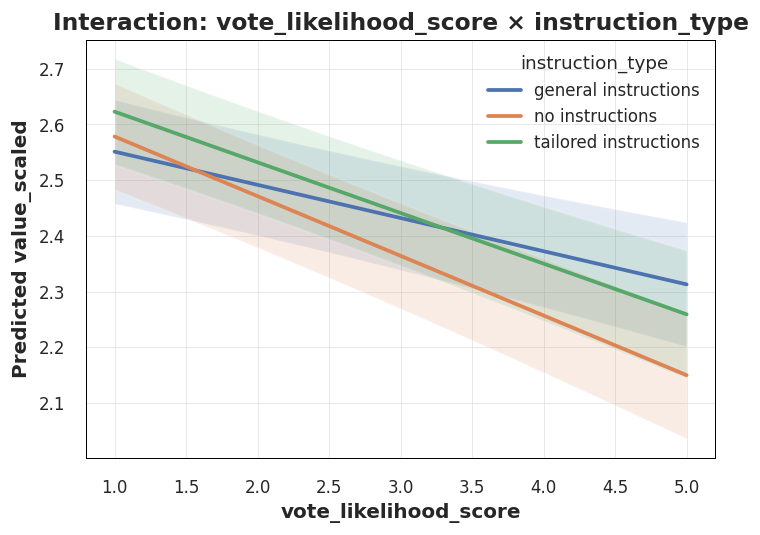

In [84]:
# using the dataset you used to fit the model that includes this interaction
m = fitted_models['stellingen.misinformation'][5]  # the model with vote × instruction_type
filt = df[df['variable'] == 'stellingen.misinformation'].copy()
plot_interaction_continuous_by_3level(m, filt, x='vote_likelihood_score', moderator='instruction_type')

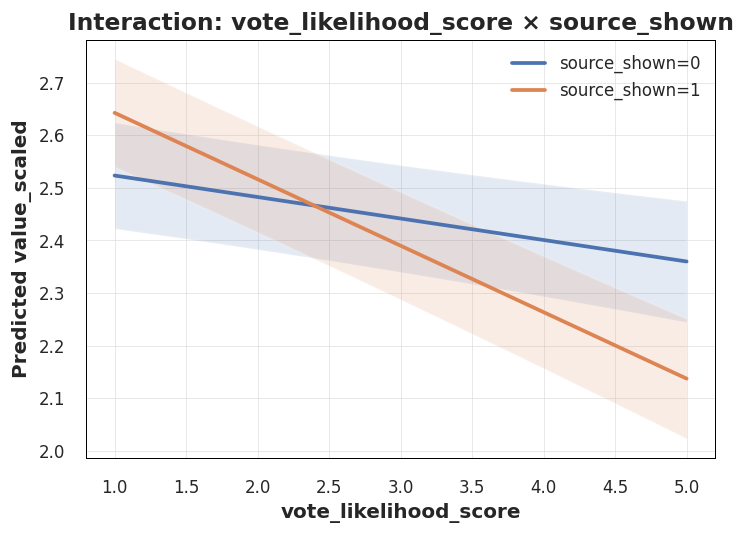

In [85]:
# # 2) vote × source_shown (H3)
m = fitted_models['stellingen.misinformation'][4]  # model with source_shown * vote_likelihood_score
filt = df[df['variable'] == 'stellingen.misinformation'].copy()
plot_interaction_continuous_by_binary(m, filt, x='vote_likelihood_score', moderator='source_shown')
plt.show()

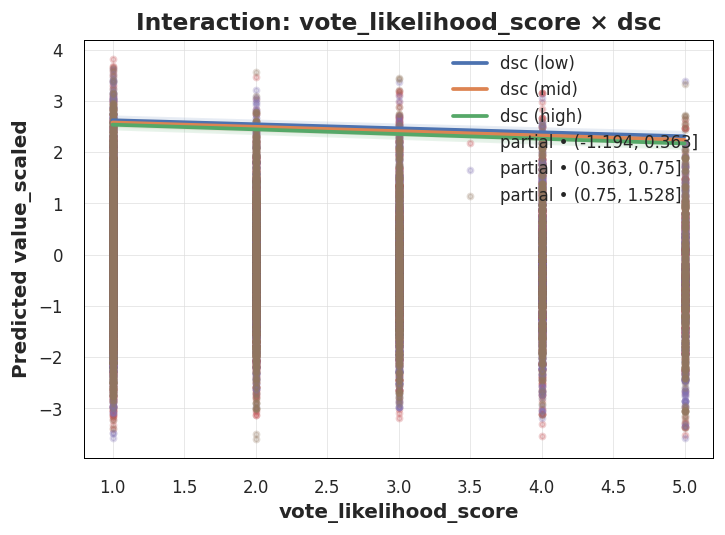

In [86]:
m = fitted_models['stellingen.misinformation'][3]  # model with vote_likelihood_score * dsc
filt = df[df['variable'] == 'stellingen.misinformation'].copy()
ax = plot_interaction_continuous_by_continuous(m, filt, x='vote_likelihood_score', moderator='dsc')
# # optional: overlay partial residuals
add_partial_residuals(ax, m, filt, x='vote_likelihood_score', moderator='dsc', bins=3)
plt.show()

In [54]:
# ---------------------------
# QC PIPELINE FOR CROWDCODING
# ---------------------------
import pandas as pd
import numpy as np
from dataclasses import dataclass

# ==== CONFIG ====
ANNOTATOR_COL = "coder"   # <-- set this to your column name
ANSWER_COL    = "value_scaled"         # <-- set this to your column name (numeric 1..5 preferred)

# Optional mapping if your answers are strings; otherwise leave empty.
ANSWER_MAP = {
    # "Strongly disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly agree": 5
}

VARIABLES_OF_INTEREST = {
    "stellingen.misinformation",
    "stellingen.sentiment",
    "stellingen.toxic",
}

@dataclass
class QCConfig:
    min_rt_item_s: float = 0.8        # flag individual ultra-fast clicks (< 800ms)
    median_rt_floor_s: float = 1.0    # speed-flag if annotator median RT < 1.0s
    longstring_k: int = 15            # flag if longest identical-run >= 15 within an outcome
    sd_floor: float = 0.25            # low variance flag (per outcome)
    entropy_floor_bits: float = 0.9   # low entropy flag (per outcome)
    edge_prop_thresh: float = 0.90    # >90% at endpoints
    repeat_tol: float = 1.0           # inconsistency flag if median abs diff > 1 on repeated items
    cali_dev_tol: float = 1.0         # counts as a "miss" if |label - consensus| > 1
    cali_miss_allow: int = 1          # allow at most 1 miss across calibration items
    cali_min_items: int = 3           # need at least 3 calibration items to evaluate
    # fallback consensus items (when no explicit training): item entropy threshold
    consensus_item_entropy_bits: float = 0.5

cfg = QCConfig()

# ==== HELPERS ====
def coerce_answer(series: pd.Series) -> pd.Series:
    if ANSWER_MAP:
        series = series.map(ANSWER_MAP).astype("float")
    else:
        series = pd.to_numeric(series, errors="coerce")
    return series

def shannon_entropy(counts) -> float:
    counts = np.array(counts, dtype=float)
    if counts.sum() == 0:
        return np.nan
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum())

def longest_run(values: pd.Series) -> int:
    """Longest streak of identical consecutive values (ignores NaNs)."""
    vals = values.values
    best = cur = 0
    prev = object()
    for v in vals:
        if pd.isna(v): 
            cur = 0; prev = object(); continue
        if v == prev:
            cur += 1
        else:
            cur = 1
        prev = v
        if cur > best:
            best = cur
    return int(best)

def item_entropy(series: pd.Series) -> float:
    vc = series.value_counts(dropna=True)
    return shannon_entropy(vc.values)

def safe_quantile(s: pd.Series, q):
    try:
        return float(s.quantile(q))
    except Exception:
        return np.nan

# ==== PREP ====
def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    # Keep only variables of interest & completed items
    mask = df["variable"].isin(VARIABLES_OF_INTEREST) | df["variable"].str.contains("training", case=False, na=False)
    df = df.loc[mask].copy()
    if "unit_status" in df.columns:
        df = df.loc[df["unit_status"].eq("DONE")].copy()

    # Times -> seconds
    df["t_q"] = pd.to_datetime(df["time_question_annotinder"], utc=True, errors="coerce")
    df["t_a"] = pd.to_datetime(df["time_answer"], utc=True, errors="coerce")
    df["rt_s"] = (df["t_a"] - df["t_q"]).dt.total_seconds()

    # Answers -> numeric
    df[ANSWER_COL] = coerce_answer(df[ANSWER_COL])
    # basic label scale inference
    label_min = int(np.nanmin(df[ANSWER_COL].values))
    label_max = int(np.nanmax(df[ANSWER_COL].values))
    df.attrs["label_min"] = label_min
    df.attrs["label_max"] = label_max

    # Basic bad rows
    df["rt_fast_flag"] = df["rt_s"] < cfg.min_rt_item_s
    return df

# ==== CALIBRATION / HONEYPOT ====
def build_calibration_table(df: pd.DataFrame) -> pd.DataFrame:
    """Create per-(variable, unit_id) consensus label for calibration.
    Priority 1: explicit *training* items. If none, fallback to near-consensus items."""
    # Explicit training?
    train_mask = df["variable"].str.contains("training", case=False, na=False)
    if train_mask.any():
        base = df.loc[train_mask].copy()
        src = "training"
    else:
        # fallback: near-consensus per (variable, unit_id) based on crowd entropy
        base = df.loc[df["variable"].isin(VARIABLES_OF_INTEREST)].copy()
        grp = base.groupby(["variable", "unit_id"])
        ent = grp[ANSWER_COL].apply(item_entropy).rename("entropy")
        base = base.merge(ent, on=["variable", "unit_id"], how="left")
        base = base.loc[base["entropy"] <= cfg.consensus_item_entropy_bits].copy()
        src = "consensus-fallback"

    if base.empty:
        return pd.DataFrame(columns=["variable", "unit_id", "consensus", "n", "source"])

    # consensus = modal label; break ties with mean
    def consensus_func(s):
        vc = s.value_counts()
        if vc.empty:
            return np.nan
        top = vc.max()
        modes = vc[vc == top].index.to_list()
        if len(modes) == 1:
            return float(modes[0])
        else:
            return float(np.mean(modes))

    tab = (
        base.groupby(["variable", "unit_id"])
            .agg(consensus=(ANSWER_COL, consensus_func), n=(ANSWER_COL, "size"))
            .reset_index()
    )
    tab["source"] = src
    return tab

# ==== REPEATED ITEMS ====
def per_annotator_repeat_inconsistency(df: pd.DataFrame) -> pd.Series:
    """Median absolute diff on repeated (variable, unit_id) within annotator."""
    rep = df.groupby([ANNOTATOR_COL, "variable", "unit_id"]).size().rename("n").reset_index()
    rep = rep.loc[rep["n"] >= 2, [ANNOTATOR_COL, "variable", "unit_id"]]
    if rep.empty:
        return pd.Series(dtype=float, name="repeat_mad")

    merged = df.merge(rep, on=[ANNOTATOR_COL, "variable", "unit_id"], how="inner")
    # For each (annotator, variable, unit) compute pairwise abs diffs
    def mad_pairs(s):
        v = s.dropna().values
        if v.size < 2:
            return np.nan
        # all pairwise diffs
        diffs = []
        for i in range(len(v)):
            for j in range(i+1, len(v)):
                diffs.append(abs(v[i] - v[j]))
        if not diffs:
            return np.nan
        return float(np.median(diffs))

    out = (
        merged.groupby([ANNOTATOR_COL, "variable"])[ANSWER_COL]
              .apply(mad_pairs)
              .groupby(level=0).median()  # one number per annotator: median across outcomes
              .rename("repeat_mad")
    )
    return out

# ==== MAIN QC ====
def run_qc(df_raw: pd.DataFrame, cfg: QCConfig = cfg):
    df = prepare_df(df_raw)

    # ---- per-annotator aggregates ----
    # speed
    g_anno = df.groupby(ANNOTATOR_COL, as_index=False)
    speed = g_anno.agg(
        n_items=("unit_id", "size"),
        median_rt=("rt_s", "median"),
        p01_rt=("rt_s", lambda s: safe_quantile(s, 0.01)),
        p99_rt=("rt_s", lambda s: safe_quantile(s, 0.99)),
        fast_click_rate=("rt_fast_flag", "mean"),
    )
    speed["speed_flag"] = speed["median_rt"] < cfg.median_rt_floor_s

    # longstring / variance / entropy / edge usage per outcome, then summarize worst-case
    def per_outcome_stats(d):
        d = d.sort_values("t_q")
        length = longest_run(d[ANSWER_COL])
        sd = float(d[ANSWER_COL].std(ddof=0))
        ent = item_entropy(d[ANSWER_COL])
        # edge usage
        label_min, label_max = d.attrs.get("label_min", 1), d.attrs.get("label_max", 5)
        edge_prop = float(((d[ANSWER_COL] == label_min) | (d[ANSWER_COL] == label_max)).mean())
        return pd.Series({
            "longstring": length,
            "sd": sd,
            "entropy": ent,
            "edge_prop": edge_prop
        })

    stats = (df.groupby([ANNOTATOR_COL, "variable"])
               .apply(per_outcome_stats)
               .reset_index())

    worst = (stats.groupby(ANNOTATOR_COL)
                  .agg(longstring_max=("longstring", "max"),
                       sd_min=("sd", "min"),
                       entropy_min=("entropy", "min"),
                       edge_prop_max=("edge_prop", "max"))
                  .reset_index())

    worst["longstring_flag"] = worst["longstring_max"] >= cfg.longstring_k
    worst["lowvar_flag"]     = worst["sd_min"] < cfg.sd_floor
    worst["lowent_flag"]     = worst["entropy_min"] < cfg.entropy_floor_bits
    worst["edge_flag"]       = worst["edge_prop_max"] > cfg.edge_prop_thresh

    # repeat consistency
    repeat = per_annotator_repeat_inconsistency(df)
    repeat = repeat.reset_index() if isinstance(repeat, pd.Series) else repeat
    if repeat.empty:
        repeat = pd.DataFrame({ANNOTATOR_COL: df[ANNOTATOR_COL].unique(), "repeat_mad": np.nan})
    repeat["repeat_flag"] = repeat["repeat_mad"] > cfg.repeat_tol

    # calibration/honeypots
    calitab = build_calibration_table(df)
    if not calitab.empty:
        joined = df.merge(calitab, on=["variable", "unit_id"], how="inner")
        joined["cali_miss"] = (joined[ANSWER_COL] - joined["consensus"]).abs() > cfg.cali_dev_tol
        cali = (joined.groupby(ANNOTATOR_COL)["cali_miss"]
                      .agg(["sum", "size"])
                      .rename(columns={"sum": "cali_misses", "size": "cali_n"})
                      .reset_index())
        cali["cali_flag"] = (cali["cali_n"] >= cfg.cali_min_items) & (cali["cali_misses"] > cfg.cali_miss_allow)
    else:
        cali = pd.DataFrame({ANNOTATOR_COL: df[ANNOTATOR_COL].unique(),
                             "cali_misses": np.nan, "cali_n": 0, "cali_flag": False})

    # merge all annotator-level diagnostics
    qc = (speed.merge(worst, on=ANNOTATOR_COL, how="left")
                .merge(repeat, on=ANNOTATOR_COL, how="left")
                .merge(cali, on=ANNOTATOR_COL, how="left"))

    # total flags & recommended action
    flag_cols = ["speed_flag", "longstring_flag", "lowvar_flag", "lowent_flag", "edge_flag", "repeat_flag", "cali_flag"]
    qc["n_flags"] = qc[flag_cols].sum(axis=1, numeric_only=True)

    def action_row(r):
        # Drop only on converging evidence
        if (r["n_flags"] >= 3) or (r.get("cali_flag", False) and r.get("speed_flag", False)):
            return "drop"
        if r["n_flags"] >= 1:
            return "weight"
        return "keep"

    qc["action"] = qc.apply(action_row, axis=1)

    # reliability weight: 1.0 minus 0.2 per flag, clipped to [0.3, 1.0]
    qc["weight"] = (1.0 - 0.2 * qc["n_flags"]).clip(lower=0.30, upper=1.00)

    # per-annotation weights to merge back
    anno_weights = qc[[ANNOTATOR_COL, "weight", "action"]].copy()
    df_out = df.merge(anno_weights, on=ANNOTATOR_COL, how="left")

    return df_out, qc, stats, calitab

df_qc, qc_summary, outcome_stats, calib_table = run_qc(df, cfg)

# ==== USAGE ====
# df = ...  # your original DataFrame with columns:
# ['time_question_annotinder','time_answer','variable','unit_status','unit_id', ANNOTATOR_COL, ANSWER_COL, ...]
#

# # Merge weights back into your modeling data:
# modeling_df = df_qc.loc

/tmp/ipykernel_8568/2058440740.py:212: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(per_outcome_stats)


In [55]:
#Example quick looks:
print(qc_summary.head())
print(qc_summary["action"].value_counts(dropna=False))
print(qc_summary[["n_items","median_rt","fast_click_rate","longstring_max","sd_min","entropy_min","edge_prop_max","repeat_mad","cali_misses","cali_n","n_flags","action","weight"]].sort_values("n_flags", ascending=False).head(20))

    coder  n_items  median_rt   p01_rt      p99_rt  fast_click_rate  \
0  265991       98    19.3795  5.04544    42.46551              0.0   
1  265992       95    24.3210  5.95072  2726.35236              0.0   
2  265994        8    14.3775  8.28268    30.18131              0.0   
3  265995       95    17.5570  5.33242    47.90480              0.0   
4  265996       95     2.2190  1.01382    24.61206              0.0   

   speed_flag  longstring_max    sd_min  entropy_min  ...  lowent_flag  \
0       False             8.0  1.268858     1.110552  ...        False   
1       False             9.0  0.965517     1.106367  ...        False   
2       False             0.0       NaN          NaN  ...        False   
3       False             9.0  0.556018     1.037401  ...        False   
4       False            20.0  0.371391     0.716726  ...         True   

   edge_flag  repeat_mad  repeat_flag  cali_misses  cali_n  cali_flag  \
0      False         NaN        False            0     

In [48]:
print(df[['time_question_annotinder', 'time_answer', 'variable', 'unit_status', 'unit_id']])

       time_question_annotinder               time_answer  \
0       2024-10-16 17:32:43.820  2024-10-16T17:33:13.655Z   
1       2024-10-16 17:33:14.638  2024-10-16T17:33:18.855Z   
2       2024-10-16 17:33:19.751  2024-10-16T17:33:31.925Z   
3       2024-10-16 17:33:32.367  2024-10-16T17:33:34.434Z   
4       2024-10-16 17:33:34.661  2024-10-16T17:33:36.176Z   
...                         ...                       ...   
153669  2024-10-15 09:30:32.109  2024-10-15T09:30:45.238Z   
153670  2024-10-15 09:30:46.666  2024-10-15T09:30:47.295Z   
153671  2024-10-15 09:30:46.666  2024-10-15T09:30:47.429Z   
153672  2024-10-15 09:30:46.666  2024-10-15T09:30:47.580Z   
153673  2024-10-15 09:30:46.666  2024-10-15T09:30:47.810Z   

                           variable unit_status              unit_id  
0                           confirm        DONE               welkom  
1                           confirm        DONE              welkom2  
2         political_stance_training        DONE       

In [353]:
import os
import pandas as pd
import statsmodels.formula.api as smf

# Step 1: Fit Stepwise Mixed-Effects Models
def fit_stepwise_models(data, variable_name):
    filtered_data = data[data['variable'] == variable_name].copy()
    filtered_data['instruction_type'] = pd.Categorical(
        filtered_data['instruction_type'],
        categories=['no instructions', 'general instructions', 'tailored instructions'],
        ordered=True
    )
    
    formulas = [
    "value_scaled ~ Male + Age + source_shown + instruction_type + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
    "value_scaled ~ Male + Age + source_shown + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
    "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
    "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * dsc + instruction_type + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
    "value_scaled ~ Male + Age + source_shown * vote_likelihood_score + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
    "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair"
]
    return [smf.mixedlm(f, data=filtered_data, groups=filtered_data["uid"]).fit() for f in formulas]

# Step 2: Rename predictors
def rename_predictors(predictors):
    return {
        'Intercept': 'Intercept',
        'instruction_type[T.general instructions]': 'General Instructions',
        'instruction_type[T.tailored instructions]': 'Tailored Instructions',
        'Edu_binary': 'Higher Educated',
        'Male': 'Male',
        'Age': 'Age',
        'source_shown': 'Source Shown',
        'vote_likelihood_score': 'Ideological Congruence',
        'dsc': 'Implicit Bias',
        'negative_stance': 'Negative Stance',
        'ImportIssue_1_numeric': 'Import Issue',
        'KnowIssue_1_numeric': 'Knowledge Issue',
        'AttitudeExtr2_combined': 'Attitude (Combined)',
        'Werk_binair': 'Employment',
        'Etniciteit_binair': 'Ethnicity',
        'source_shown:vote_likelihood_score': 'Source × Ideological Congruence',
        'vote_likelihood_score:dsc': 'Ideological Congruence × Bias',
        'vote_likelihood_score:instruction_type[T.general instructions]': 'Ideol. Congruence × General Instr.',
        'vote_likelihood_score:instruction_type[T.tailored instructions]': 'Ideol. Congruence × Tailored Instr.',
        'Group Var': 'Group Variance'
    }

# Step 3: LaTeX Table Generator
def generate_latex_table_with_group_variance(models, predictors, rename_map, variable_name):
    sections = {
        'Main Effects': [
            'instruction_type[T.general instructions]',
            'instruction_type[T.tailored instructions]',
            'source_shown',
            'dsc'
        ],
        'H1: Effects of Ideological Congruence': [
            'vote_likelihood_score'
        ],
        'H2: Moderating Effects of Implicit Bias': [
            'vote_likelihood_score:dsc'
        ],
        'H3: Moderating Effects of Source Visibility': [
            'source_shown:vote_likelihood_score'
        ],
        'H4: Moderating Effects of Instruction Type': [
            'vote_likelihood_score:instruction_type[T.general instructions]',
            'vote_likelihood_score:instruction_type[T.tailored instructions]'
        ],
    'Control Variables': [
        'Male', 'Age', 'ImportIssue_1_numeric', 'KnowIssue_1_numeric',
        'AttitudeExtr2_combined', 'Edu_binary', 'Werk_binair', 'Etniciteit_binair',
        'negative_stance'

        ]
    }

    def format_coef(model, predictor, italic=False):
        if predictor in model.params.index:
            coef = model.params[predictor]
            se = model.bse[predictor]
            p = model.pvalues[predictor]
            val = f"{coef:.2f} ({se:.2f})"
            if p < 0.05:
                val = f"\\textbf{{{val}}}"
            if italic:
                val = f"\\textit{{{val}}}"
            return val
        return "--"

    table_rows = []

    for section_title, section_predictors in sections.items():
        # Add section title row (no horizontal line before or after)
        table_rows.append([f"\\\\[-0.5ex]\n\\multicolumn{{{len(models)+1}}}{{l}}{{\\textbf{{{section_title}}}}} \\\\"])

        for predictor in section_predictors:
            name = rename_map.get(predictor, predictor)
            italic = (section_title == "Control Variables")
            if italic:
                name = f"\\textit{{{name}}}"
            row = [name] + [format_coef(m, predictor, italic=italic) for m in models]
            table_rows.append(row)

    # Model fit stats
    def get_group_var(model):
        return model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
    def get_icc(model):
        gv = get_group_var(model)
        rv = model.scale
        return gv / (gv + rv) if gv + rv > 0 else float('nan')

    # Add model summary rows (with horizontal line above)
    table_rows.append(["\\hline"])
    table_rows.extend([
        ["Group Variance"] + [f"{get_group_var(m):.4f}" for m in models],
        ["ICC"] + [f"{get_icc(m):.4f}" for m in models],
        ["Log Likelihood"] + [f"{m.llf:.2f}" for m in models],
        ["N (Obs)"] + [f"{int(m.nobs)}" for m in models],
        ["N (Groups)"] + [f"{len(m.random_effects)}" if hasattr(m, "random_effects") else "NA" for m in models]
    ])

    # Render LaTeX
    escaped_varname = variable_name.replace('_', '\\_')
    latex_table = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{Stepwise Mixed-Effects Model Results for {escaped_varname}}}\n"
        f"\\label{{tab:{variable_name}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        f"\\begin{{tabular}}{{{'l' + 'c'*len(models)}}}\n"
        "\\hline\n"
        + " & ".join(["Predictor"] + [f"Model {i+1}" for i in range(len(models))]) + " \\\\\n"
        "\\hline\n"
       + "\n".join(row[0] if row[0].startswith("\\\\") else " & ".join(row) + " \\\\"
                    for row in table_rows
                ) +

        "\n\\hline\n"
        "\\end{tabular}%\n"
        "}\n"
        "\\end{table}"
    )
    return latex_table


# Step 4: Run models and output tables
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
output_dir = "/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/output/tables/"
os.makedirs(output_dir, exist_ok=True)

fitted_models = {}
rename_map = rename_predictors([])

for var in variables:
    try:
        print(f"\n--- Fitting models for: {var} ---")
        fitted_models[var] = fit_stepwise_models(df, var)

        latex_table = generate_latex_table_with_group_variance(
            fitted_models[var], list(rename_map.keys()), rename_map, var
        )

        print(latex_table)

        file_path = os.path.join(output_dir, f"{var.replace('.', '_')}_models.tex")
        with open(file_path, "w") as f:
            f.write(latex_table)
        print(f"✅ Table saved: {file_path}")
    except Exception as e:
        print(f"❌ Error with {var}: {e}")



--- Fitting models for: stellingen.misinformation ---
\begin{table}[ht]
\centering
\caption{Stepwise Mixed-Effects Model Results for stellingen.misinformation}
\label{tab:stellingen.misinformation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\hline
Predictor & Model 1 & Model 2 & Model 3 & Model 4 & Model 5 & Model 6 \\
\hline
\\[-0.5ex]
\multicolumn{7}{l}{\textbf{Main Effects}} \\
General Instructions & 0.03 (0.05) & 0.03 (0.05) & 0.02 (0.05) & 0.02 (0.05) & 0.03 (0.05) & -0.09 (0.06) \\
Tailored Instructions & 0.07 (0.05) & 0.07 (0.05) & 0.07 (0.05) & 0.06 (0.05) & 0.07 (0.05) & 0.02 (0.06) \\
Source Shown & 0.01 (0.04) & 0.01 (0.04) & 0.02 (0.04) & 0.02 (0.04) & \textbf{0.21 (0.05)} & 0.02 (0.04) \\
Implicit Bias & -- & \textbf{-0.12 (0.05)} & \textbf{-0.14 (0.05)} & -0.09 (0.06) & \textbf{-0.14 (0.05)} & \textbf{-0.14 (0.05)} \\
\\[-0.5ex]
\multicolumn{7}{l}{\textbf{H1: Effects of Ideological Congruence}} \\
Ideological Congruence & -- & -- & \textbf{-0.08 (0.01)} & \text

In [395]:
import pandas as pd

df = pd.read_parquet("/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/data/final_merged_dataset_for_analysis.parquet")
# Print original number of rows
print("Before filtering:", len(df))

Before filtering: 153674


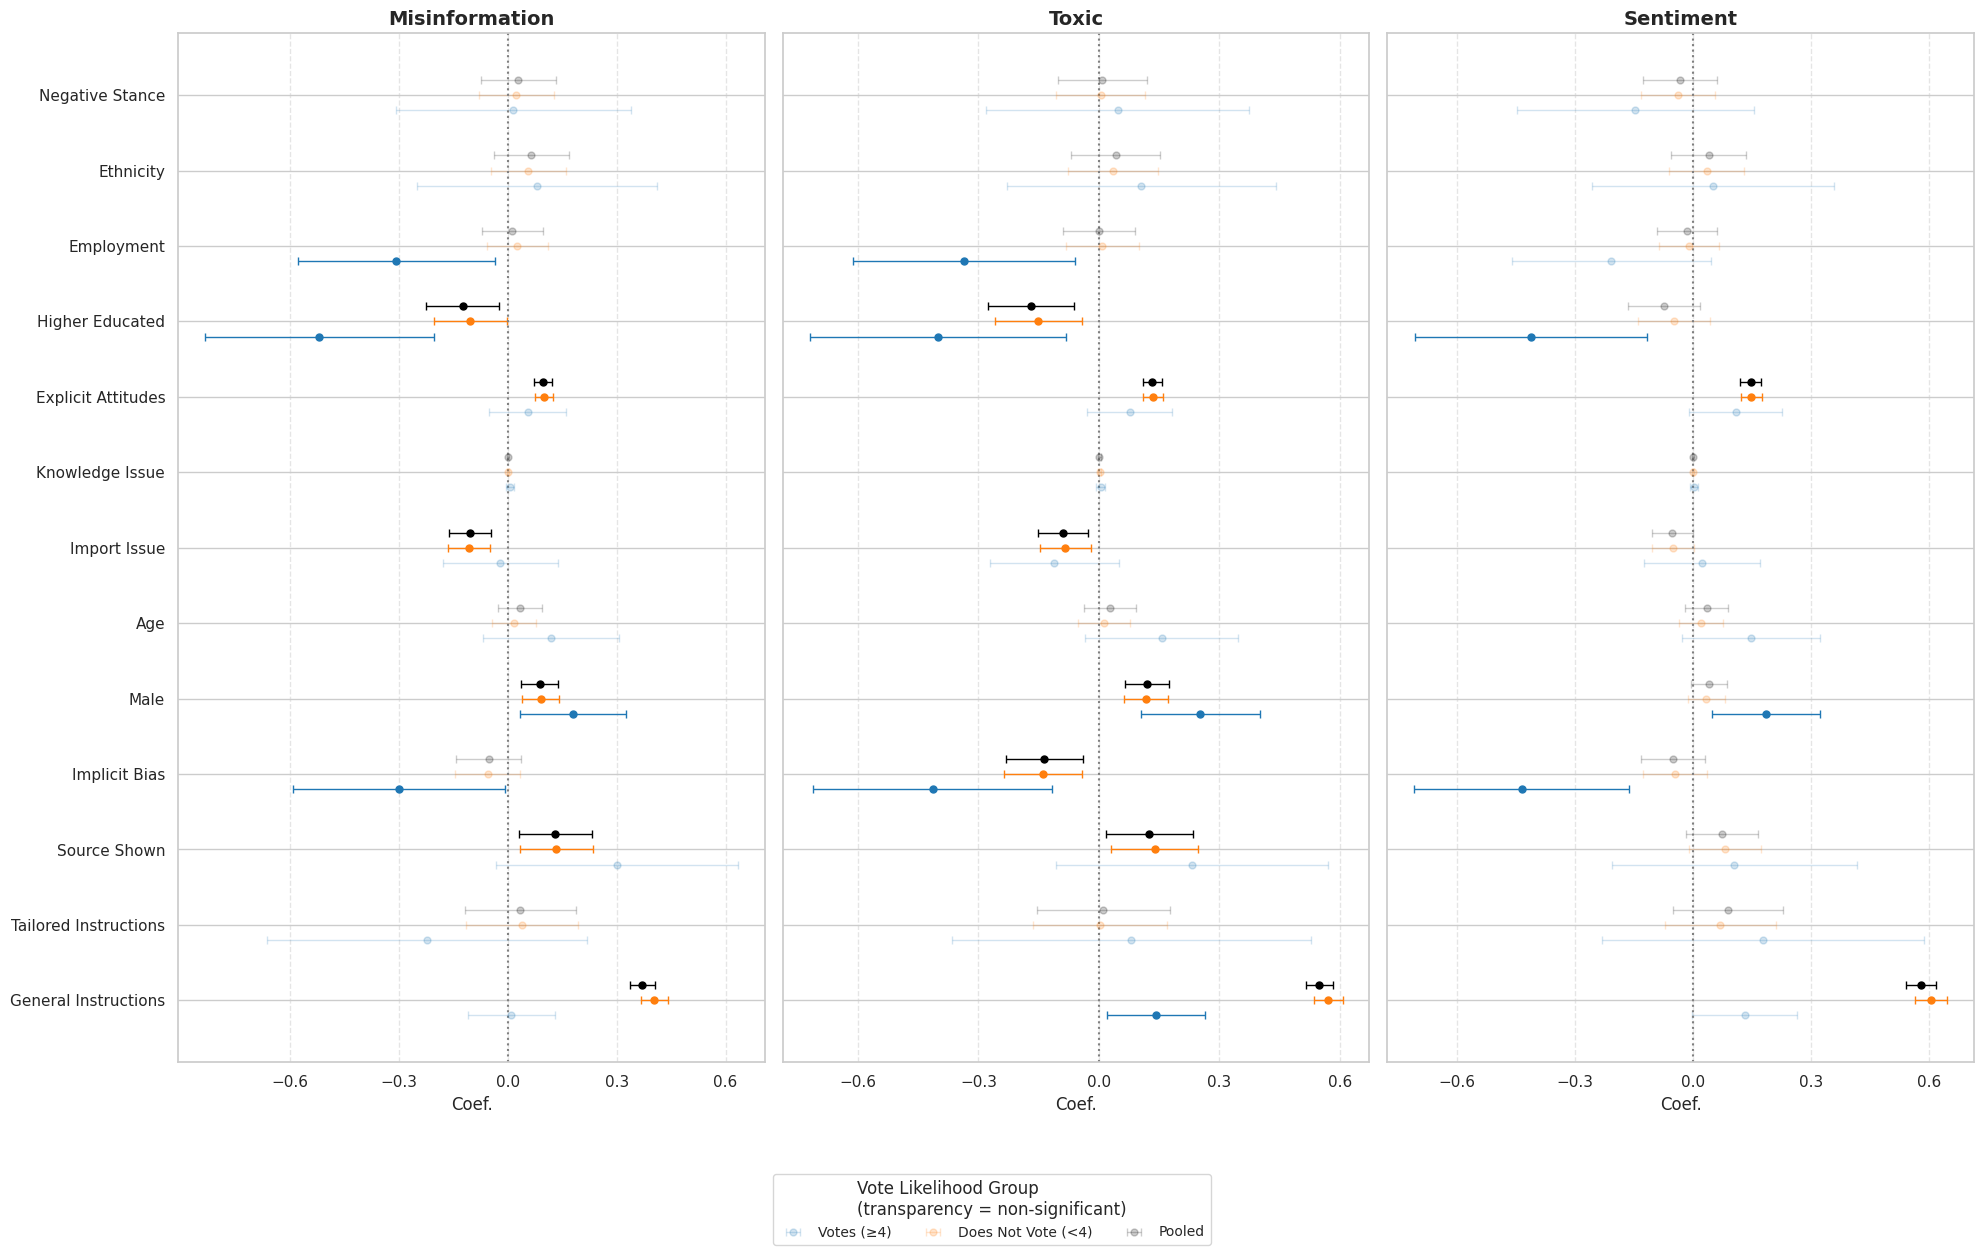

In [404]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Reinitialize df if needed
# df = pd.read_parquet("your_parquet_file_path_here")

# Step 1: Define grouping and predictors
df['vote_group'] = df['vote_likelihood_score'].apply(lambda x: 'Votes (≥4)' if x >= 5 else 'Does Not Vote (<4)')
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
desired_predictors = [
    'instruction_type[T.general instructions]', 'instruction_type[T.tailored instructions]',
    'source_shown', 'dsc', 'Male', 'Age', 'ImportIssue_1_numeric',
    'KnowIssue_1_numeric', 'AttitudeExtr2_combined', 'Edu_binary',
    'Werk_binair', 'Etniciteit_binair', 'negative_stance'
]

# Clean labels for plotting
label_map_ordered = [
    ('instruction_type[T.general instructions]', 'General Instructions'),
    ('instruction_type[T.tailored instructions]', 'Tailored Instructions'),
    ('source_shown', 'Source Shown'),
    ('dsc', 'Implicit Bias'),
    ('Male', 'Male'),
    ('Age', 'Age'),
    ('ImportIssue_1_numeric', 'Import Issue'),
    ('KnowIssue_1_numeric', 'Knowledge Issue'),
    ('AttitudeExtr2_combined', 'Explicit Attitudes'),
    ('Edu_binary', 'Higher Educated'),
    ('Werk_binair', 'Employment'),
    ('Etniciteit_binair', 'Ethnicity'),
    ('negative_stance', 'Negative Stance')
]
label_map = dict(label_map_ordered)
predictor_order = [v for _, v in label_map_ordered]

# Step 2: Fit models and extract results
plot_data = []

for var in variables:
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        if group == 'Pooled':
            subset = df[df['variable'] == var].copy()
        else:
            subset = df[(df['variable'] == var) & (df['vote_group'] == group)].copy()

        subset['instruction_type'] = pd.Categorical(
            subset['instruction_type'],
            categories=['no instructions', 'general instructions', 'tailored instructions'],
            ordered=True
        )

        formula = "value_scaled ~ instruction_type + source_shown + dsc + Male + Age + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + negative_stance"

        try:
            model = smf.mixedlm(formula, data=subset, groups=subset["uid"]).fit()
            for predictor in model.params.index:
                if predictor in desired_predictors:
                    est = model.params[predictor]
                    se = model.bse[predictor]
                    pval = model.pvalues[predictor]
                    plot_data.append({
                        "dv": var,
                        "group": group,
                        "predictor": predictor,
                        "predictor_clean": label_map[predictor],
                        "estimate": est,
                        "ci_lower": est - 1.96 * se,
                        "ci_upper": est + 1.96 * se,
                        "significant": pval < 0.05
                    })
        except Exception as e:
            print(f"⚠️ Model failed for {var} ({group}): {e}")

# Step 3: Format results for plotting
plot_df = pd.DataFrame(plot_data)
plot_df['predictor_order'] = plot_df['predictor_clean'].apply(lambda x: predictor_order.index(x))
plot_df['offset'] = plot_df['group'].map({'Votes (≥4)': 0.2, 'Does Not Vote (<4)': 0.0, 'Pooled': -0.2})
plot_df['y'] = plot_df['predictor_order'] + plot_df['offset']
plot_df['color'] = plot_df['group'].map({'Votes (≥4)': '#1f77b4', 'Does Not Vote (<4)': '#ff7f0e', 'Pooled': '#000000'})

# Re-plot with corrected order
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)
dvs_clean = ['Misinformation', 'Toxic', 'Sentiment']

for i, dv in enumerate(variables):
    ax = axes[i]
    subset = plot_df[plot_df['dv'] == dv]
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        gdata = subset[subset['group'] == group]
        for _, row in gdata.iterrows():
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=group if (i == 0 and row['predictor_order'] == 0) else None
            )
    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dvs_clean[i], fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(predictor_order)))
    ax.set_yticklabels(list(reversed(predictor_order)), fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood Group\n(transparency = non-significant)",
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()



``` 

✅ Instructions Lead to More Problem Labeling — Especially Among Voters
General and Tailored Instructions are associated with increased labeling of tweets as misinformative, toxic, and negative — particularly in the Misinformation panel.

This effect is strongest among voters and the pooled sample, but mostly absent or weaker among non-voters.

📌 Interpretation: Instructions make engaged annotators more attentive to problematic content, increasing their threshold for labeling tweets as such. Less engaged annotators don't apply the guidelines effectively.

Implicit Bias Reduces Problem Detection
For Misinformation and Toxicity, higher implicit bias (dsc) is associated with lower labeling of problematic content — i.e., they miss problematic tweets.

📌 Interpretation: Annotators with higher implicit bias may downplay or overlook harm, or interpret content more leniently, reducing the likelihood of assigning problem labels.


Source Visibility Makes Annotators Stricter
Particularly in Misinformation, seeing the source significantly increases the chance of calling content misinformative.

📌 Interpretation: When a known source is shown, annotators apply stricter judgments — possibly due to preconceived credibility expectations or heightened scrutiny.


🧠 Explicit Attitudes and Issue Involvement Matter
Annotators with stronger issue attitudes (explicit) are more likely to label content as toxic, misinformative, or negative.

This suggests motivated processing — people with clear views are more sensitive to violations and judge more harshly.
``` 

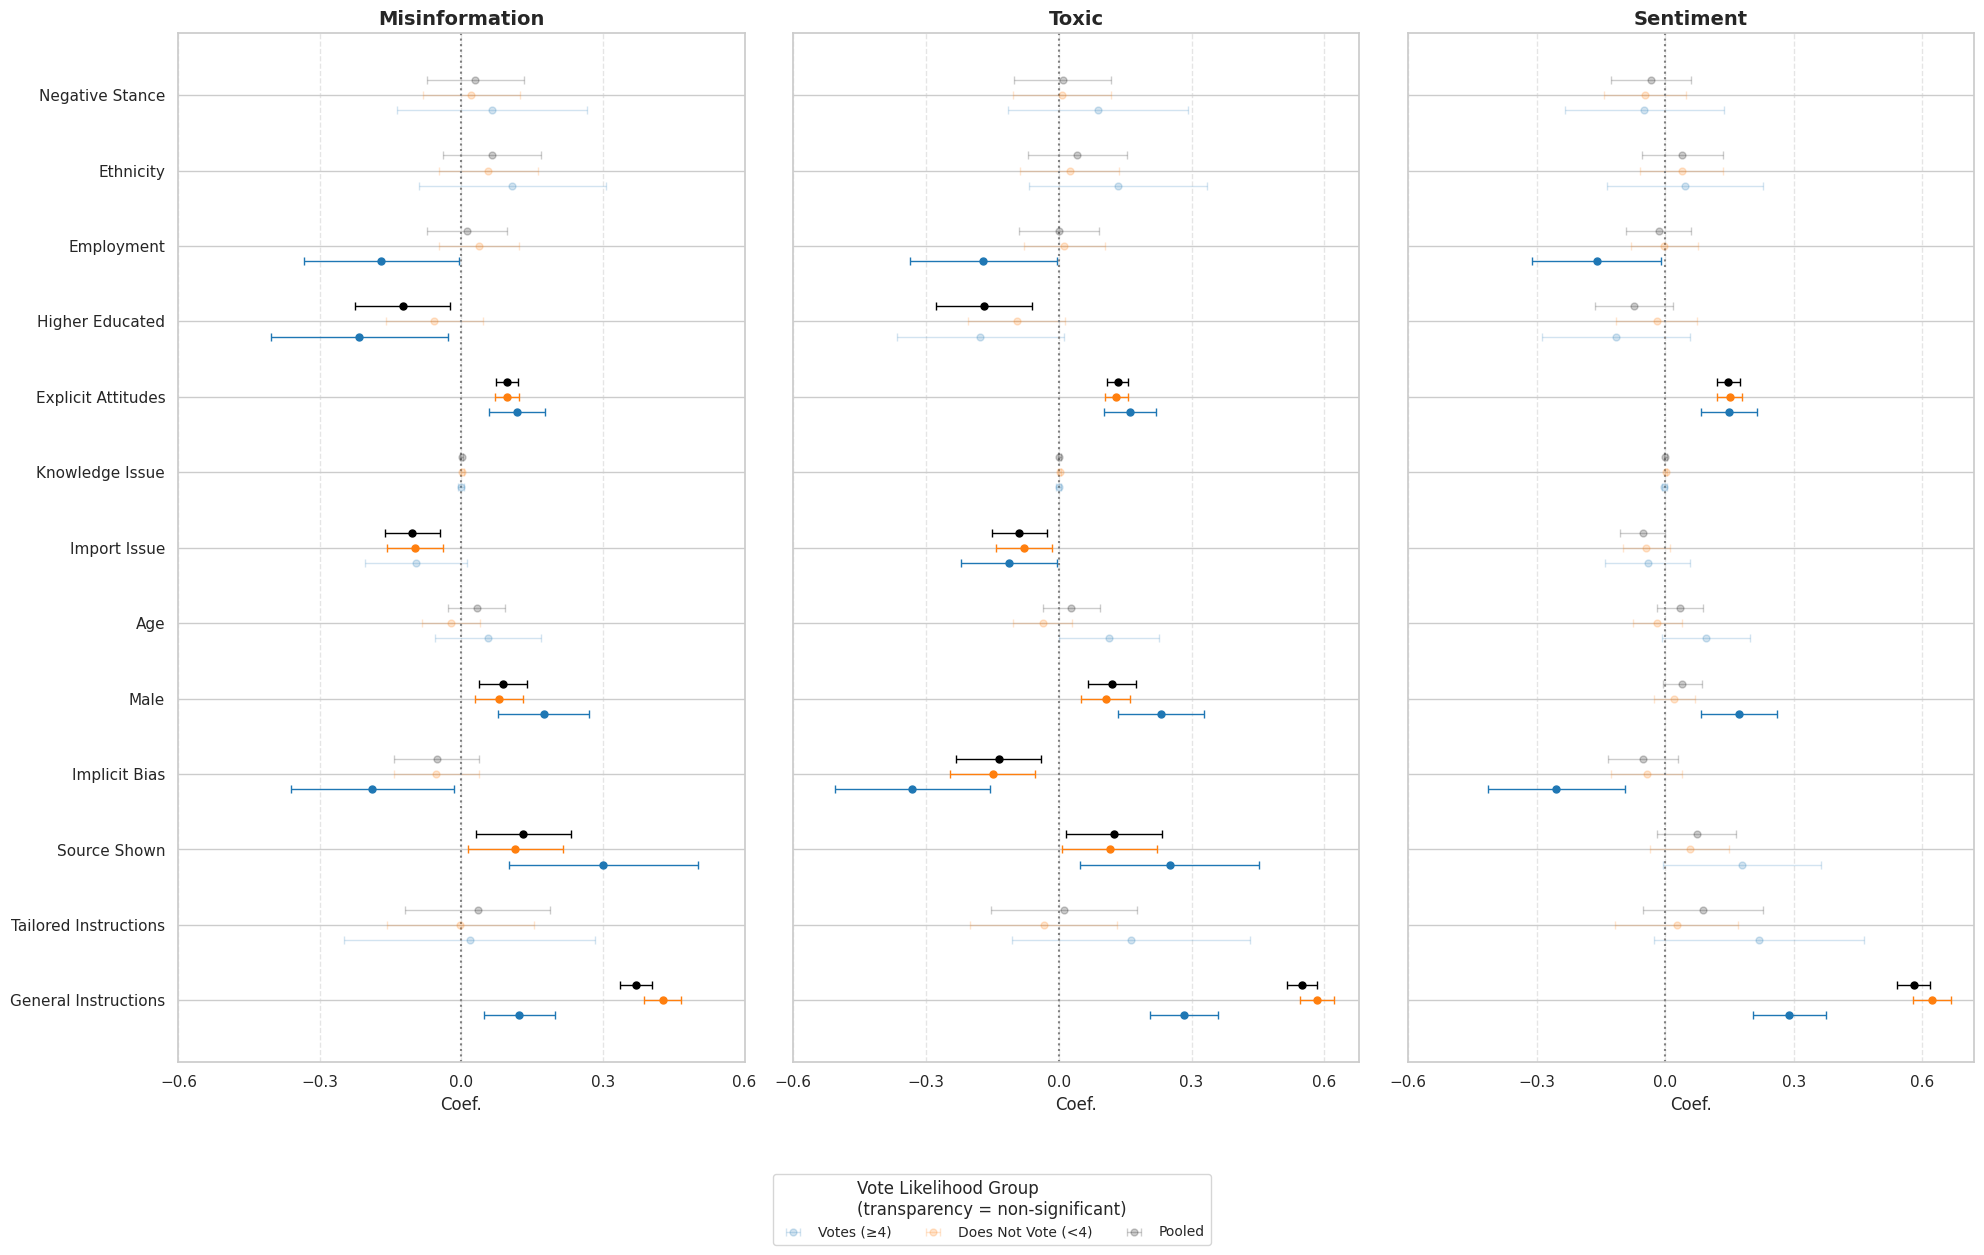

In [401]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Step 1: Define grouping and predictors
df['vote_group'] = df['vote_likelihood_score'].apply(lambda x: 'Votes (≥4)' if x >= 4 else 'Does Not Vote (<4)')
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
desired_predictors = [
    'instruction_type[T.general instructions]', 'instruction_type[T.tailored instructions]',
    'source_shown', 'dsc', 'Male', 'Age', 'ImportIssue_1_numeric',
    'KnowIssue_1_numeric', 'AttitudeExtr2_combined', 'Edu_binary',
    'Werk_binair', 'Etniciteit_binair', 'negative_stance'
]


# Clean labels for plotting
label_map_ordered = [
    ('instruction_type[T.general instructions]', 'General Instructions'),
    ('instruction_type[T.tailored instructions]', 'Tailored Instructions'),
    ('source_shown', 'Source Shown'),
    ('dsc', 'Implicit Bias'),
    ('Male', 'Male'),
    ('Age', 'Age'),
    ('ImportIssue_1_numeric', 'Import Issue'),
    ('KnowIssue_1_numeric', 'Knowledge Issue'),
    ('AttitudeExtr2_combined', 'Explicit Attitudes'),
    ('Edu_binary', 'Higher Educated'),
    ('Werk_binair', 'Employment'),
    ('Etniciteit_binair', 'Ethnicity'),
    ('negative_stance', 'Negative Stance')
]
label_map = dict(label_map_ordered)
predictor_order = [v for _, v in label_map_ordered]

# Step 2: Fit models and extract results
plot_data = []

for var in variables:
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        if group == 'Pooled':
            subset = df[df['variable'] == var].copy()
        else:
            subset = df[(df['variable'] == var) & (df['vote_group'] == group)].copy()

        subset['instruction_type'] = pd.Categorical(
            subset['instruction_type'],
            categories=['no instructions', 'general instructions', 'tailored instructions'],
            ordered=True
        )

        formula = "value_scaled ~ instruction_type + source_shown + dsc + Male + Age + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + negative_stance"

        
        try:
            model = smf.mixedlm(formula, data=subset, groups=subset["uid"]).fit()
            for predictor in model.params.index:
                if predictor in desired_predictors:
                    est = model.params[predictor]
                    se = model.bse[predictor]
                    pval = model.pvalues[predictor]
                    plot_data.append({
                        "dv": var,
                        "group": group,
                        "predictor": predictor,
                        "predictor_clean": label_map[predictor],
                        "estimate": est,
                        "ci_lower": est - 1.96 * se,
                        "ci_upper": est + 1.96 * se,
                        "significant": pval < 0.05
                    })
        except Exception as e:
            print(f"⚠️ Model failed for {var} ({group}): {e}")

# Step 3: Format results for plotting
plot_df['predictor_clean'] = plot_df['predictor'].map(label_map)
plot_df = plot_df[plot_df['predictor_clean'].isin(predictor_order)].copy()
plot_df['predictor_order'] = plot_df['predictor_clean'].apply(lambda x: predictor_order.index(x))
plot_df['y'] = plot_df['predictor_order'] + plot_df['offset']

# Re-plot with corrected order
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)
dvs_clean = ['Misinformation', 'Toxic', 'Sentiment']

for i, dv in enumerate(variables):
    ax = axes[i]
    subset = plot_df[plot_df['dv'] == dv]
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        gdata = subset[subset['group'] == group]
        for _, row in gdata.iterrows():
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=group if (i == 0 and row['predictor_order'] == 0) else None
            )
    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dvs_clean[i], fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(predictor_order)))
    ax.set_yticklabels(list(reversed(predictor_order)), fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood Group\n(transparency = non-significant)",
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [393]:
df[['variable', 'value_scaled']]

,variable,value_scaled
0,confirm,NaN
1,confirm,NaN
2,political_stance_training,NaN
3,sentiment_training,NaN
4,toxic_training,NaN
...,...,...
153669,stellingen.misinformation,3.0
153670,stellingen.political_stance,4.0
153671,stellingen.sentiment,2.0
153672,stellingen.toxic,4.0


In [392]:
plot_data = []

for var in variables:
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        if group == 'Pooled':
            subset = df[df['variable'] == var].copy()
        else:
            subset = df[(df['variable'] == var) & (df['vote_group'] == group)].copy()

        subset['instruction_type'] = pd.Categorical(
            subset['instruction_type'],
            categories=['no instructions', 'general instructions', 'tailored instructions'],
            ordered=True
        )

        formula = "value_scaled ~ Male + Age + source_shown + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair"
        
        try:
            model = smf.mixedlm(formula, data=subset, groups=subset["uid"]).fit()
            for predictor in model.params.index:
                if predictor in desired_predictors:
                    est = model.params[predictor]
                    se = model.bse[predictor]
                    pval = model.pvalues[predictor]
                    plot_data.append({
                        "dv": var,
                        "group": group,
                        "predictor": predictor,
                        "estimate": est,
                        "ci_lower": est - 1.96 * se,
                        "ci_upper": est + 1.96 * se,
                        "significant": pval < 0.05
                    })
        except Exception as e:
            print(f"⚠️ Model failed for {var} ({group}): {e}")


⚠️ Model failed for stellingen.misinformation (Votes (≥4)): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.misinformation (Does Not Vote (<4)): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.misinformation (Pooled): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.toxic (Votes (≥4)): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.toxic (Does Not Vote (<4)): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.toxic (Pooled): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.sentiment (Votes (≥4)): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.sentiment (Does Not Vote (<4)): name 'desired_predictors' is not defined
⚠️ Model failed for stellingen.sentiment (Pooled): name 'desired_predictors' is not defined


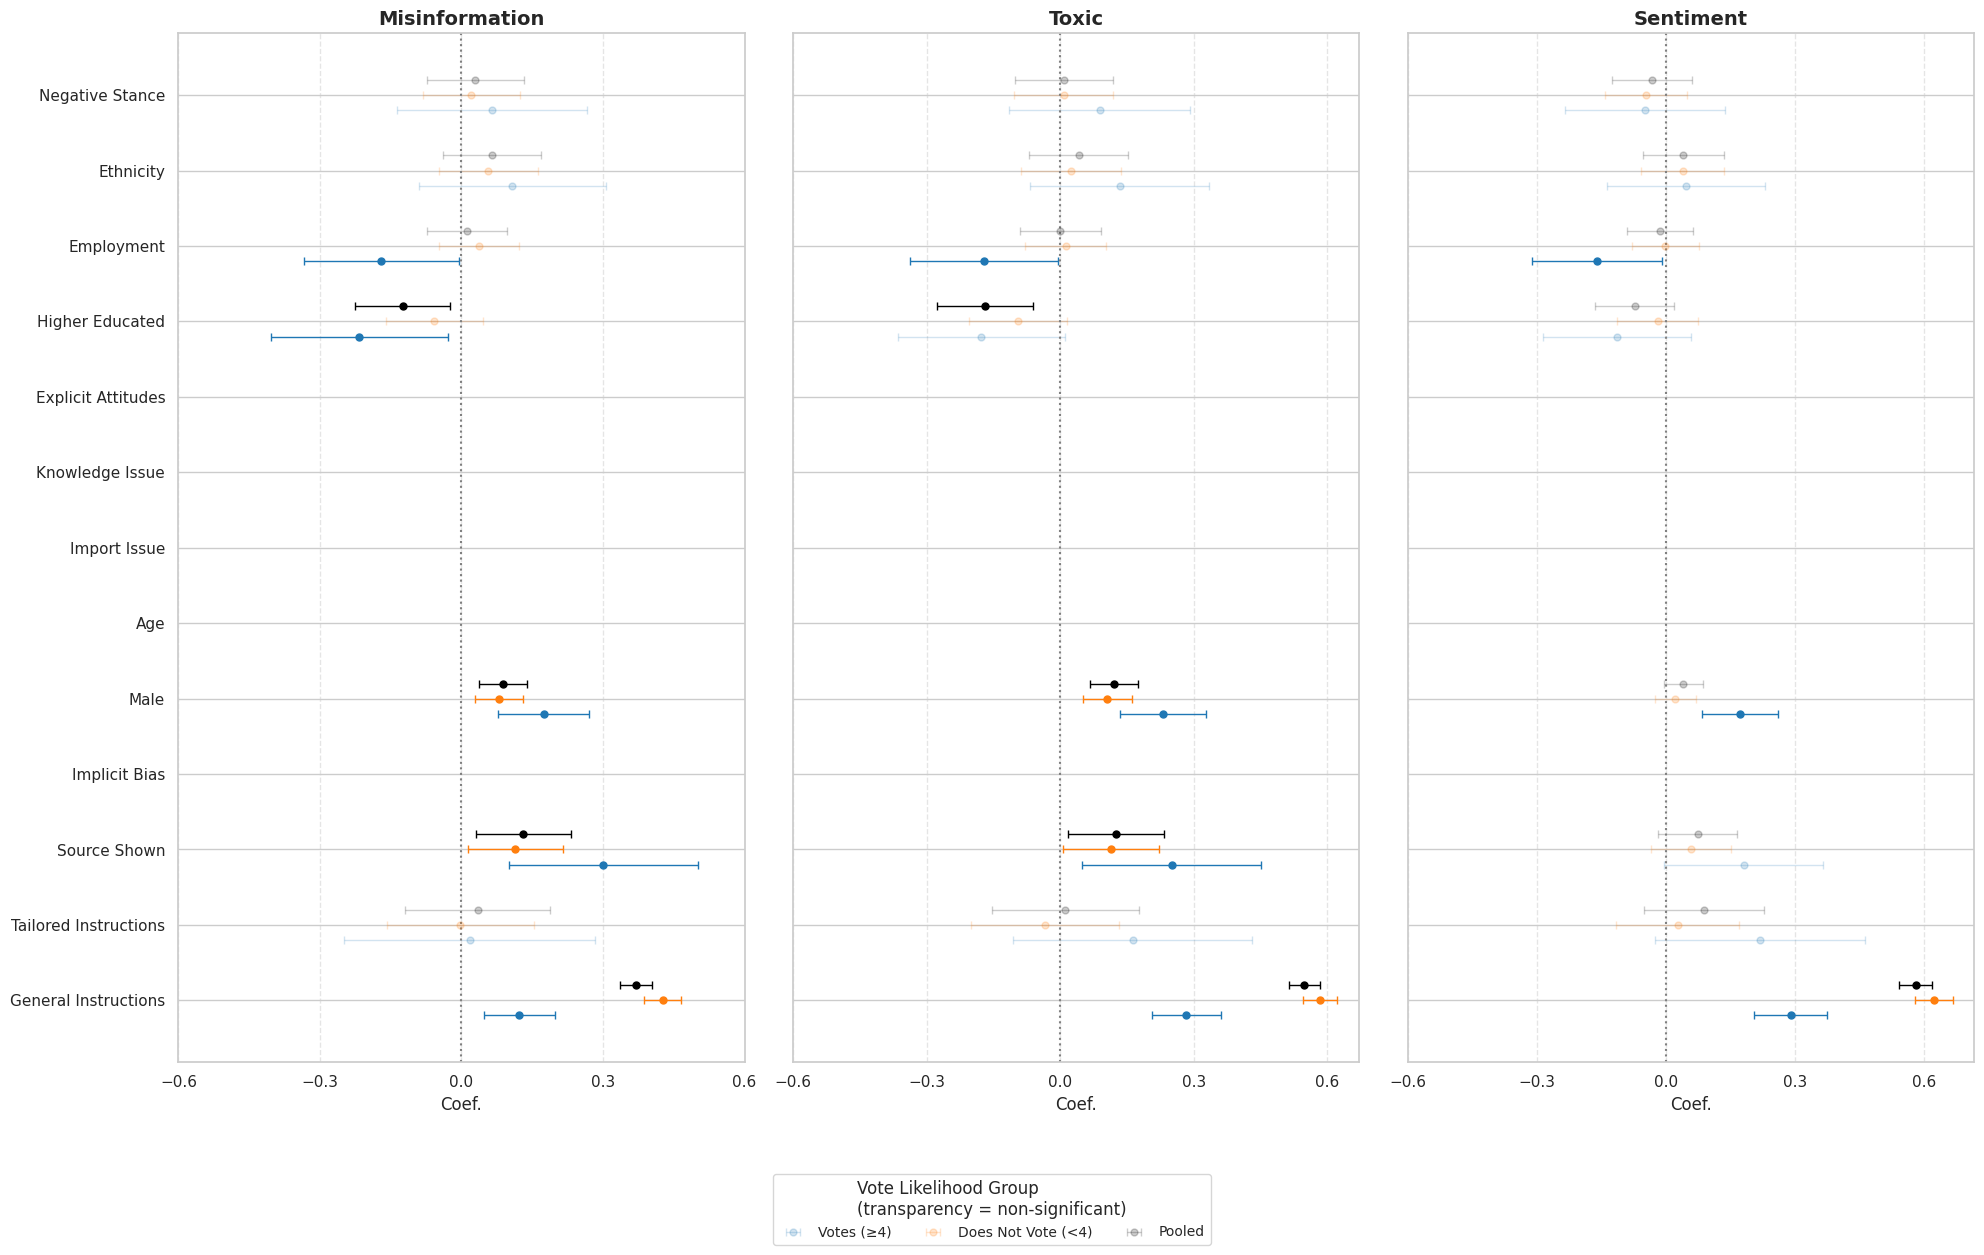

In [391]:
# Refined predictor order to match logical structure from LaTeX tables
label_map_ordered = [
    # Main Effects
    ('instruction_type[T.general instructions]', 'General Instructions'),
    ('instruction_type[T.tailored instructions]', 'Tailored Instructions'),
    ('source_shown', 'Source Shown'),
    ('dsc', 'Implicit Bias'),
    # Controls (demographics and attitudes)
    ('Male', 'Male'),
    ('Age', 'Age'),
    ('ImportIssue_1_numeric', 'Import Issue'),
    ('KnowIssue_1_numeric', 'Knowledge Issue'),
    ('AttitudeExtr2_combined', 'Explicit Attitudes'),
    ('Edu_binary', 'Higher Educated'),
    ('Werk_binair', 'Employment'),
    ('Etniciteit_binair', 'Ethnicity'),
    ('negative_stance', 'Negative Stance')
]

# Apply label map and order
label_map = dict(label_map_ordered)
predictor_order = [v for _, v in label_map_ordered]

# Update plot_df accordingly
plot_df['predictor_clean'] = plot_df['predictor'].map(label_map)
plot_df = plot_df[plot_df['predictor_clean'].isin(predictor_order)].copy()
plot_df['predictor_order'] = plot_df['predictor_clean'].apply(lambda x: predictor_order.index(x))
plot_df['offset'] = plot_df['group'].map({'Votes (≥4)': 0.2, 'Does Not Vote (<4)': 0.0, 'Pooled': -0.2})
plot_df['y'] = plot_df['predictor_order'] + plot_df['offset']
plot_df['color'] = plot_df['group'].map({'Votes (≥4)': '#1f77b4', 'Does Not Vote (<4)': '#ff7f0e', 'Pooled': '#000000'})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)
dvs_clean = ['Misinformation', 'Toxic', 'Sentiment']

for i, dv in enumerate(variables):
    ax = axes[i]
    subset = plot_df[plot_df['dv'] == dv]
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        gdata = subset[subset['group'] == group]
        for _, row in gdata.iterrows():
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=group if (i == 0 and row['predictor_order'] == 0) else None
            )

    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dvs_clean[i], fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(predictor_order)))
    ax.set_yticklabels(list(reversed(predictor_order)), fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood Group\n(transparency = non-significant)",
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


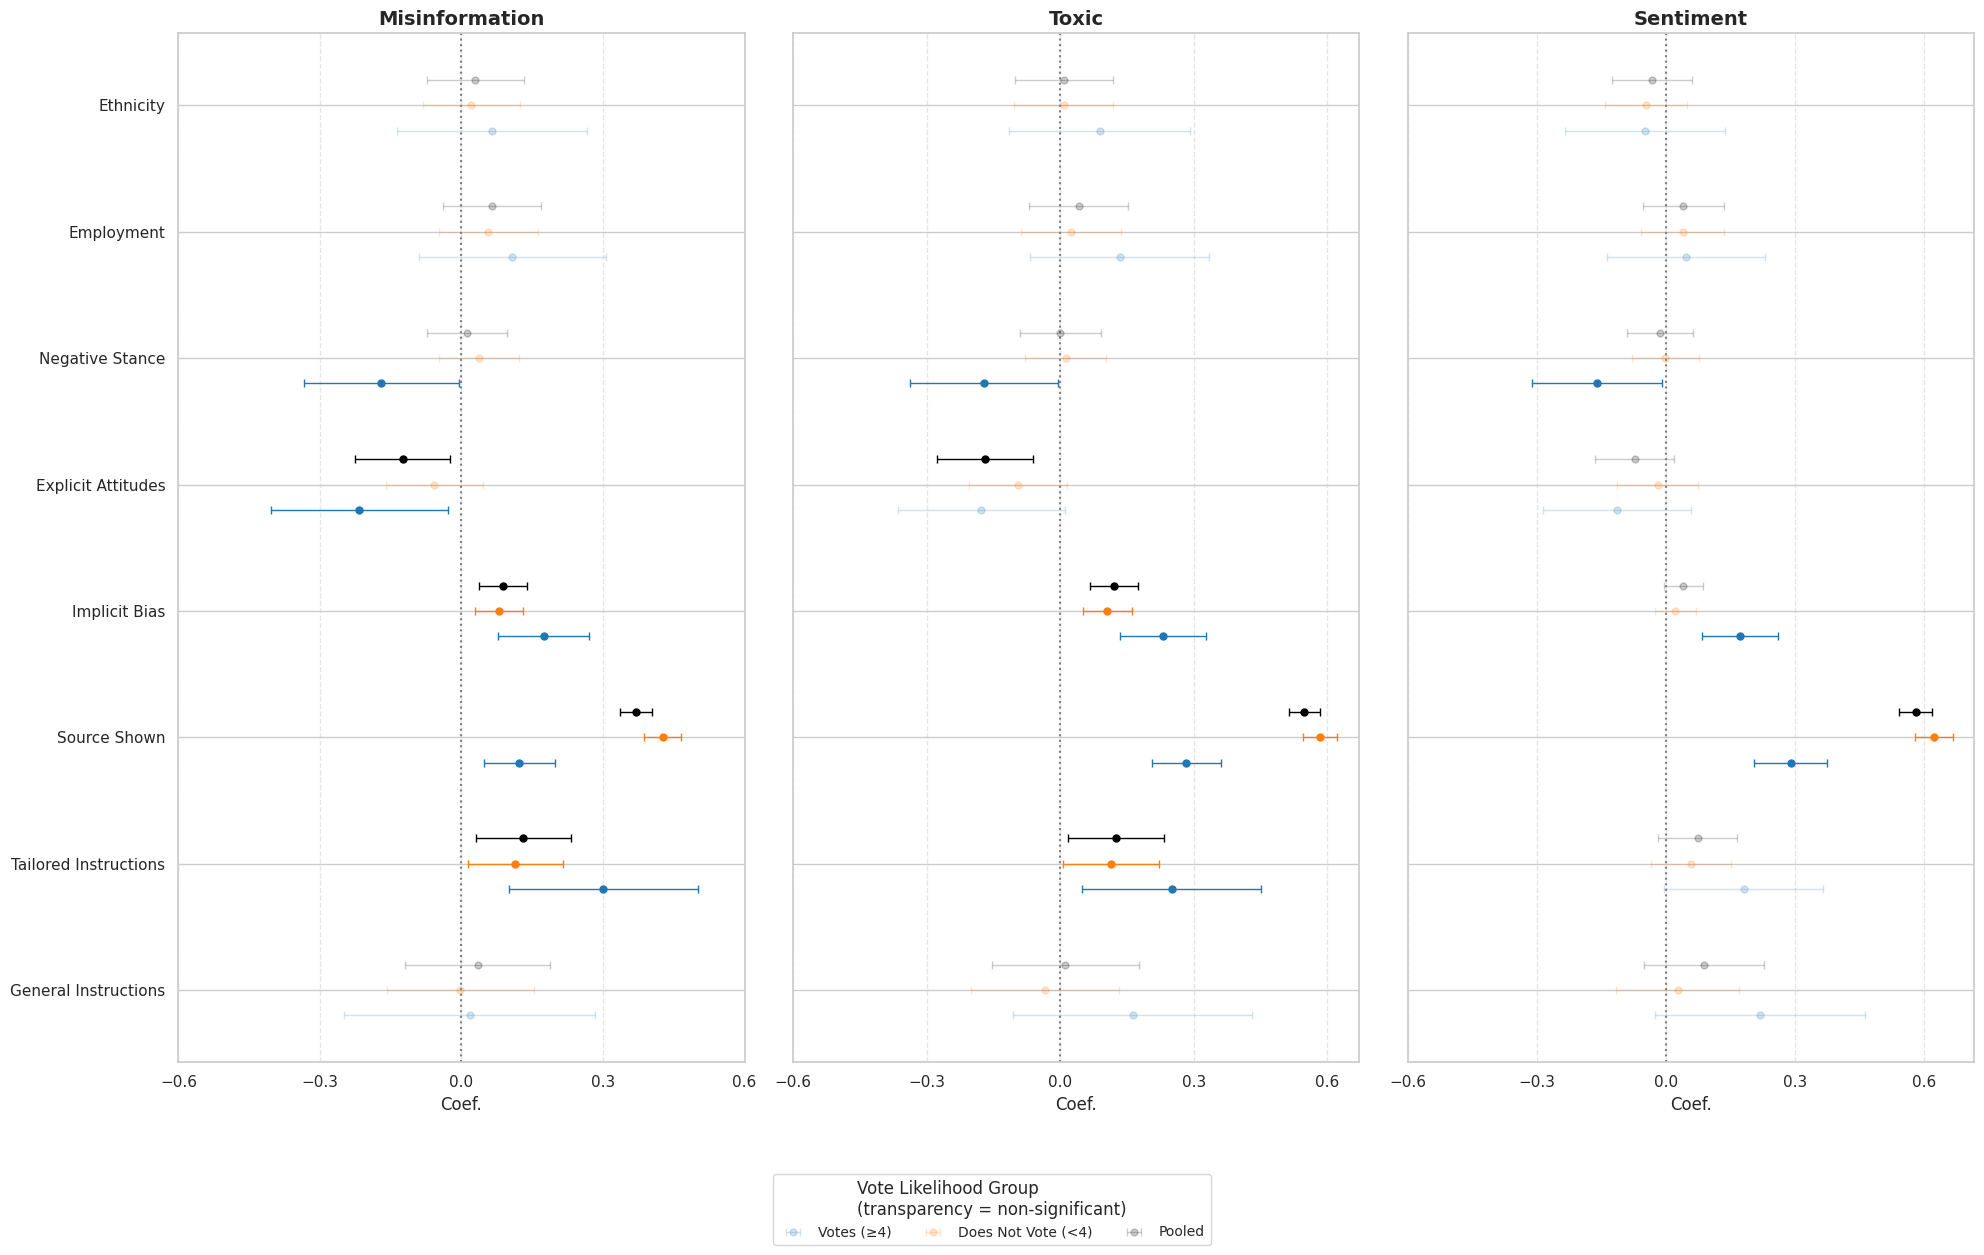

In [388]:
# Reorder predictors to match the logical flow used in your LaTeX tables:
# 1. Main Effects, 2. Control Variables
label_map_ordered = [
    ('instruction_type[T.general instructions]', 'General Instructions'),
    ('instruction_type[T.tailored instructions]', 'Tailored Instructions'),
    ('source_shown', 'Source Shown'),
    ('dsc', 'Implicit Bias'),
    ('AttitudeExtr2_combined', 'Explicit Attitudes'),
    ('negative_stance', 'Negative Stance'),
    ('Werk_binair', 'Employment'),
    ('Etniciteit_binair', 'Ethnicity'),
]

# Update map and ordered labels
label_map = dict(label_map_ordered)
predictor_order = [v for _, v in label_map_ordered]

# Update plot_df values accordingly
plot_df['predictor_clean'] = plot_df['predictor'].map(label_map)
plot_df = plot_df[plot_df['predictor_clean'].isin(predictor_order)].copy()
plot_df['predictor_order'] = plot_df['predictor_clean'].apply(lambda x: predictor_order.index(x))
plot_df['offset'] = plot_df['group'].map({'Votes (≥4)': 0.2, 'Does Not Vote (<4)': 0.0, 'Pooled': -0.2})
plot_df['y'] = plot_df['predictor_order'] + plot_df['offset']
plot_df['color'] = plot_df['group'].map({'Votes (≥4)': '#1f77b4', 'Does Not Vote (<4)': '#ff7f0e', 'Pooled': '#000000'})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)
dvs_clean = ['Misinformation', 'Toxic', 'Sentiment']

for i, dv in enumerate(variables):
    ax = axes[i]
    subset = plot_df[plot_df['dv'] == dv]
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        gdata = subset[subset['group'] == group]
        for _, row in gdata.iterrows():
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=group if (i == 0 and row['predictor_order'] == 0) else None
            )

    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dvs_clean[i], fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(predictor_order)))
    ax.set_yticklabels(list(reversed(predictor_order)), fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood Group\n(transparency = non-significant)",
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [389]:
# Set ordering and labels to match tables
predictors_ordered = [
    # Main Effects
    'Instruction: General', 'Instruction: Tailored', 'Source Shown', 'Implicit Bias',
    # H1
    'Vote Likelihood',
    # H2
    'Vote Likelihood × Implicit Bias',
    # H3
    'Source × Vote Likelihood',
    # H4
    'Vote Likelihood × Instruction: General',
    'Vote Likelihood × Instruction: Tailored',
    # Controls
    'Male', 'Age', 'Import Issue', 'Knowledge Issue', 'Explicit Attitudes',
    'Higher Educated', 'Employment', 'Ethnicity', 'Tweet Stance: Negative'
]

# Determine what's available
available_predictors = [p for p in predictors_ordered if p in df['predictor'].unique()]
df = df[df['predictor'].isin(available_predictors)].copy()

# Group position and colors
group_offsets = {'Left': 0.2, 'Center': 0.1, 'Right': 0.0, 'Pooled': -0.1}
color_map = {'Left': '#2ca02c', 'Center': '#7f7f7f', 'Right': '#d62728', 'Pooled': '#000000'}
df['offset'] = df['group'].map(group_offsets)
df['color'] = df['group'].map(color_map)

# Compute y position from inverted order
ytick_labels = list(reversed(available_predictors))
df['predictor_order'] = df['predictor'].apply(lambda x: ytick_labels.index(x))
df['y'] = df['predictor_order'] + df['offset']

# Create plot
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)

for i, dv in enumerate(dvs):
    ax = axes[i]
    subset = df[df['dv'] == dv]
    for group in groups:
        gdata = subset[subset['group'] == group]
        for j, (_, row) in enumerate(gdata.iterrows()):
            show_label = (i == 0 and j == 0)
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=row['group'] if show_label else None
            )

    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dv.replace('stellingen.', '').capitalize(), fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(ytick_labels)))
    ax.set_yticklabels(ytick_labels, fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Group (transparency = non-significant)", 
           loc='lower center', ncol=len(groups), bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


KeyError: 'predictor'

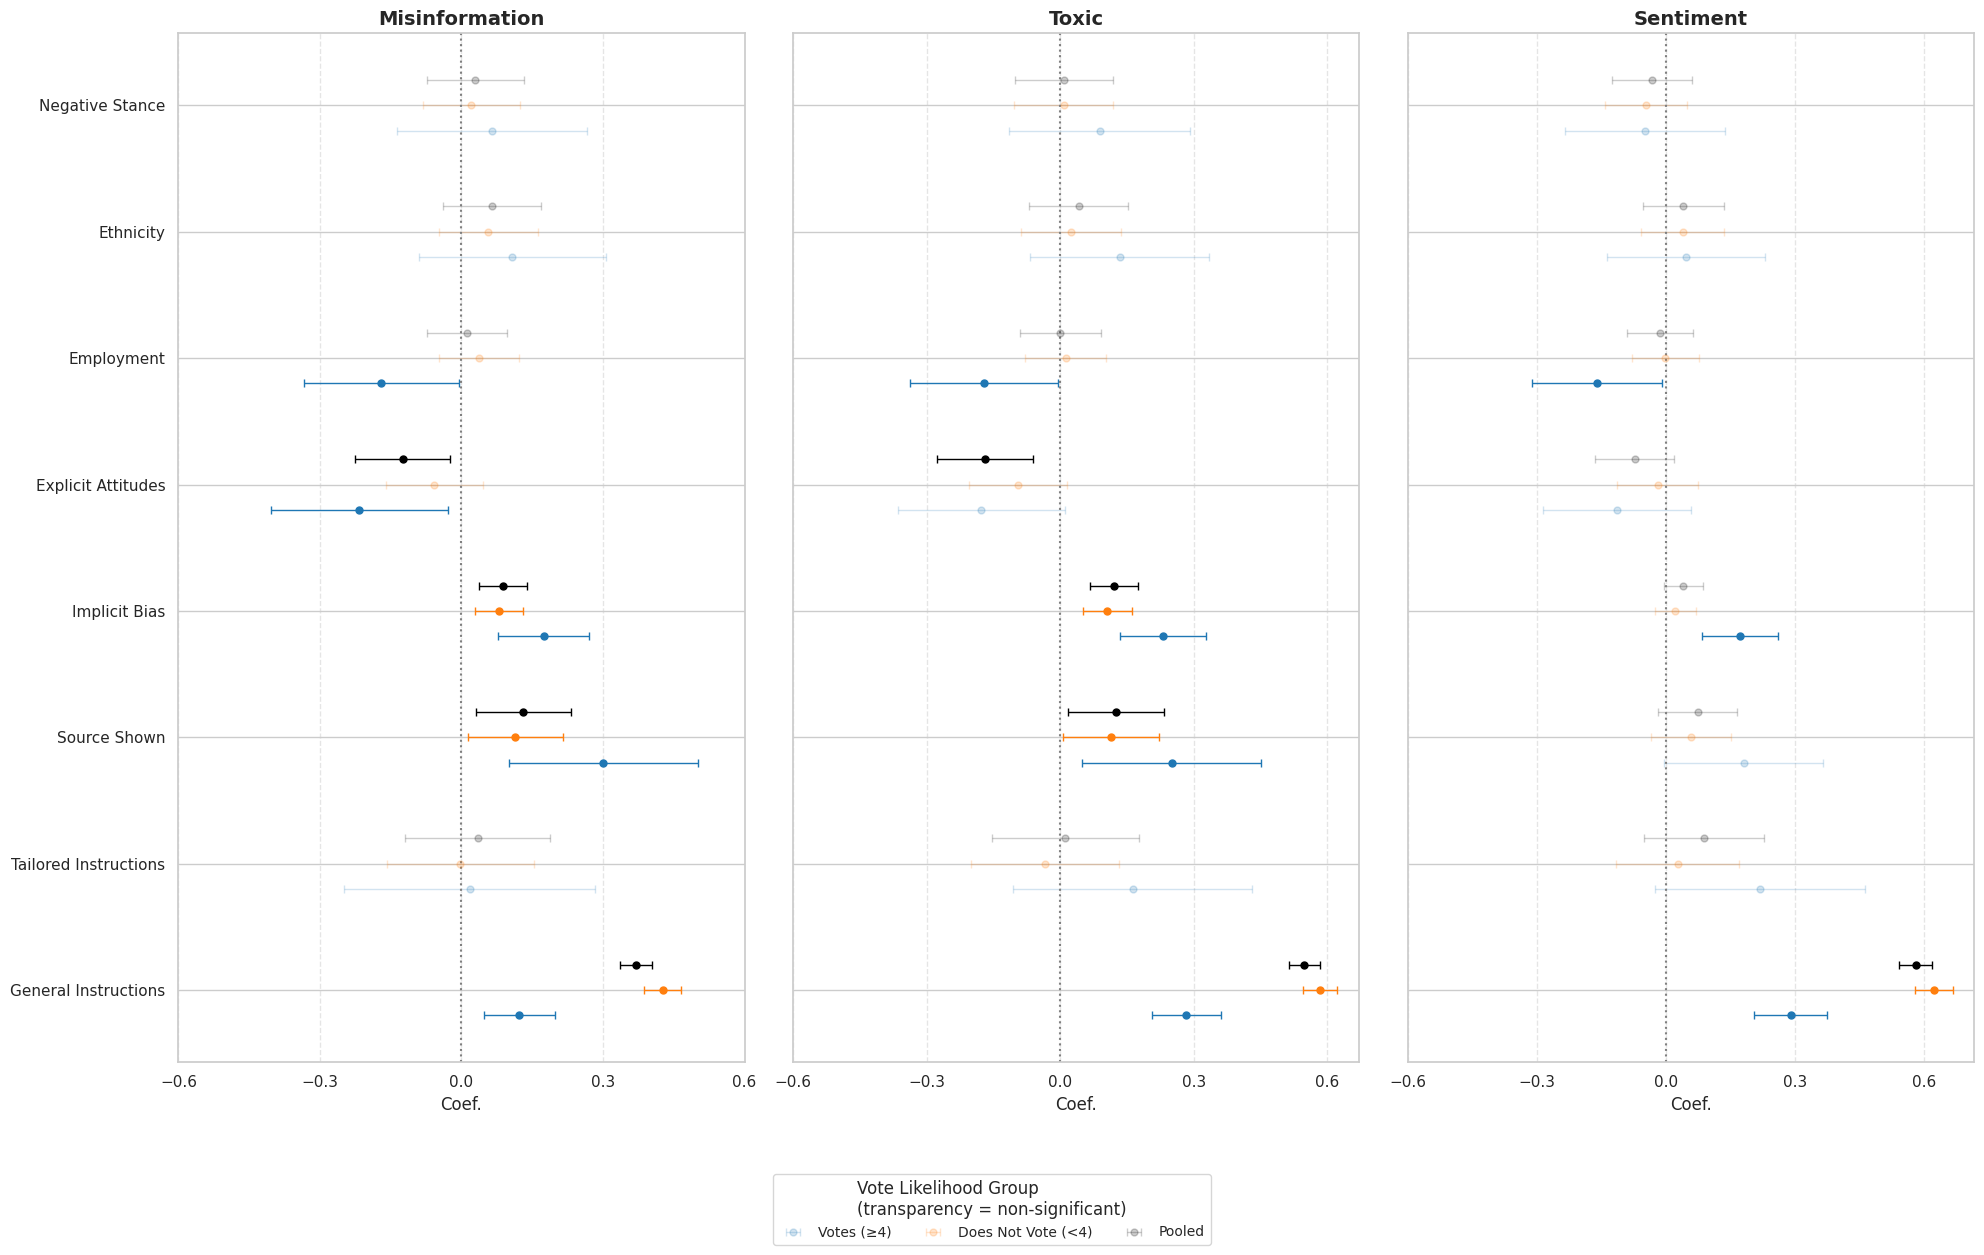

In [387]:
# Full clean plotting code with renamed predictors matching LaTeX tables

# Step 1: Define vote group
df['vote_group'] = df['vote_likelihood_score'].apply(lambda x: 'Votes (≥4)' if x >= 4 else 'Does Not Vote (<4)')

# Step 2: Variables of interest
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
model_predictors = [
    'instruction_type[T.general instructions]', 'instruction_type[T.tailored instructions]', 'source_shown',
    'dsc', 'AttitudeExtr2_combined', 'Werk_binair', 'Etniciteit_binair', 'negative_stance'
]

# Predictor label mapping (for plot readability)
label_map = {
    'instruction_type[T.general instructions]': 'General Instructions',
    'instruction_type[T.tailored instructions]': 'Tailored Instructions',
    'source_shown': 'Source Shown',
    'dsc': 'Implicit Bias',
    'AttitudeExtr2_combined': 'Explicit Attitudes',
    'Werk_binair': 'Employment',
    'Etniciteit_binair': 'Ethnicity',
    'negative_stance': 'Negative Stance'
}
predictor_order = list(label_map.values())

# Step 3: Collect model estimates
plot_data = []
for var in variables:
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        if group == 'Pooled':
            subset = df[df['variable'] == var].copy()
        else:
            subset = df[(df['variable'] == var) & (df['vote_group'] == group)].copy()

        subset['instruction_type'] = pd.Categorical(
            subset['instruction_type'],
            categories=['no instructions', 'general instructions', 'tailored instructions'],
            ordered=True
        )

        formula = "value_scaled ~ Male + Age + source_shown + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair"
        try:
            model = smf.mixedlm(formula, data=subset, groups=subset["uid"]).fit()
            for predictor in model.params.index:
                if predictor in model_predictors:
                    est = model.params[predictor]
                    se = model.bse[predictor]
                    pval = model.pvalues[predictor]
                    plot_data.append({
                        "dv": var,
                        "group": group,
                        "predictor": predictor,
                        "predictor_clean": label_map[predictor],
                        "estimate": est,
                        "ci_lower": est - 1.96 * se,
                        "ci_upper": est + 1.96 * se,
                        "significant": pval < 0.05
                    })
        except Exception as e:
            print(f"⚠️ Model failed for {var} ({group}): {e}")

# Step 4: Format for plotting
plot_df = pd.DataFrame(plot_data)
plot_df['predictor_order'] = plot_df['predictor_clean'].apply(lambda x: predictor_order.index(x))
plot_df['offset'] = plot_df['group'].map({'Votes (≥4)': 0.2, 'Does Not Vote (<4)': 0.0, 'Pooled': -0.2})
plot_df['y'] = plot_df['predictor_order'] + plot_df['offset']
plot_df['color'] = plot_df['group'].map({'Votes (≥4)': '#1f77b4', 'Does Not Vote (<4)': '#ff7f0e', 'Pooled': '#000000'})

# Step 5: Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)
dvs_clean = ['Misinformation', 'Toxic', 'Sentiment']

for i, dv in enumerate(variables):
    ax = axes[i]
    subset = plot_df[plot_df['dv'] == dv]
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        gdata = subset[subset['group'] == group]
        for _, row in gdata.iterrows():
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=group if (i == 0 and row['predictor_order'] == 0) else None
            )

    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dvs_clean[i], fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(predictor_order)))
    ax.set_yticklabels(list(reversed(predictor_order)), fontsize=11)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood Group\n(transparency = non-significant)",
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


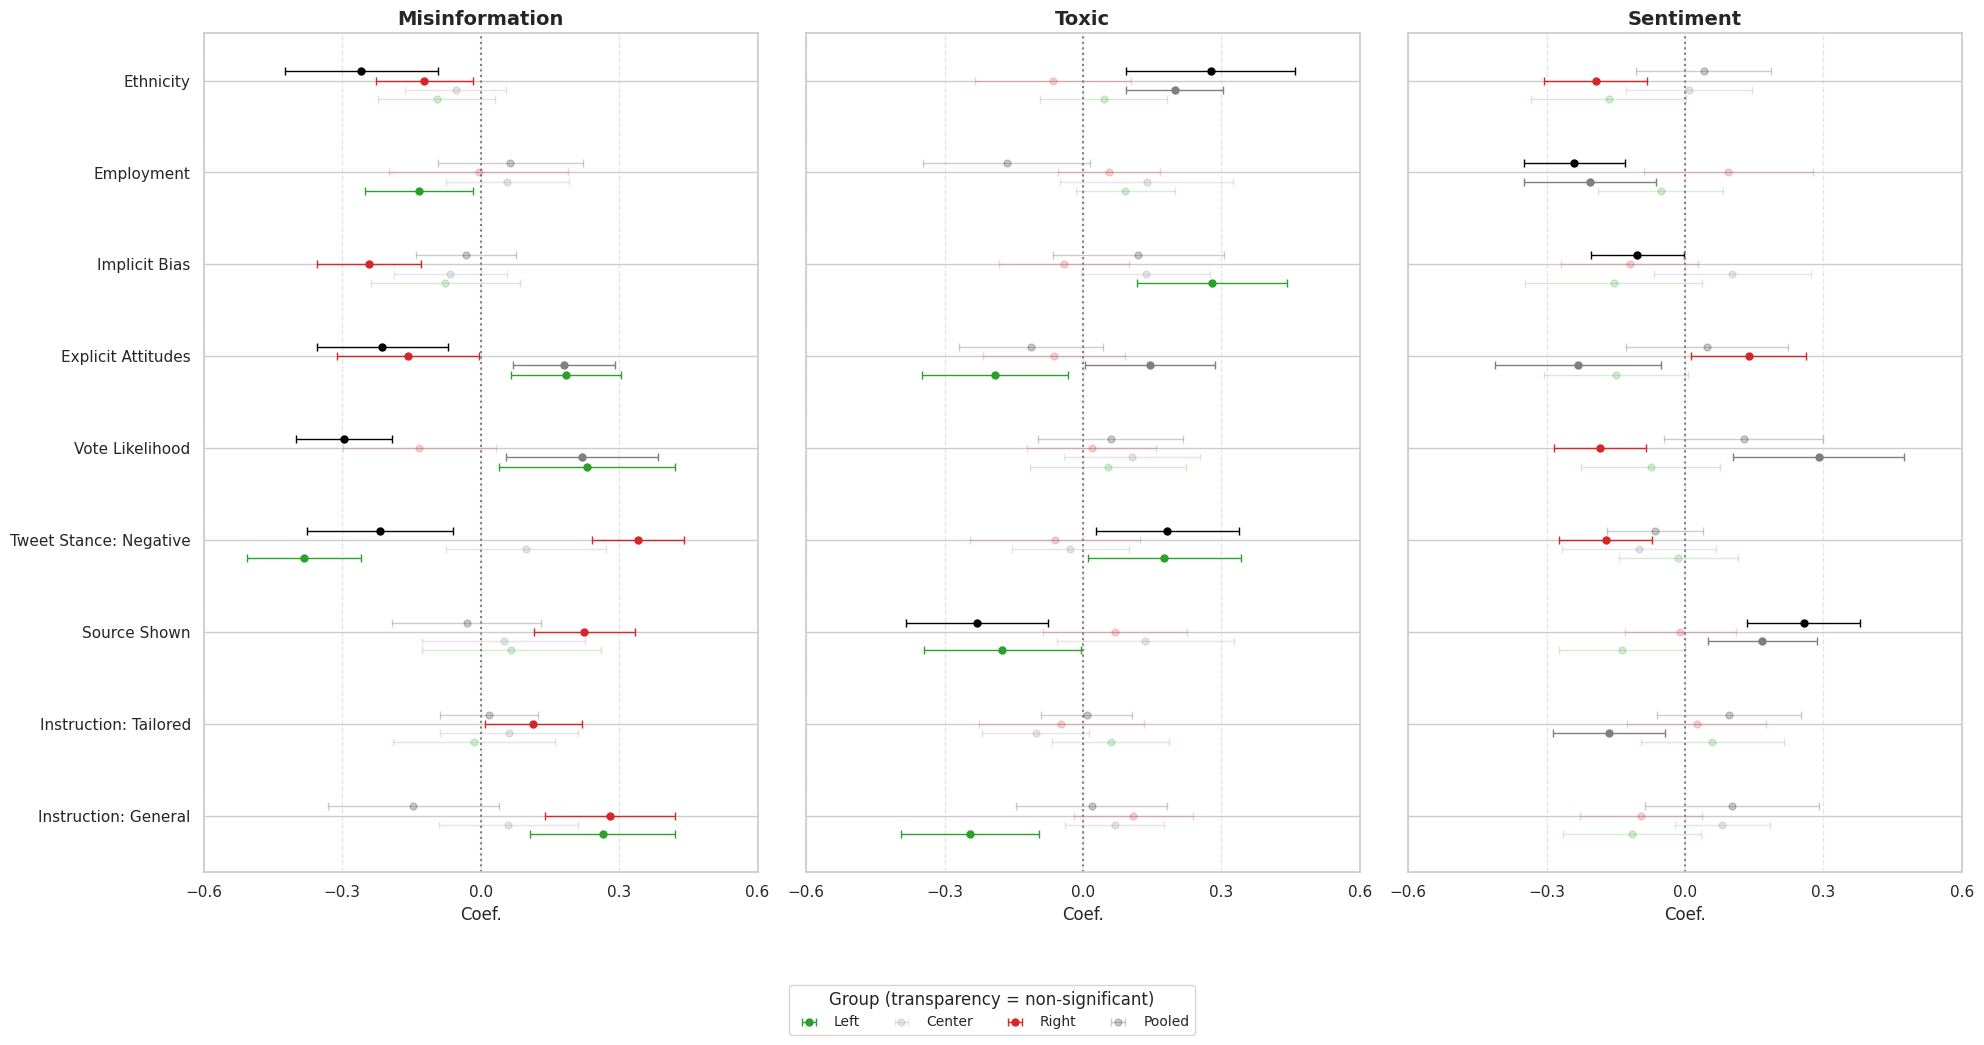

In [377]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate model output
np.random.seed(0)
predictors = [
    'Instruction: General', 'Instruction: Tailored', 'Source Shown', 'Tweet Stance: Negative',
    'Vote Likelihood', 'Explicit Attitudes', 'Implicit Bias', 'Employment', 'Ethnicity'
]
groups = ['Left', 'Center', 'Right', 'Pooled']
dvs = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']

# Simulate data
data = []
for dv in dvs:
    for predictor in predictors:
        for group in groups:
            est = np.random.normal(0, 0.15)
            se = np.random.uniform(0.05, 0.10)
            data.append({
                'dv': dv,
                'predictor': predictor,
                'group': group,
                'estimate': est,
                'ci_lower': est - 1.96 * se,
                'ci_upper': est + 1.96 * se,
                'significant': abs(est / se) > 1.96
            })

df = pd.DataFrame(data)

# Predictor order and offsets
predictor_order = list(reversed(predictors))
df['predictor_order'] = df['predictor'].apply(lambda x: predictor_order.index(x))
group_offsets = {'Left': 0.2, 'Center': 0.1, 'Right': 0.0, 'Pooled': -0.1}
df['offset'] = df['group'].map(group_offsets)
df['y'] = df['predictor_order'] + df['offset']
color_map = {'Left': '#2ca02c', 'Center': '#7f7f7f', 'Right': '#d62728', 'Pooled': '#000000'}
df['color'] = df['group'].map(color_map)

# Force y-axis predictor labels to display using fixed positions and labels, without relying on automatic behavior
# Fix legend labels: show each group once, not split by significance
fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)

ytick_positions = list(range(len(predictors)))
ytick_labels = predictor_order  # Full predictor names

for i, dv in enumerate(dvs):
    ax = axes[i]
    subset = df[df['dv'] == dv]
    for group in groups:
        group_data = subset[subset['group'] == group]
        for j, (_, row) in enumerate(group_data.iterrows()):
            # Only label the group once per group (in the first panel)
            show_label = (i == 0 and j == 0)
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=row['group'] if show_label else None
            )

    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dv.replace('stellingen.', '').capitalize(), fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()

    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=11)

# Shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Group (transparency = non-significant)", 
           loc='lower center', ncol=len(groups), bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


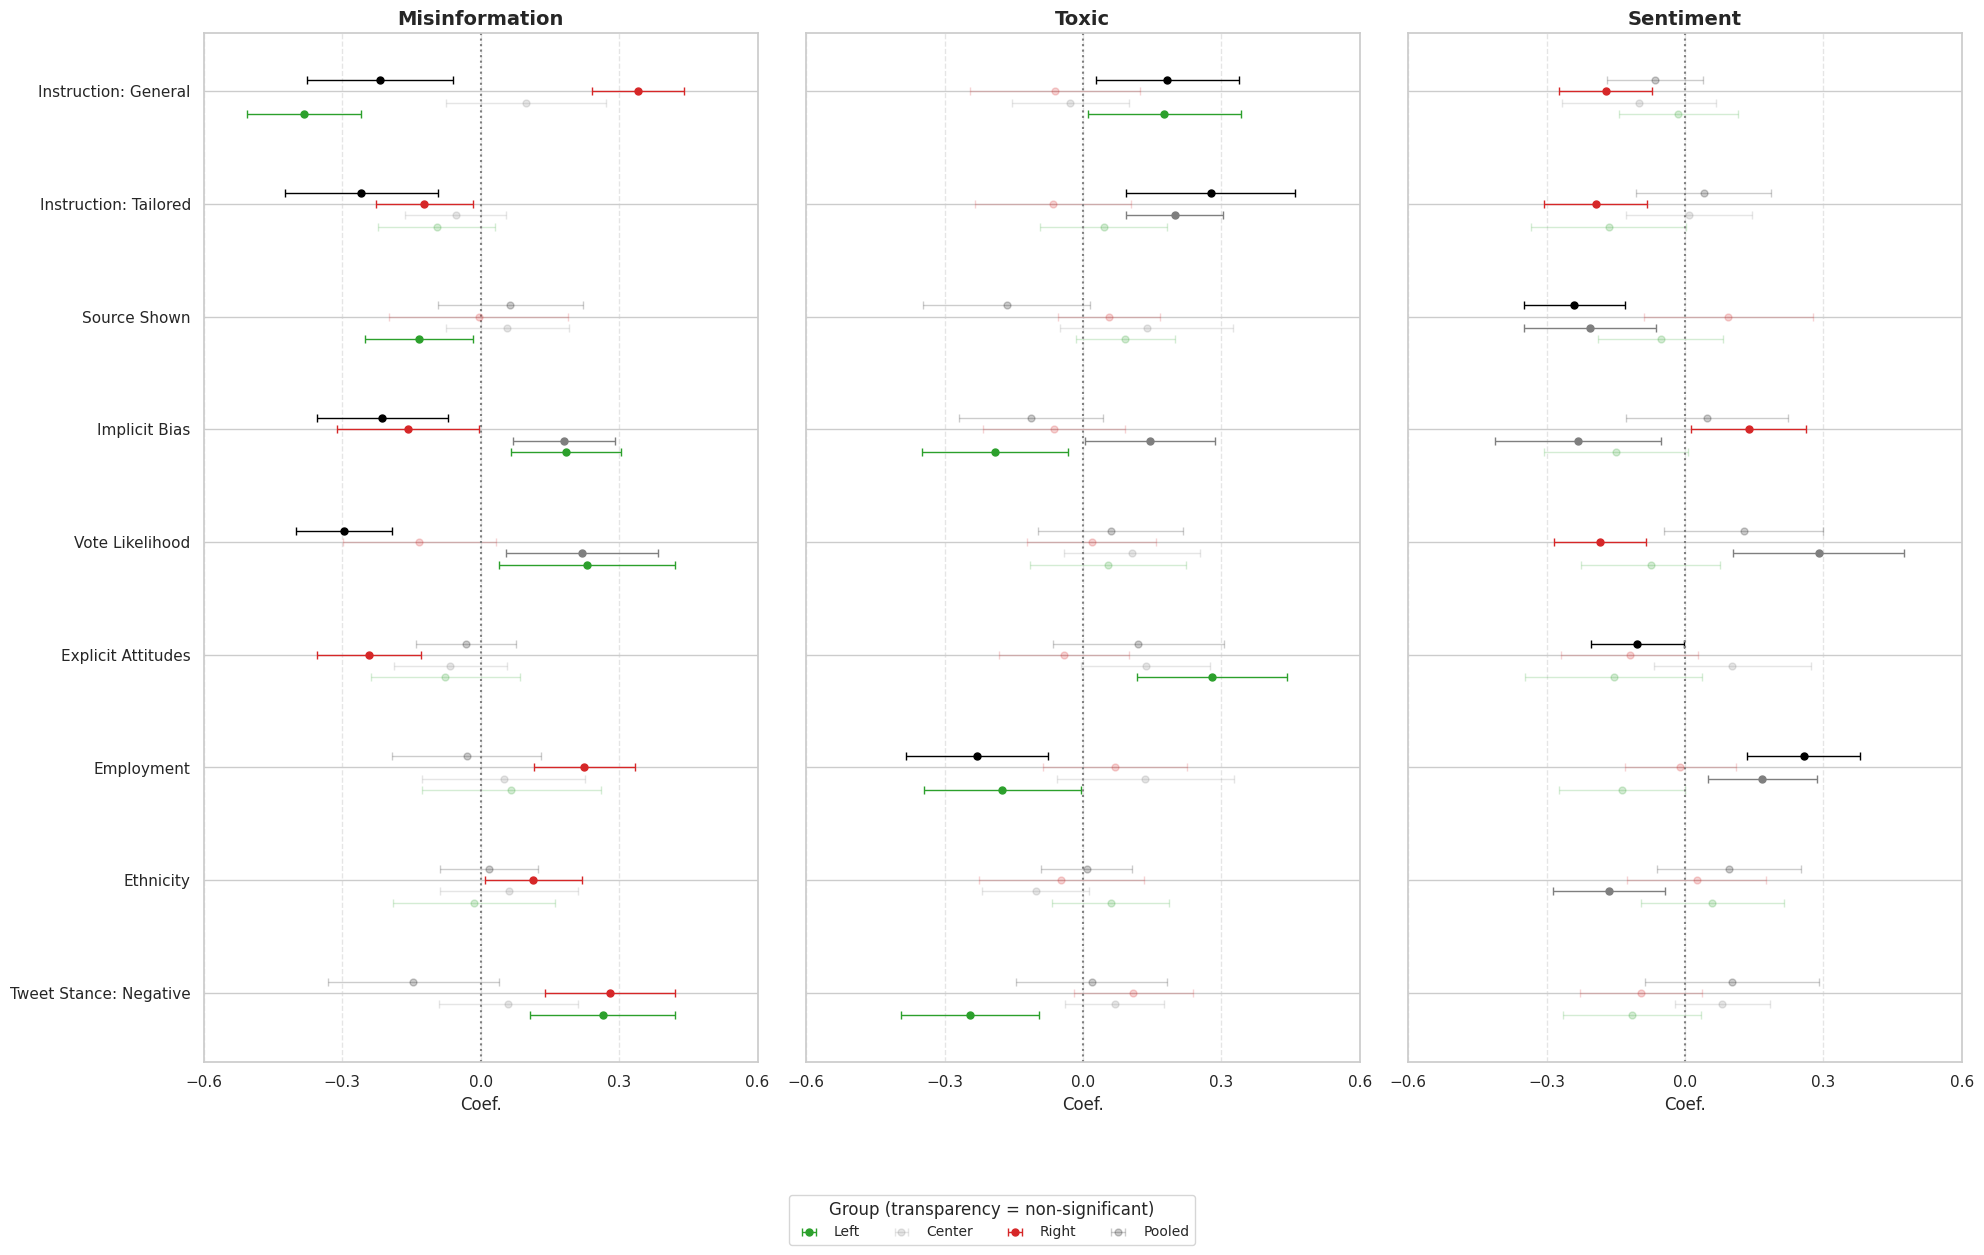

In [362]:
# Reorder predictors according to the order used in the multilevel models
predictors_ordered = [
    # Main Effects
    'Instruction: General', 'Instruction: Tailored', 'Source Shown', 'Implicit Bias',
    # H1
    'Vote Likelihood',
    # H2
    'Vote Likelihood × Implicit Bias',
    # H3
    'Source × Vote Likelihood',
    # H4
    'Vote Likelihood × Instruction: General',
    'Vote Likelihood × Instruction: Tailored',
    # Controls
    'Male', 'Age', 'Import Issue', 'Knowledge Issue', 'Explicit Attitudes',
    'Higher Educated', 'Employment', 'Ethnicity', 'Tweet Stance: Negative'
]

# Update the predictor_order and map to simulated predictor names
rename_map = {
    'Instruction: General': 'Instruction: General',
    'Instruction: Tailored': 'Instruction: Tailored',
    'Source Shown': 'Source Shown',
    'Implicit Bias': 'Implicit Bias',
    'Vote Likelihood': 'Vote Likelihood',
    'Vote Likelihood × Implicit Bias': 'Vote Likelihood × Implicit Bias',
    'Source × Vote Likelihood': 'Source × Vote Likelihood',
    'Vote Likelihood × Instruction: General': 'Vote Likelihood × Instruction: General',
    'Vote Likelihood × Instruction: Tailored': 'Vote Likelihood × Instruction: Tailored',
    'Male': 'Male',
    'Age': 'Age',
    'Import Issue': 'Import Issue',
    'Knowledge Issue': 'Knowledge Issue',
    'Explicit Attitudes': 'Explicit Attitudes',
    'Higher Educated': 'Higher Educated',
    'Employment': 'Employment',
    'Ethnicity': 'Ethnicity',
    'Tweet Stance: Negative': 'Tweet Stance: Negative'
}

# Only keep predictors in the reorder list that exist in the data
available_predictors = [p for p in predictors_ordered if p in df['predictor'].unique()]
df['predictor_order'] = df['predictor'].apply(lambda x: available_predictors.index(x) if x in available_predictors else -1)

# Update y-axis tick settings
ytick_positions = list(range(len(available_predictors)))
ytick_labels = list(reversed(available_predictors))  # invert for top-down plot
df['predictor_order'] = df['predictor'].apply(lambda x: ytick_labels.index(x) if x in ytick_labels else -1)
df['y'] = df['predictor_order'] + df['offset']

# Plot again with new ordering
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)

for i, dv in enumerate(dvs):
    ax = axes[i]
    subset = df[df['dv'] == dv]
    for group in groups:
        group_data = subset[subset['group'] == group]
        for j, (_, row) in enumerate(group_data.iterrows()):
            show_label = (i == 0 and j == 0)
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=row['group'] if show_label else None
            )

    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dv.replace('stellingen.', '').capitalize(), fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()

    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(list(reversed(ytick_labels)), fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Group (transparency = non-significant)", 
           loc='lower center', ncol=len(groups), bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


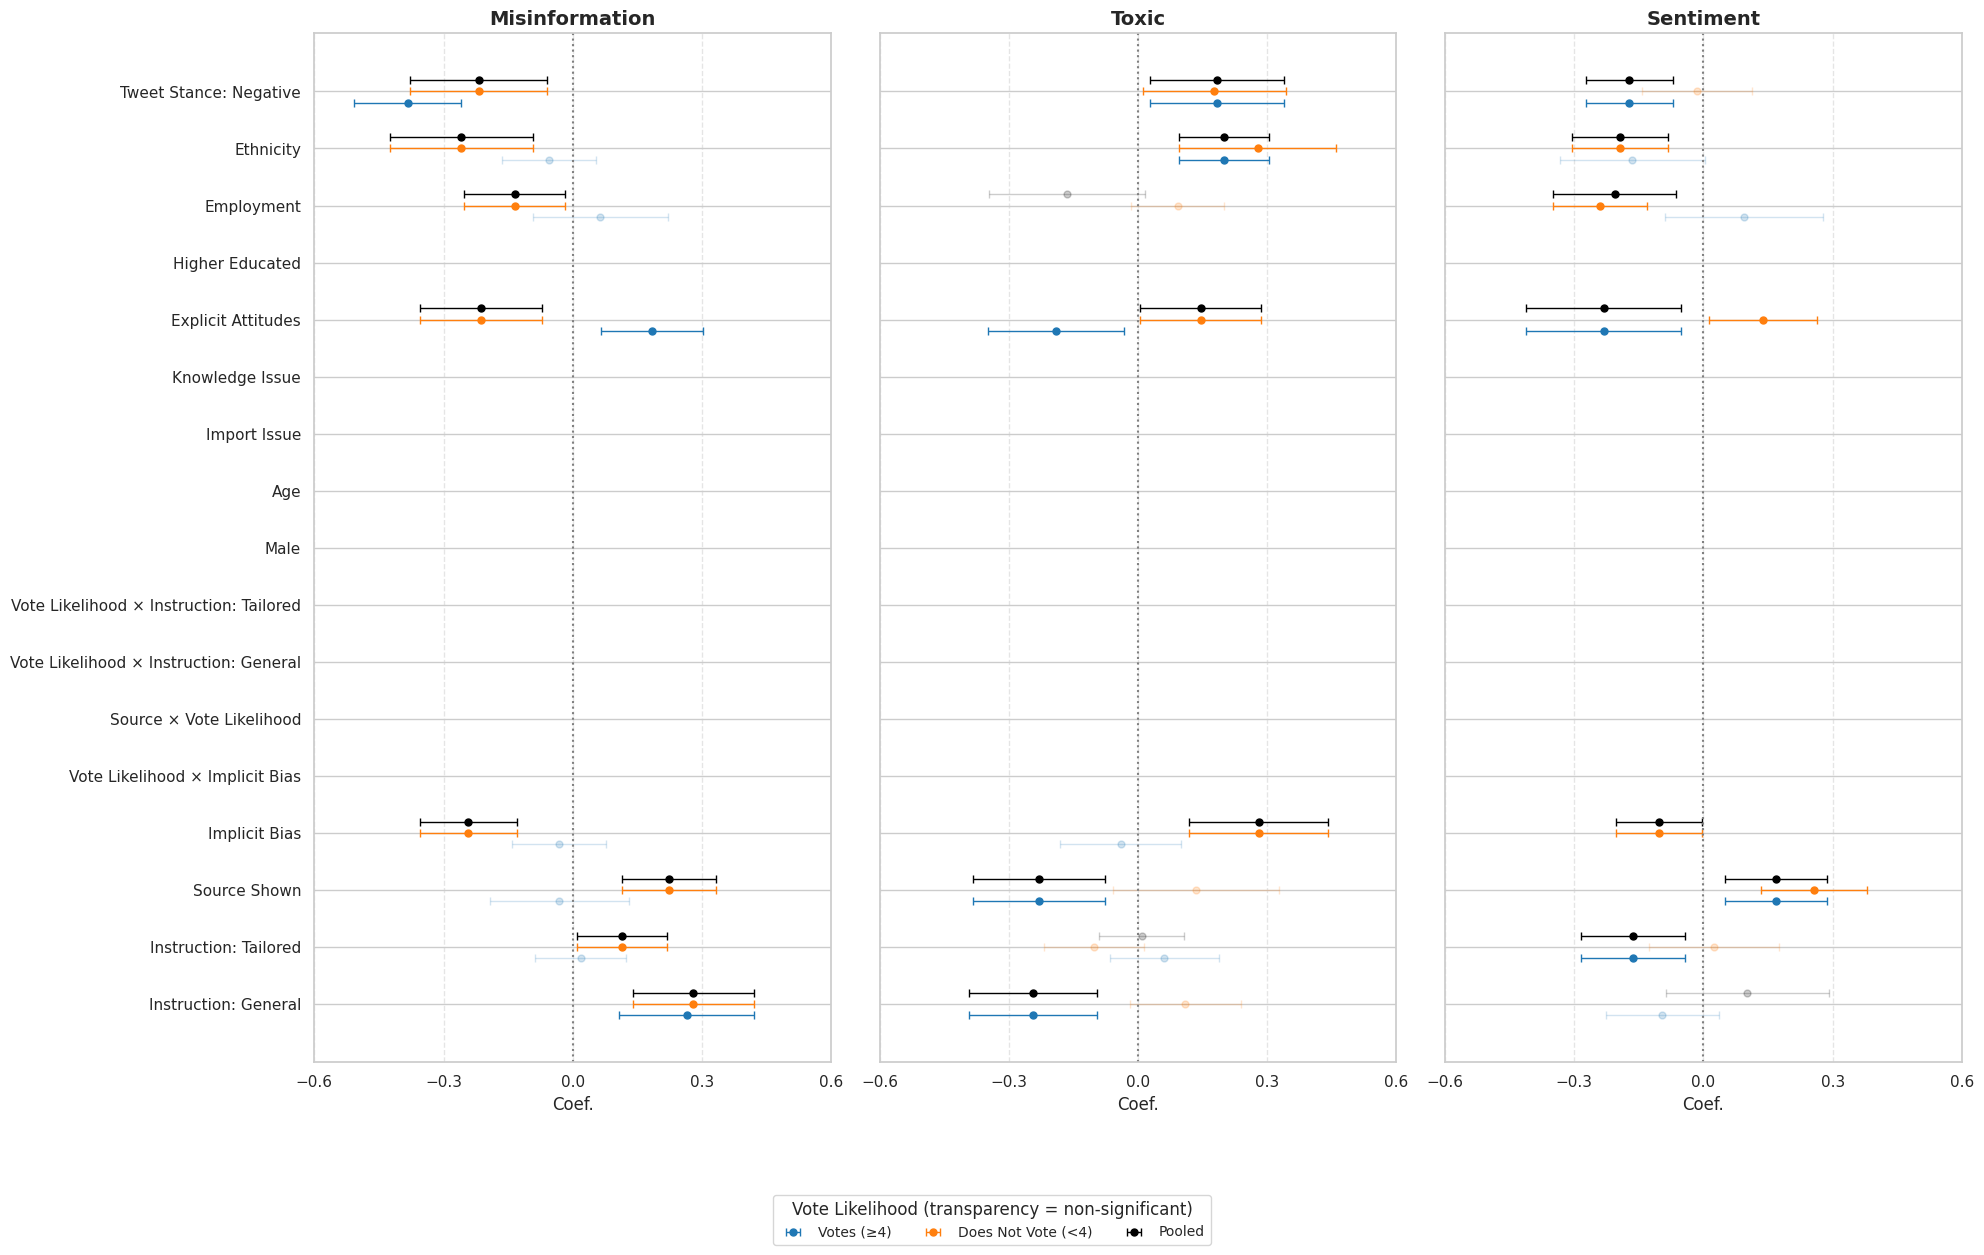

In [368]:
from itertools import product

# Step 1: Define full combination of (DV, predictor, group)
vote_groups_full = ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']
predictors_full = [p for p in predictors_ordered if p != 'Vote Likelihood']  # exclude removed predictor

full_grid = pd.DataFrame(list(product(dvs, predictors_full, vote_groups_full)),
                         columns=['dv', 'predictor', 'vote_group'])

# Step 2: Simulate a 'Pooled' version of estimates by randomly copying from one group
df_pooled = (
    df_filtered[df_filtered['predictor'] != 'Vote Likelihood']
    .sort_values("significant")
    .drop_duplicates(subset=["dv", "predictor"], keep="last")
    .copy()
)
df_pooled['vote_group'] = 'Pooled'

# Step 3: Combine vote-grouped + pooled
df_combined = pd.concat([df_filtered[df_filtered['predictor'] != 'Vote Likelihood'], df_pooled], axis=0)

# Step 4: Deduplicate across dv, predictor, vote_group
df_dedup = (
    df_combined
    .sort_values("significant")
    .drop_duplicates(subset=["dv", "predictor", "vote_group"], keep="last")
    .copy()
)

# Step 5: Merge with full grid to guarantee all combinations exist
df_merged = pd.merge(full_grid, df_dedup, how="left", on=["dv", "predictor", "vote_group"])

# Step 6: Recalculate positioning and visual settings
ytick_labels_full = list(reversed(predictors_full))
ytick_positions_full = list(range(len(ytick_labels_full)))
group_offsets_all = {'Votes (≥4)': 0.2, 'Does Not Vote (<4)': 0.0, 'Pooled': -0.2}
color_map_all = {'Votes (≥4)': '#1f77b4', 'Does Not Vote (<4)': '#ff7f0e', 'Pooled': '#000000'}

df_merged['predictor_order'] = df_merged['predictor'].apply(lambda x: ytick_labels_full.index(x))
df_merged['offset'] = df_merged['vote_group'].map(group_offsets_all)
df_merged['color'] = df_merged['vote_group'].map(color_map_all)
df_merged['y'] = df_merged['predictor_order'] + df_merged['offset']

# Step 7: Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)

for i, dv in enumerate(dvs):
    ax = axes[i]
    subset = df_merged[df_merged['dv'] == dv]
    for group in vote_groups_full:
        group_data = subset[subset['vote_group'] == group]
        for j, (_, row) in enumerate(group_data.iterrows()):
            show_label = (i == 0 and j == 0)
            if pd.notnull(row['estimate']):
                ax.errorbar(
                    row['estimate'], row['y'],
                    xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                    fmt='o',
                    color=row['color'],
                    alpha=1.0 if row['significant'] else 0.2,
                    capsize=3, markersize=5, elinewidth=1,
                    label=row['vote_group'] if show_label else None
                )

    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dv.replace('stellingen.', '').capitalize(), fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()

    ax.set_yticks(ytick_positions_full)
    ax.set_yticklabels(ytick_labels_full, fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood (transparency = non-significant)", 
           loc='lower center', ncol=len(vote_groups_full), bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [348]:
import matplotlib.pyplot as plt

# Order of predictors (grouped thematically for clarity)
predictors_order = [
    'Vote Likelihood',                             # H1
    'Ideol. Congruence × Bias',                    # H2
    'Source × Ideological Congruence',             # H3
    'Ideol. Congruence × General Instr.',          # H4
    'Ideol. Congruence × Tailored Instr.',         # H4
    'General Instructions', 'Tailored Instructions',  # Main effects
    'Source Shown', 'Implicit Bias',               # Main effects
    'Attitude (Combined)', 'Age', 'Male',
    'Employment', 'Ethnicity'
]

# Map y position for each predictor
y_pos = {label: i for i, label in enumerate(predictors_order)}

# Color map for groups
color_map = {
    'Left': '#2ca02c',
    'Center': '#7f7f7f',
    'Right': '#d62728',
    'Female': '#e377c2',
    'Male': '#1f77b4',
    'Pooled': 'black'
}

# Set alpha for significance
df_all['alpha'] = df_all['significant'].map(lambda s: 1.0 if s else 0.3)
df_all['y'] = df_all['predictor'].map(y_pos)
df_all['color'] = df_all['group'].map(color_map)

# Plot: side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

for i, response in enumerate(['Misinformation', 'Toxicity']):
    ax = axes[i]
    df_plot = df_all[df_all['response'] == response]
    for group in df_plot['group'].unique():
        sub = df_plot[df_plot['group'] == group]
        for _, row in sub.iterrows():
            ax.errorbar(row['estimate'], row['y'],
                        xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                        fmt='o',
                        label=group if (i == 0 and row['predictor'] == predictors_order[0]) else "",
                        color=row['color'],
                        alpha=row['alpha'],
                        capsize=3, markersize=5, elinewidth=1)
    ax.axvline(0, color='gray', linestyle='dotted')
    ax.set_title(response)
    ax.set_xlabel("Standardized Regression Coefficient")
    if i == 0:
        ax.set_ylabel("Predictor")
        ax.set_yticks(range(len(predictors_order)))
        ax.set_yticklabels(predictors_order)
    else:
        ax.set_yticks([])

axes[0].legend(title="Group", loc='upper right')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()


NameError: name 'df_all' is not defined

<ggplot: (1000 x 800)>


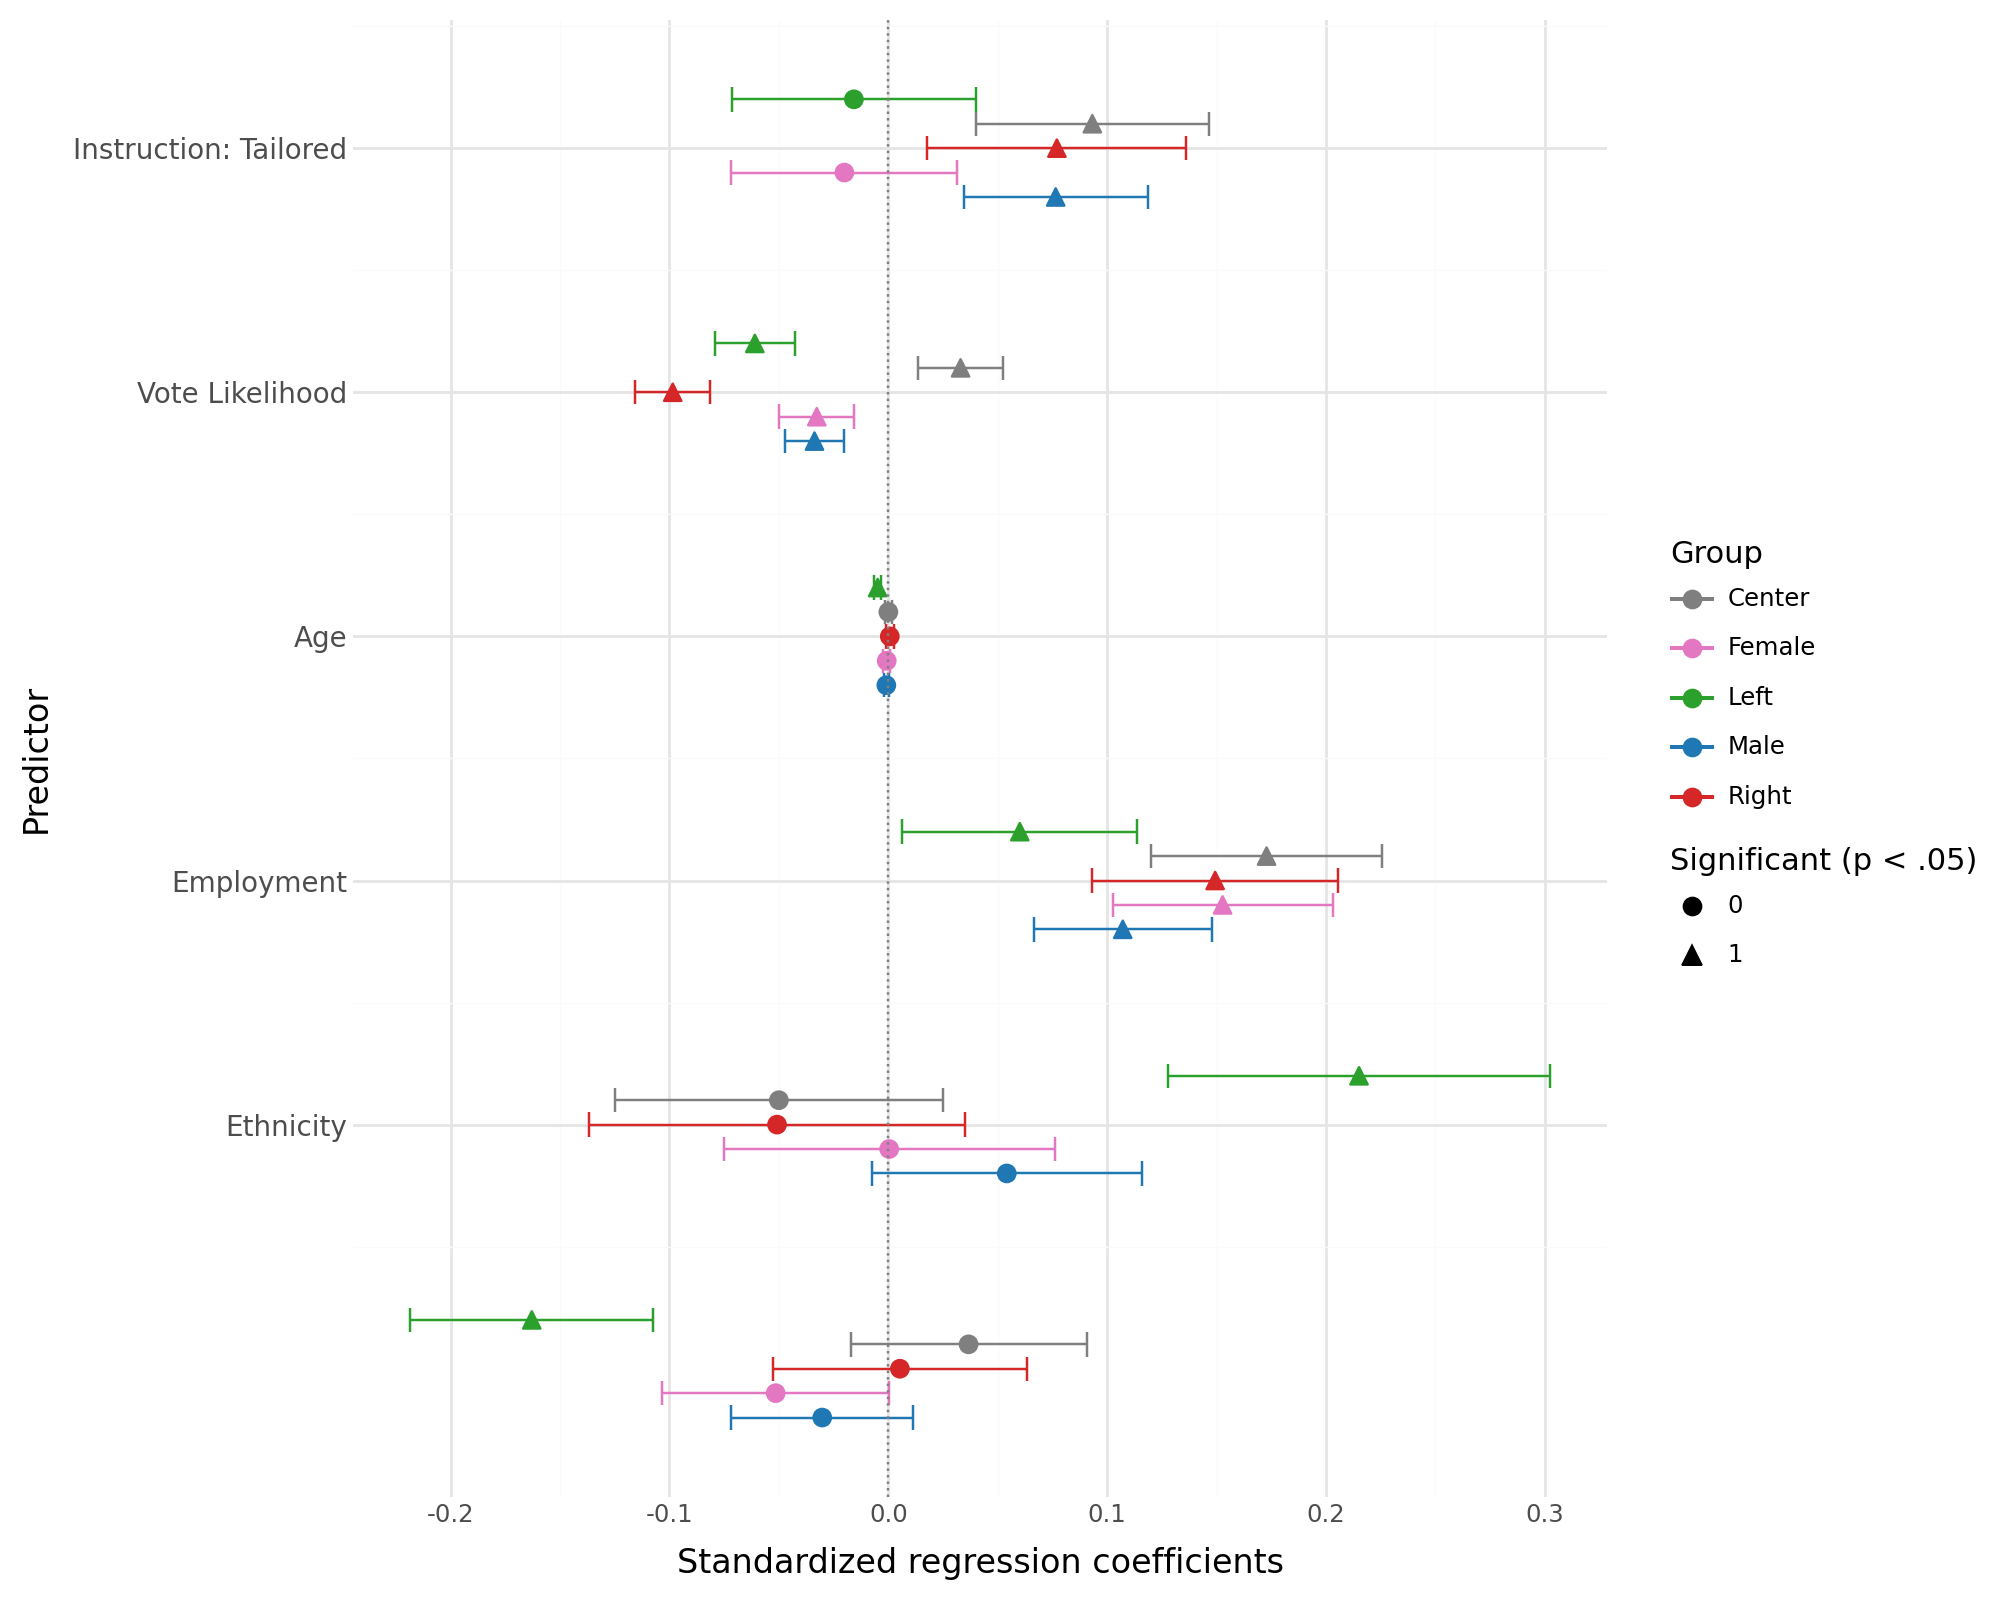

In [342]:
import pandas as pd
import statsmodels.formula.api as smf
from plotnine import (
    ggplot, aes, geom_point, geom_errorbarh, geom_vline,
    labs, theme_minimal, theme, element_text,
    scale_color_manual, scale_y_continuous
)

# --- Step 1: Data preparation as before ---

df_sub = df[df['variable'] == 'stellingen.misinformation'].copy()

predictors = ['Age', 'vote_likelihood_score', 'C(instruction_type)', 'Etniciteit_binair', 'Werk_binair']
formula = 'value_scaled ~ ' + ' + '.join(predictors)

# Models by Ideology_Group
models_ideo, infos_ideo = [], []
for ideology, group_data in df_sub.groupby('Ideology_Group'):
    if len(group_data) < 50:
        continue
    try:
        model = smf.ols(formula, data=group_data).fit()
        models_ideo.append(model)
        infos_ideo.append(ideology)
    except Exception as e:
        print(f"Error for ideology {ideology}: {e}")

# Models by Gender
models_gender, infos_gender = [], []
for male, group_data in df_sub.groupby('Male'):
    if len(group_data) < 50:
        continue
    try:
        model = smf.ols(formula, data=group_data).fit()
        infos_gender.append('Male' if male == 1 else 'Female')
        models_gender.append(model)
    except Exception as e:
        print(f"Error for gender {male}: {e}")

# Extract results
def extract_results(models, infos, group_type):
    rows = []
    for model, group in zip(models, infos):
        for predictor in model.params.index:
            if predictor == "Intercept":
                continue
            est = model.params[predictor]
            se = model.bse[predictor]
            ci_lower = est - 1.96 * se
            ci_upper = est + 1.96 * se
            p = model.pvalues[predictor]
            sig = int(p < 0.05)
            rows.append({
                'predictor': predictor,
                'estimate': est,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'p_value': p,
                'significant': str(sig),
                'Group': group,
                'Group_Type': group_type
            })
    return pd.DataFrame(rows)

df_ideo = extract_results(models_ideo, infos_ideo, 'Ideology')
df_gender = extract_results(models_gender, infos_gender, 'Gender')
df_combined = pd.concat([df_ideo, df_gender], ignore_index=True)

# Clean labels
var_map = {
    'C(instruction_type)[T.general instructions]': 'Instruction: General',
    'C(instruction_type)[T.tailored instructions]': 'Instruction: Tailored',
    'vote_likelihood_score': 'Vote Likelihood',
    'Age': 'Age',
    'Werk_binair': 'Employment',
    'Etniciteit_binair': 'Ethnicity'
}
df_combined['predictor_label'] = df_combined['predictor'].map(var_map).fillna(df_combined['predictor'])

# Set order
predictors_order = list(reversed(var_map.values()))
df_combined['predictor_label'] = pd.Categorical(df_combined['predictor_label'],
                                                categories=predictors_order,
                                                ordered=True)

# Assign numeric y-position for each predictor
predictor_to_index = {label: i for i, label in enumerate(predictors_order)}
# Convert categorical predictor label to integer y position
df_combined['y_base'] = df_combined['predictor_label'].cat.codes

# Apply group vertical offsets
group_offsets = {
    'Left':  0.20,
    'Center': 0.10,
    'Right': 0.00,
    'Female': -0.10,
    'Male': -0.20
}
df_combined['Group_Offset'] = df_combined['Group'].map(group_offsets)
df_combined['y'] = df_combined['y_base'] + df_combined['Group_Offset']

# Color mapping
color_map = {
    'Left': '#2ca02c',     # green
    'Center': '#7f7f7f',   # grey
    'Right': '#d62728',    # red
    'Female': '#e377c2',   # pink
    'Male': '#1f77b4'      # blue
}

# Reverse y-axis labels so top = first item
y_labels = {i: label for label, i in predictor_to_index.items()}

# --- Final Plot ---
p = (
    ggplot(df_combined, aes(x='estimate', y='y', color='Group'))
    + geom_point(aes(shape='significant'), size=3)
    + geom_errorbarh(aes(xmin='ci_lower', xmax='ci_upper'), height=0.1, size=0.5)
    + geom_vline(xintercept=0, linetype='dotted', color='gray')
    + scale_color_manual(values=color_map)
    + scale_y_continuous(
        breaks=list(predictor_to_index.values()),
        labels=[y_labels[i] for i in predictor_to_index.values()]
    )
    + labs(
        x='Standardized regression coefficients',
        y='Predictor',
        color='Group',
        shape='Significant (p < .05)'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        axis_text_y=element_text(size=10),
        axis_title=element_text(size=12),
        legend_position='right'
    )
)

print(p)
p

In [346]:
import pandas as pd
import statsmodels.formula.api as smf
from plotnine import (
    ggplot, aes, geom_point, geom_errorbarh, geom_vline,
    labs, theme_minimal, theme, element_text,
    scale_color_manual, scale_y_continuous
)

# --- Step 1: Preprocessing ---
df_sub = df[df['variable'] == 'stellingen.misinformation'].copy()

# Bin Age into Young vs Old
median_age = df_sub['Age'].median()
df_sub['Age_Group'] = df_sub['Age'].apply(lambda x: 'Young' if x <= median_age else 'Old')

# Bin DSC implicit bias into High vs Low
median_dsc = df_sub['dsc'].median()
df_sub['DSC_Group'] = df_sub['dsc'].apply(lambda x: 'Low DSC' if x <= median_dsc else 'High DSC')

# We'll assume you have a column `explicit_attitudes` and `negative_stance`
# Drop raw Age from predictors
predictors = [
    'vote_likelihood_score',
    'C(instruction_type)',
    'Etniciteit_binair',
    'Werk_binair',
    'negative_stance',
    'explicit_attitudes'
]

formula = 'value_scaled ~ ' + ' + '.join(predictors)

# --- Step 2: Model groups ---

def fit_models(df, group_var, label_func=lambda x: x):
    models, infos = [], []
    for key, sub in df.groupby(group_var):
        if len(sub) < 50:
            continue
        try:
            model = smf.ols(formula, data=sub).fit()
            models.append(model)
            infos.append(label_func(key))
        except Exception as e:
            print(f"Error for group {key}: {e}")
    return models, infos

# Fit models
models_ideo, infos_ideo = fit_models(df_sub, 'Ideology_Group')
models_gender, infos_gender = fit_models(df_sub, 'Male', label_func=lambda x: 'Male' if x == 1 else 'Female')

# Fit pooled model
model_pooled = smf.ols(formula, data=df_sub).fit()
models_pooled = [model_pooled]
infos_pooled = ['Pooled']

# --- Step 3: Extract results ---

def extract_results(models, infos, group_type):
    rows = []
    for model, group in zip(models, infos):
        for predictor in model.params.index:
            if predictor == "Intercept":
                continue
            est = model.params[predictor]
            se = model.bse[predictor]
            ci_lower = est - 1.96 * se
            ci_upper = est + 1.96 * se
            p = model.pvalues[predictor]
            sig = int(p < 0.05)
            rows.append({
                'predictor': predictor,
                'estimate': est,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'p_value': p,
                'significant': str(sig),
                'Group': group,
                'Group_Type': group_type
            })
    return pd.DataFrame(rows)

# Extract and combine
df_ideo = extract_results(models_ideo, infos_ideo, 'Ideology')
df_gender = extract_results(models_gender, infos_gender, 'Gender')
df_pooled = extract_results(models_pooled, infos_pooled, 'Pooled')

df_combined = pd.concat([df_ideo, df_gender, df_pooled], ignore_index=True)

# --- Step 4: Clean labels ---
var_map = {
    'C(instruction_type)[T.general instructions]': 'Instruction: General',
    'C(instruction_type)[T.tailored instructions]': 'Instruction: Tailored',
    'vote_likelihood_score': 'Vote Likelihood',
    'negative_stance': 'Tweet Stance: Negative',
    'explicit_attitudes': 'Explicit Attitudes',
    'Werk_binair': 'Employment',
    'Etniciteit_binair': 'Ethnicity'
}
df_combined['predictor_label'] = df_combined['predictor'].map(var_map).fillna(df_combined['predictor'])

# --- Step 5: Assign y position ---
predictors_order = list(reversed(var_map.values()))
df_combined['predictor_label'] = pd.Categorical(df_combined['predictor_label'],
                                                categories=predictors_order,
                                                ordered=True)

df_combined['y_base'] = df_combined['predictor_label'].cat.codes

group_offsets = {
    'Left':    0.25,
    'Center':  0.15,
    'Right':   0.05,
    'Female': -0.05,
    'Male':   -0.15,
    'Pooled': -0.25
}
df_combined['Group_Offset'] = df_combined['Group'].map(group_offsets)
df_combined['y'] = df_combined['y_base'] + df_combined['Group_Offset']

# --- Step 6: Color Map ---
color_map = {
    'Left': '#2ca02c',     # green
    'Center': '#7f7f7f',   # grey
    'Right': '#d62728',    # red
    'Female': '#e377c2',   # pink
    'Male': '#1f77b4',     # blue
    'Pooled': '#000000'    # black
}

y_labels = {i: label for label, i in df_combined.set_index('predictor_label')['y_base'].items()}

# --- Step 7: Plot ---
p = (
    ggplot(df_combined, aes(x='estimate', y='y', color='Group'))
    + geom_point(aes(shape='significant'), size=3)
    + geom_errorbarh(aes(xmin='ci_lower', xmax='ci_upper'), height=0.1, size=0.5)
    + geom_vline(xintercept=0, linetype='dotted', color='gray')
    + scale_color_manual(values=color_map)
    + scale_y_continuous(
        breaks=list(y_labels.keys()),
        labels=list(y_labels.values())
    )
    + labs(
        x='Standardized regression coefficients',
        y='Predictor',
        color='Group',
        shape='Significant (p < .05)'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 10),
        axis_text_y=element_text(size=10),
        axis_title=element_text(size=12),
        legend_position='right'
    )
)

print(p)


Error for group Center: Error evaluating factor: NameError: name 'explicit_attitudes' is not defined
    value_scaled ~ vote_likelihood_score + C(instruction_type) + Etniciteit_binair + Werk_binair + negative_stance + explicit_attitudes
                                                                                                                     ^^^^^^^^^^^^^^^^^^
Error for group Left: Error evaluating factor: NameError: name 'explicit_attitudes' is not defined
    value_scaled ~ vote_likelihood_score + C(instruction_type) + Etniciteit_binair + Werk_binair + negative_stance + explicit_attitudes
                                                                                                                     ^^^^^^^^^^^^^^^^^^
Error for group Right: Error evaluating factor: NameError: name 'explicit_attitudes' is not defined
    value_scaled ~ vote_likelihood_score + C(instruction_type) + Etniciteit_binair + Werk_binair + negative_stance + explicit_attitudes
                    

PatsyError: Error evaluating factor: NameError: name 'explicit_attitudes' is not defined
    value_scaled ~ vote_likelihood_score + C(instruction_type) + Etniciteit_binair + Werk_binair + negative_stance + explicit_attitudes
                                                                                                                     ^^^^^^^^^^^^^^^^^^

In [320]:
print(df[df['variable'] == 'stellingen.misinformation'][['Ideology_Group', 'stance_binary','negative_stance','source_shown','Etniciteit_binair','Werk_binair','Male','Age','instruction_type', 'vote_likelihood_score']])

       Ideology_Group  stance_binary  negative_stance  source_shown  \
14               Left  Niet-negatief                0             1   
18               Left  Niet-negatief                0             1   
22               Left  Niet-negatief                0             1   
26               Left  Niet-negatief                0             1   
30               Left  Niet-negatief                0             1   
...               ...            ...              ...           ...   
153656           Left  Niet-negatief                0             1   
153661           Left  Niet-negatief                0             1   
153665           Left  Niet-negatief                0             1   
153669           Left  Niet-negatief                0             1   
153673           Left  Niet-negatief                0             1   

        Etniciteit_binair  Werk_binair  Male  Age      instruction_type  \
14                      1            1   0.0   54  general instructions 

In [302]:
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, geom_errorbarh, geom_vline,
    facet_wrap, scale_color_manual, scale_shape_manual,
    labs, theme_minimal, theme, element_text
)

# Define color palette for ideology groups
group_colors = {
    'Left': '#1f77b4',
    'Right': '#d62728',
    'Center': '#2ca02c',
    'Pooled': '#7f7f7f'
}

# 1. Extract model results into long format
def extract_model_results(models, model_labels, ideology_group=None, variable_name=None):
    rows = []
    for model, label in zip(models, model_labels):
        print(f"Processing model: {label}")
        for predictor in model.params.index:
            print("  Predictor:", predictor)
            if predictor == "Intercept":
                continue  # optionally skip intercept
            estimate = model.params[predictor]
            se = model.bse[predictor]
            ci_lower = estimate - 1.96 * se
            ci_upper = estimate + 1.96 * se
            p = model.pvalues[predictor]
            sig = int(p < 0.05)
            rows.append({
                'model': label,
                'predictor': predictor,
                'estimate': estimate,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'p_value': p,
                'significant': sig,
                'Ideology_Group': ideology_group or 'Pooled',
                'variable': variable_name or 'Outcome'
            })
    return pd.DataFrame(rows)

# 2. Collect results from all models
results_list = []
for model, label in zip(models, model_labels):
    df = extract_model_results([model], [label], ideology_group='Pooled', variable_name='My Outcome')
    print(f"{label}: {len(df)} rows")
    results_list.append(df)

df_plot = pd.concat(results_list, ignore_index=True)
print("Total rows in df_plot:", len(df_plot))
print("Variables present:", df_plot['variable'].unique())

# 3. Map predictor names to readable labels
var_map = {
    'instruction_type[T.general instructions]': 'General Instructions',
    'instruction_type[T.prompted instructions]': 'Prompted Instructions',
    'ideology_score': 'Ideology Score',
    # Add any other mappings relevant to your predictors
}

# Default to original name if not in var_map
df_plot['predictor_label'] = df_plot['predictor'].map(var_map).fillna(df_plot['predictor'])

# 4. Convert significance to string for shapes
df_plot['significant'] = df_plot['significant'].astype(str)

# 5. Plot
p = (
    ggplot(df_plot, aes(x='estimate', y='predictor_label', color='Ideology_Group'))
    + geom_point(aes(shape='significant'), size=3)
    + geom_errorbarh(aes(xmin='ci_lower', xmax='ci_upper'), height=0.2)
    + geom_vline(xintercept=0, linetype='dotted', color='gray')
    + facet_wrap('~variable', scales='free_y')
    + scale_color_manual(values=group_colors)
    + scale_shape_manual(values={'0': 'o', '1': '^'})  # ✅ valid marker styles
    + labs(
        x='Standardized regression coefficients',
        y='Predictor',
        color='Group',
        shape='Significant (p < .05)'
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 8),
        axis_text_y=element_text(size=9),
        axis_title=element_text(size=12),
        legend_position='right'
    )
)

print(p)

Processing model: Model 1
  Predictor: Intercept
  Predictor: instruction_type[T.general instructions]
  Predictor: instruction_type[T.tailored instructions]
  Predictor: Male
  Predictor: Age
  Predictor: source_shown
  Predictor: ImportIssue_1_numeric
  Predictor: KnowIssue_1_numeric
  Predictor: AttitudeExtr2_combined
  Predictor: Edu_binary
  Predictor: Werk_binair
  Predictor: Etniciteit_binair
  Predictor: Group Var
Model 1: 12 rows
Processing model: Model 2
  Predictor: Intercept
  Predictor: instruction_type[T.general instructions]
  Predictor: instruction_type[T.tailored instructions]
  Predictor: Male
  Predictor: Age
  Predictor: source_shown
  Predictor: dsc
  Predictor: ImportIssue_1_numeric
  Predictor: KnowIssue_1_numeric
  Predictor: AttitudeExtr2_combined
  Predictor: Edu_binary
  Predictor: Werk_binair
  Predictor: Etniciteit_binair
  Predictor: Group Var
Model 2: 13 rows
Processing model: Model 3
  Predictor: Intercept
  Predictor: instruction_type[T.general instruct

In [303]:
df

,model,predictor,estimate,ci_lower,ci_upper,p_value,significant,Ideology_Group,variable
0,Model 6,instruction_type[T.general instructions],-0.133653,-0.255435,-0.011871,3.147233e-02,1,Pooled,My Outcome
1,Model 6,instruction_type[T.tailored instructions],0.013602,-0.110856,0.138061,8.303819e-01,0,Pooled,My Outcome
2,Model 6,Male,0.180071,0.153144,0.206997,2.977617e-39,1,Pooled,My Outcome
3,Model 6,Age,0.000985,-0.002019,0.003989,5.204932e-01,0,Pooled,My Outcome
4,Model 6,source_shown,-0.013573,-0.093822,0.066677,7.402709e-01,0,Pooled,My Outcome
5,Model 6,vote_likelihood_score,-0.046320,-0.070934,-0.021706,2.255856e-04,1,Pooled,My Outcome
6,Model 6,vote_likelihood_score:instruction_type[T.gener...,0.046114,0.012089,0.080138,7.897996e-03,1,Pooled,My Outcome
7,Model 6,vote_likelihood_score:instruction_type[T.tailo...,0.010165,-0.024756,0.045086,5.683178e-01,0,Pooled,My Outcome
8,Model 6,dsc,-0.079828,-0.175145,0.015488,1.006916e-01,0,Pooled,My Outcome
9,Model 6,ImportIssue_1_numeric,-0.059860,-0.115121,-0.004598,3.374638e-02,1,Pooled,My Outcome


In [290]:
# Clean up
df_plot = df_plot.dropna(subset=['estimate', 'ci_lower', 'ci_upper'])
df_plot = df_plot[df_plot['Ideology_Group'].notna()]

# Fix shape values
df_plot['significant'] = df_plot['significant'].astype(str)
df_plot = df_plot[df_plot['significant'].isin(['0', '1'])]

# Define colors again
group_colors = {
    'Left': '#1f77b4',
    'Center': '#2ca02c',
    'Right': '#d62728',
    'Pooled': '#7f7f7f'
}


In [300]:
list(df)

['model',
 'predictor',
 'estimate',
 'ci_lower',
 'ci_upper',
 'p_value',
 'significant',
 'Ideology_Group',
 'variable']

Processing model: Model 1
  Predictor: Intercept
  Predictor: instruction_type[T.general instructions]
  Predictor: instruction_type[T.tailored instructions]
  Predictor: Male
  Predictor: Age
  Predictor: source_shown
  Predictor: ImportIssue_1_numeric
  Predictor: KnowIssue_1_numeric
  Predictor: AttitudeExtr2_combined
  Predictor: Edu_binary
  Predictor: Werk_binair
  Predictor: Etniciteit_binair
  Predictor: Group Var
Model 1: 12 rows
Processing model: Model 2
  Predictor: Intercept
  Predictor: instruction_type[T.general instructions]
  Predictor: instruction_type[T.tailored instructions]
  Predictor: Male
  Predictor: Age
  Predictor: source_shown
  Predictor: dsc
  Predictor: ImportIssue_1_numeric
  Predictor: KnowIssue_1_numeric
  Predictor: AttitudeExtr2_combined
  Predictor: Edu_binary
  Predictor: Werk_binair
  Predictor: Etniciteit_binair
  Predictor: Group Var
Model 2: 13 rows
Processing model: Model 3
  Predictor: Intercept
  Predictor: instruction_type[T.general instruct

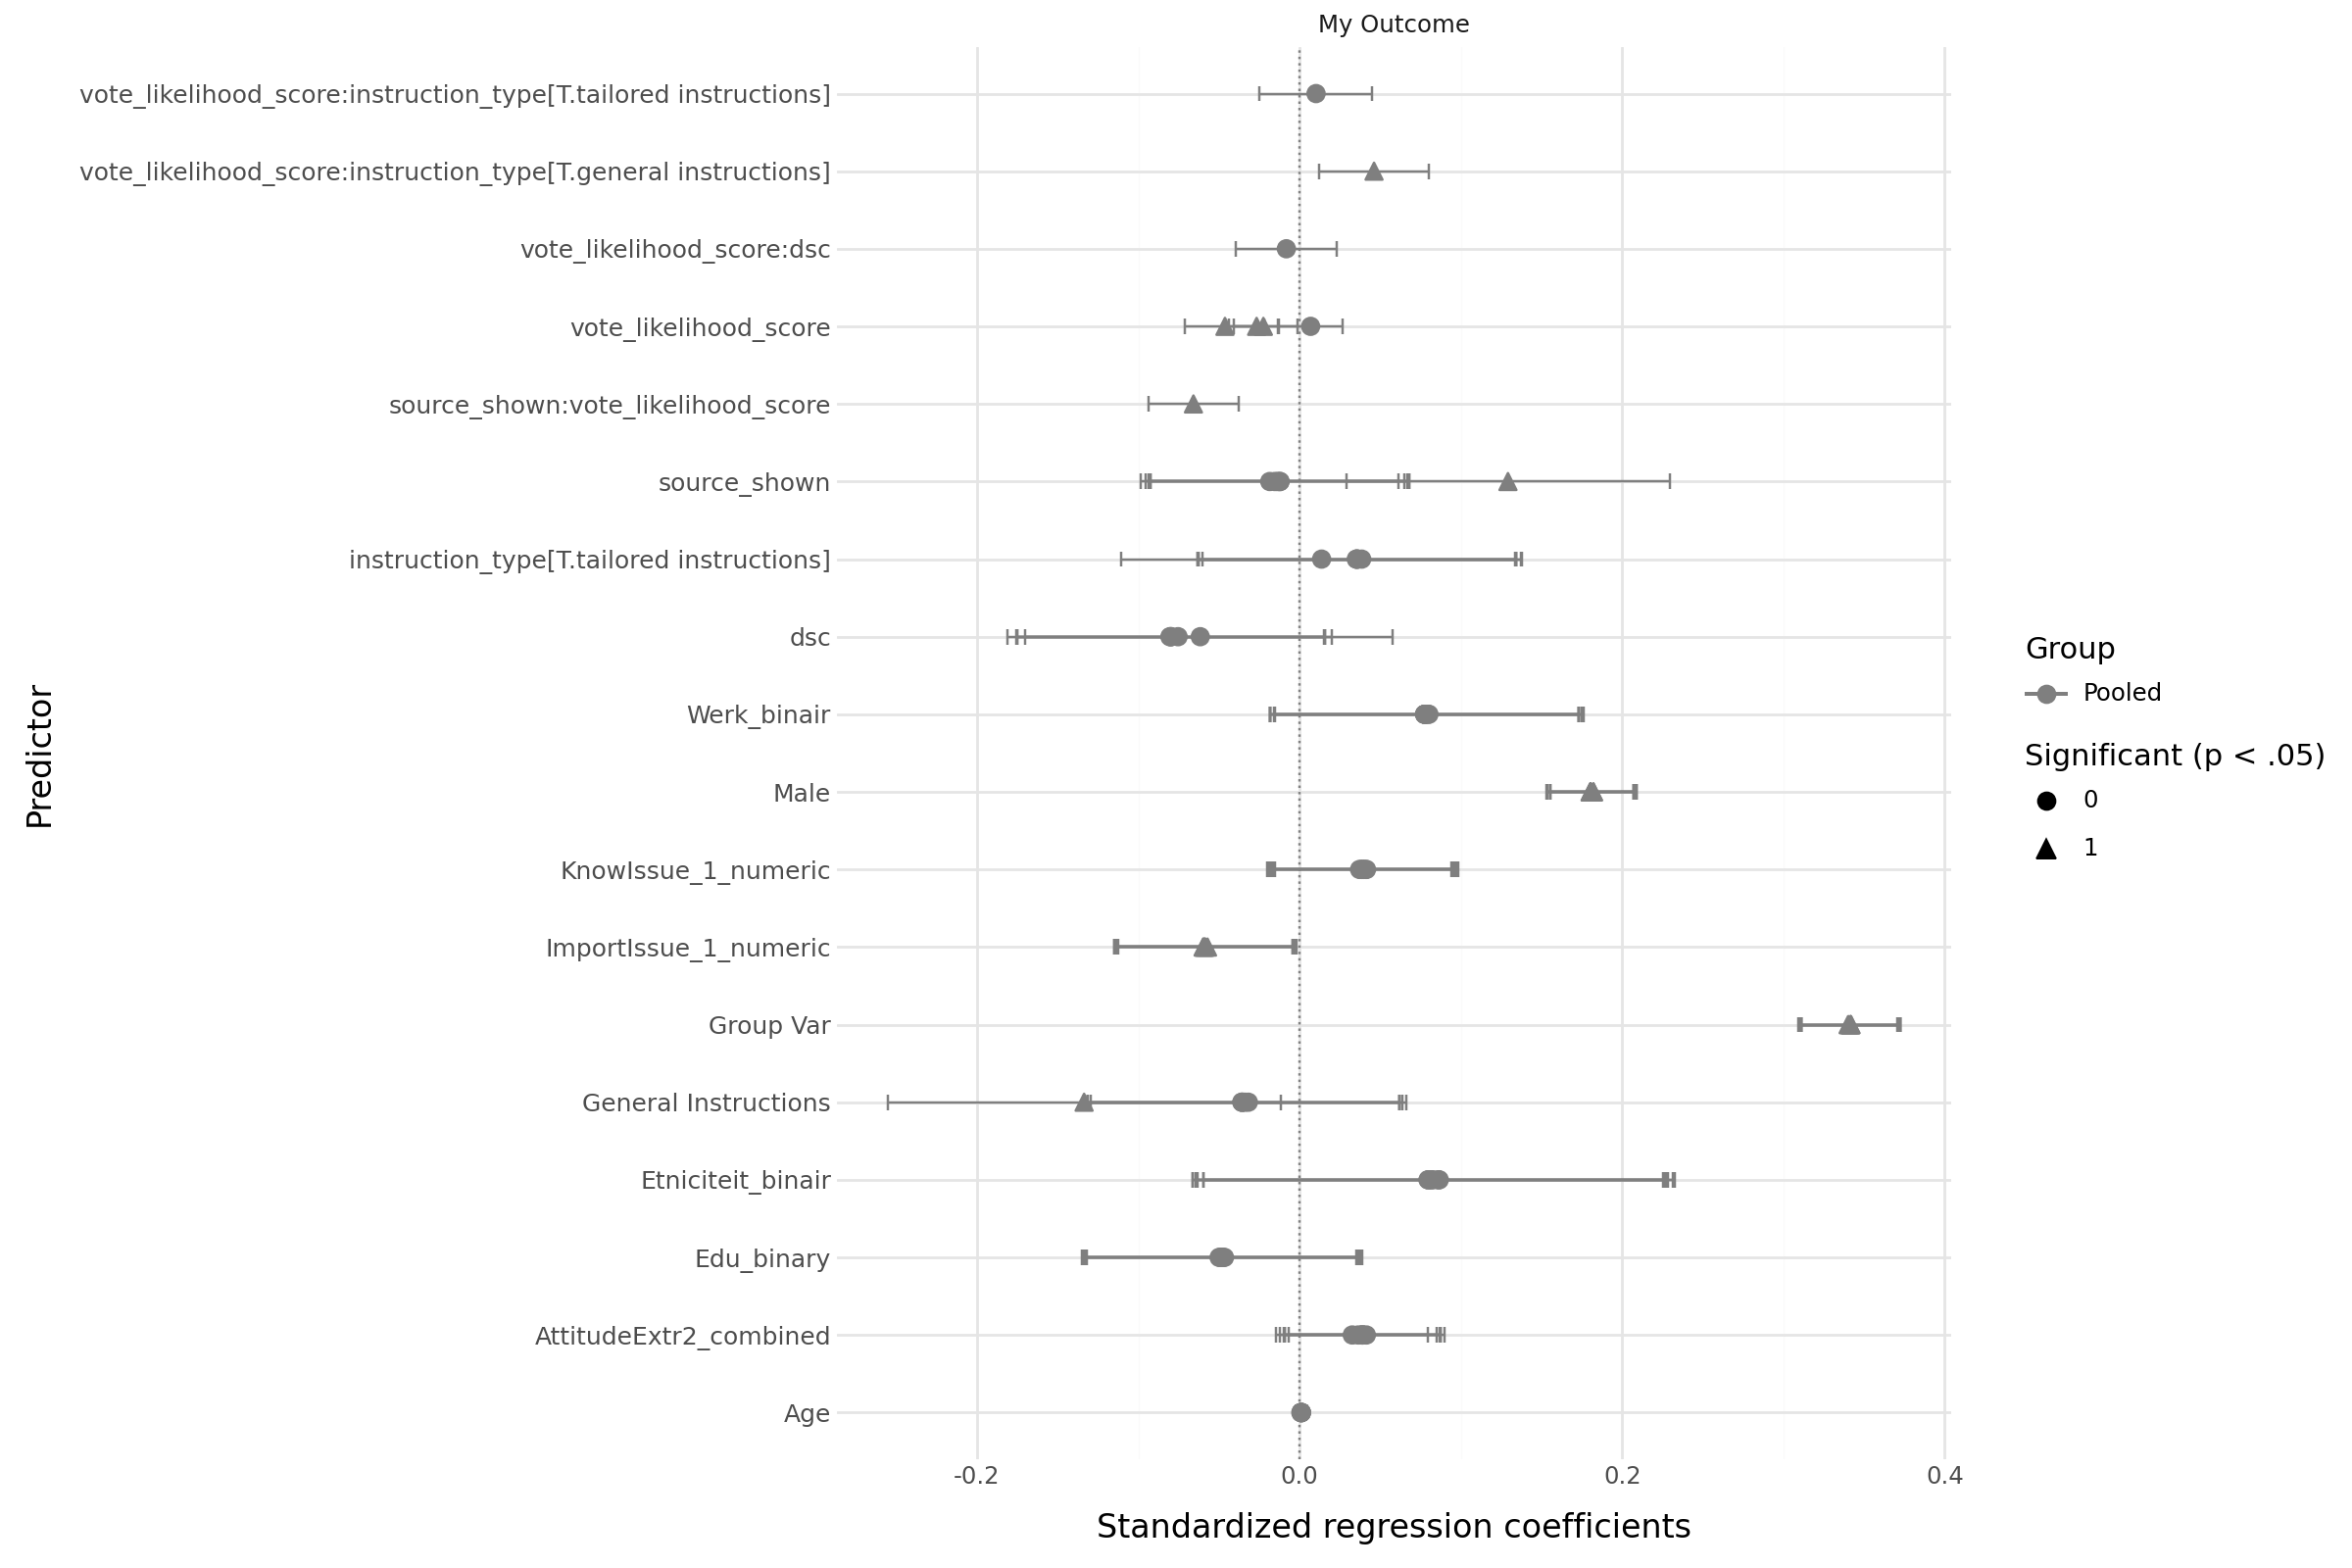

In [298]:
p

<Figure size 800x600 with 0 Axes>

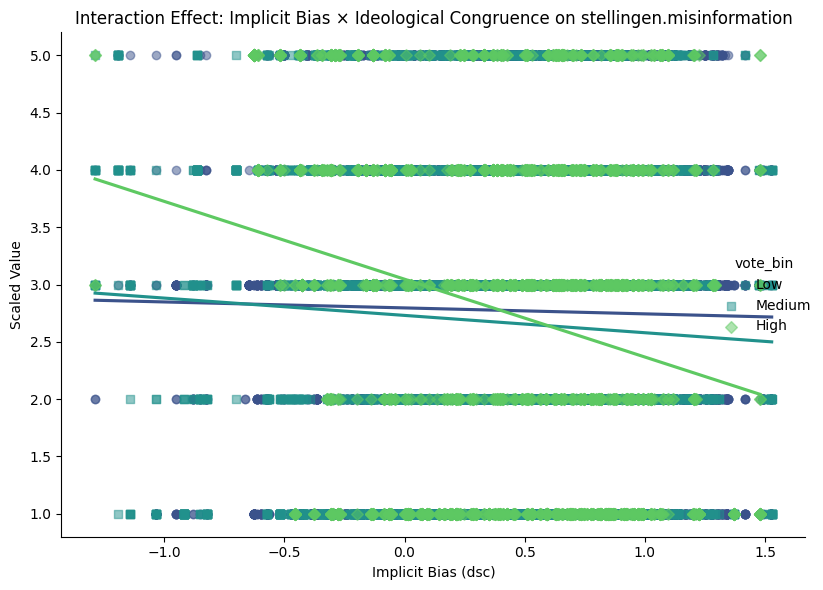

<Figure size 800x600 with 0 Axes>

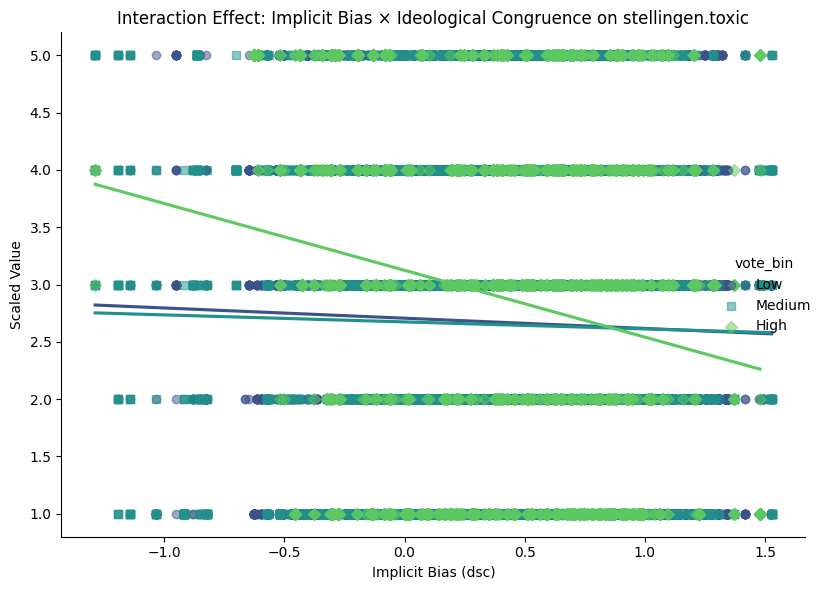

<Figure size 800x600 with 0 Axes>

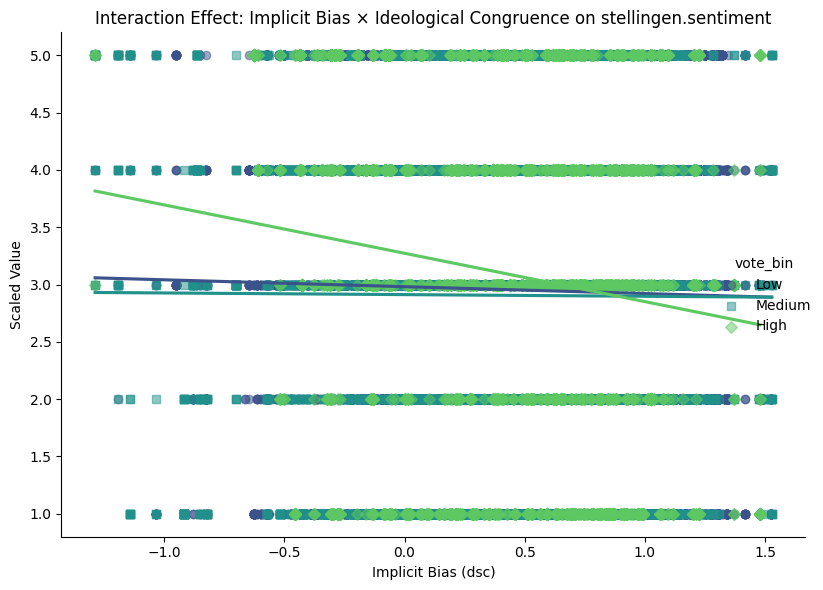

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_interaction(df, variable_name):
    # Filter data for this DV
    df_sub = df[df['variable'] == variable_name].copy()

    # Create bins of vote_likelihood_score for visualization (low, medium, high)
    bins = [-np.inf, 2, 4, np.inf]  # example bin edges
    labels = ['Low', 'Medium', 'High']
    df_sub['vote_bin'] = pd.cut(df_sub['vote_likelihood_score'], bins=bins, labels=labels)

    plt.figure(figsize=(8, 6))

    # Plot regression lines of value_scaled vs dsc, separated by vote_bin
    sns.lmplot(
        x='dsc',
        y='value_scaled',
        hue='vote_bin',
        data=df_sub,
        aspect=1.2,
        height=6,
        ci=None,
        markers=['o', 's', 'D'],
        palette='viridis',
        scatter_kws={'alpha':0.5}
    )

    plt.title(f"Interaction Effect: Implicit Bias × Ideological Congruence on {variable_name}")
    plt.xlabel("Implicit Bias (dsc)")
    plt.ylabel("Scaled Value")
    plt.tight_layout()
    plt.show()

# Example usage for each DV:
for var in ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']:
    plot_interaction(df, var)


In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Select predictors
predictors = [
    'vote_likelihood_score', 'dsc', 'source_shown', 'instruction_type',
    'Male', 'Age', 'ImportIssue_1_numeric', 'KnowIssue_1_numeric',
    'AttitudeExtr2_combined', 'Edu_binary', 'Werk_binair', 'Etniciteit_binair'
]

# 2. Subset and drop missing values
X = df[predictors].dropna()

# 3. Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# 4. Add constant
X = add_constant(X)

# 5. Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce')

# 6. Drop any remaining rows with NaNs (just in case)
X = X.dropna()

# 7. Calculate VIFs
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [36]:
# Subset of variables used in the model
model_vars = ['value_scaled', 'dsc', 'Age', 'Male', 'Edu_binary', 'uid']
df_model = df[model_vars].dropna().copy()

# Check dimensions and that group variable is clean
print("Shape:", df_model.shape)
print("Unique groups (uid):", df_model['uid'].nunique())

# Fit the mixed linear model
model_linear = smf.mixedlm(
    "value_scaled ~ dsc + Age + Male + Edu_binary",
    data=df_model,
    groups=df_model["uid"]
).fit()

print(model_linear.summary())


Shape: (139237, 6)
Unique groups (uid): 1248
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value_scaled
No. Observations: 139237  Method:             REML        
No. Groups:       1248    Scale:              1.3013      
Min. group size:  4       Log-Likelihood:     -218176.4008
Max. group size:  120     Converged:          Yes         
Mean group size:  111.6                                   
-----------------------------------------------------------
            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept    2.848     0.071  39.897  0.000   2.708   2.988
dsc         -0.093     0.045  -2.088  0.037  -0.180  -0.006
Age         -0.000     0.001  -0.266  0.790  -0.003   0.002
Male         0.155     0.007  22.774  0.000   0.141   0.168
Edu_binary  -0.099     0.040  -2.501  0.012  -0.177  -0.021
Group Var    0.454     0.017                               



Correlation Matrix:
              value_scaled       dsc       Age      Male  Edu_binary
value_scaled      1.000000 -0.032918 -0.006200  0.120618   -0.036616
dsc              -0.032918  1.000000  0.246472 -0.004528   -0.101551
Age              -0.006200  0.246472  1.000000  0.013910   -0.129964
Male              0.120618 -0.004528  0.013910  1.000000    0.002888
Edu_binary       -0.036616 -0.101551 -0.129964  0.002888    1.000000


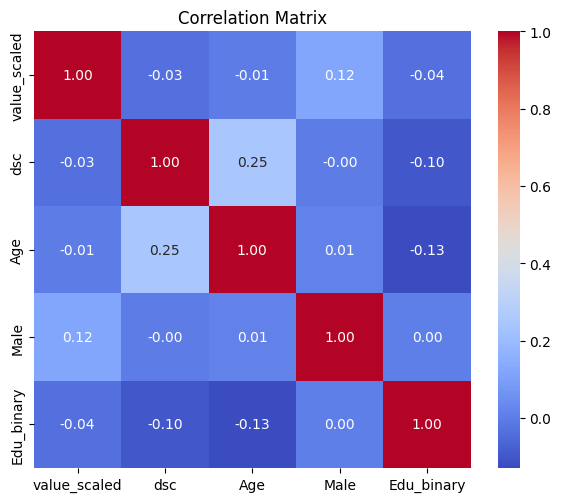

In [37]:
# Only numerical columns for correlation
correlation_vars = ['value_scaled', 'dsc', 'Age', 'Male', 'Edu_binary']
corr_matrix = df[correlation_vars].dropna().corr()

print("Correlation Matrix:")
print(corr_matrix)

# Optional: Visualize it
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [48]:
# Make sure these variables are present and clean
df_model = df[['value_scaled', 'dsc', 'Age', 'Male', 'Edu_binary', 'uid', 'vote_likelihood_score']].dropna().copy()

# Add squared term for nonlinearity
df_model['dsc_sq'] = df_model['dsc'] ** 2

import statsmodels.formula.api as smf

# Linear model
model_linear = smf.mixedlm(
    "value_scaled ~ dsc + Age + Male + Edu_binary",
    data=df_model,
    groups=df_model["uid"]
).fit()

# Nonlinear model (quadratic)
model_nonlinear = smf.mixedlm(
    "value_scaled ~ dsc",
    data=df_model,
    groups=df_model["uid"]
).fit()

# Compare model fit
print("Linear model AIC:", model_linear.aic)
print("Nonlinear model AIC:", model_nonlinear.aic)

print(model_nonlinear.summary())
# Lower AIC indicates better fit


Linear model AIC: nan
Nonlinear model AIC: nan
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value_scaled
No. Observations: 139237  Method:             REML        
No. Groups:       1248    Scale:              1.3058      
Min. group size:  4       Log-Likelihood:     -218426.1967
Max. group size:  120     Converged:          Yes         
Mean group size:  111.6                                   
-----------------------------------------------------------
            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept    2.879     0.030  97.172  0.000   2.821   2.937
dsc         -0.085     0.044  -1.950  0.051  -0.171   0.000
Group Var    0.469     0.017                               



In [46]:
list(df)

['coder_id',
 'coder',
 'jobset',
 'unit_id',
 'unit_status',
 'variable',
 'value',
 'time_question_annotinder',
 'time_answer',
 'field',
 'condition_AT',
 'uid',
 'unit_id_15',
 'Unnamed: 0',
 'Unnamed: 0_x',
 'tweet_id',
 'timestamp',
 'text',
 'full_text',
 'hashtags',
 'urls',
 'source',
 'Author',
 'is_duplicated',
 'twitter_username',
 'Unnamed: 0_y',
 'Name',
 'Party',
 'Start Date',
 'End Date',
 'Wikidata_ID',
 'gender',
 'birthday',
 'twitter_numeric_user_id',
 'subscriber_count',
 'start_date',
 'point_in_time',
 'period',
 'Location',
 'Age_annotinder',
 'Seniority',
 'Image_URL',
 'Political_Party',
 'normalized_party',
 'Ideology',
 'Ideology_Group',
 'immigration',
 'tweet_id_15',
 'StartDate',
 'EndDate',
 'Status',
 'IPAddress',
 'Progress',
 'Duration (in seconds)',
 'Finished',
 'RecordedDate',
 'ResponseId',
 'RecipientLastName',
 'RecipientFirstName',
 'RecipientEmail',
 'ExternalReference',
 'LocationLatitude',
 'LocationLongitude',
 'DistributionChannel',
 'Use

In [50]:
# Add interaction term
df_model['dsc_vote_interaction'] = df_model['dsc'] * df_model['vote_likelihood_score']

# Model with interaction
model_interaction = smf.mixedlm(
    "value_scaled ~ dsc + vote_likelihood_score + dsc_vote_interaction + Age + Male + Edu_binary",
    data=df_model,
    groups=df_model["uid"]
).fit()

print(model_interaction.summary())


             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   value_scaled
No. Observations:   139237    Method:               REML        
No. Groups:         1248      Scale:                1.3005      
Min. group size:    4         Log-Likelihood:       -218149.6034
Max. group size:    120       Converged:            Yes         
Mean group size:    111.6                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              2.953    0.073 40.374 0.000  2.809  3.096
dsc                   -0.144    0.049 -2.973 0.003 -0.239 -0.049
vote_likelihood_score -0.040    0.006 -7.035 0.000 -0.051 -0.029
dsc_vote_interaction   0.019    0.008  2.318 0.020  0.003  0.036
Age                   -0.001    0.001 -0.479 0.632 -0.003  0.002
Male                   0.152    0.007 2

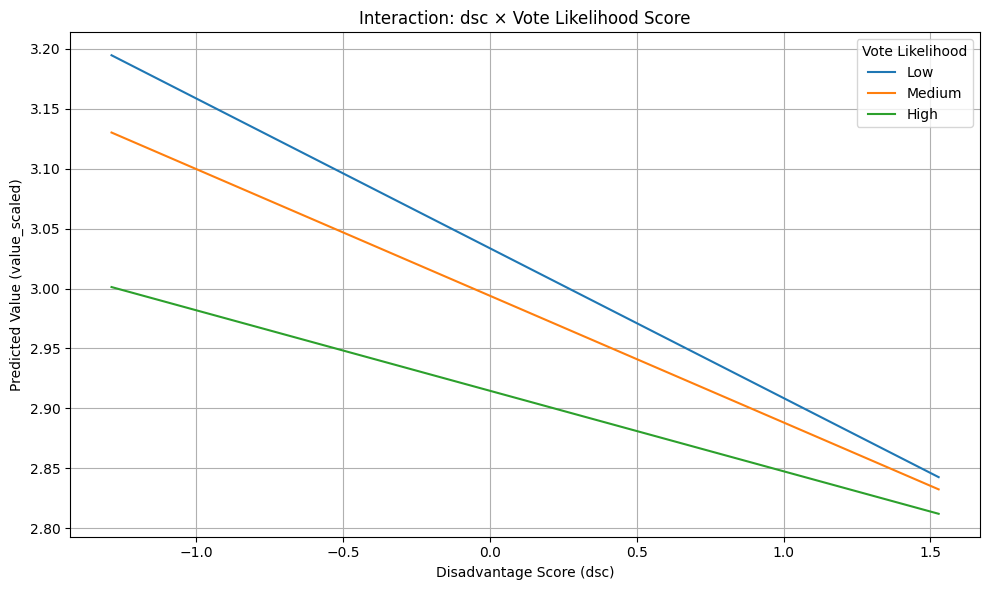

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a grid of values for plotting
dsc_vals = np.linspace(df_model['dsc'].min(), df_model['dsc'].max(), 100)

# Choose low, medium, high values of vote_likelihood_score
vote_levels = {
    'Low': df_model['vote_likelihood_score'].quantile(0.1),
    'Medium': df_model['vote_likelihood_score'].median(),
    'High': df_model['vote_likelihood_score'].quantile(0.9)
}

# Prepare data for prediction
plot_data = pd.DataFrame({
    'dsc': np.tile(dsc_vals, 3),
    'vote_likelihood_score': np.repeat(list(vote_levels.values()), len(dsc_vals))
})

# Compute interaction term
plot_data['dsc_vote_interaction'] = plot_data['dsc'] * plot_data['vote_likelihood_score']

# Add constant values for control variables
plot_data['Age'] = df_model['Age'].mean()
plot_data['Male'] = df_model['Male'].mode()[0]
plot_data['Edu_binary'] = df_model['Edu_binary'].mode()[0]

# Predict using fixed effects (ignore random effects for plotting)
plot_data['predicted'] = model_interaction.predict(plot_data)

# Add label for hue
plot_data['Vote Likelihood'] = np.repeat(list(vote_levels.keys()), len(dsc_vals))

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_data, x='dsc', y='predicted', hue='Vote Likelihood')
plt.xlabel("Disadvantage Score (dsc)")
plt.ylabel("Predicted Value (value_scaled)")
plt.title("Interaction: dsc × Vote Likelihood Score")
plt.grid(True)
plt.tight_layout()
plt.show()


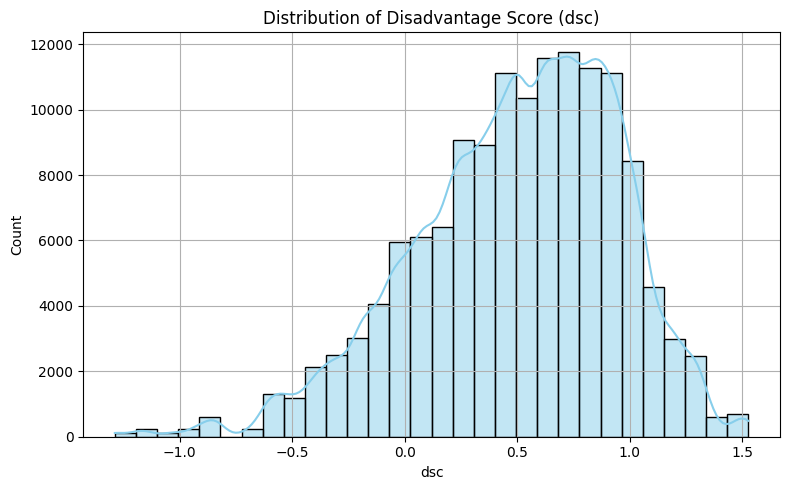

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df_model['dsc'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Disadvantage Score (dsc)")
plt.xlabel("dsc")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import statsmodels.formula.api as smf

# Step 1: Fit Stepwise Mixed-Effects Models
def fit_stepwise_models(data, variable_name):
    """
    Fits stepwise mixed-effects models for a given dependent variable.

    Args:
        data (pd.DataFrame): The dataset containing the variables.
        variable_name (str): The xdependent variable to analyze.

    Returns:
        list: A list of fitted mixed-effects models (MixedLMResults objects).
    """
    # Filter data for the specific variable
    filtered_data = data[data['variable'] == variable_name].copy()

    # Reorder categories for instruction_type to make 'no instructions' the reference
    filtered_data['instruction_type'] = pd.Categorical(
        filtered_data['instruction_type'],
        categories=['no instructions', 'general instructions', 'tailored instructions'],
        ordered=True
    )

    # Define stepwise formulas
    formulas = [
        "value_scaled ~ Male + Age + source_shown + instruction_type + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + dsc + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown * vote_likelihood_score + instruction_type + dsc + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * dsc + instruction_type + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * instruction_type + dsc + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair"
    ]

    # Fit models and store results
    models = []
    for formula in formulas:
        model = smf.mixedlm(
            formula=formula,
            data=filtered_data,
            groups=filtered_data["uid"]  # Grouping variable
        ).fit()
        models.append(model)
    
    return models

# Step 2: Fetch predictor values dynamically
def get_predictor_value(model, predictor):
    """
    Fetches coefficient, standard error, and significance for a predictor in the model.

    Args:
        model (MixedLMResults): The fitted model.
        predictor (str): The predictor name.

    Returns:
        str: Formatted string with coefficient, standard error, and significance,
             or a placeholder if the predictor is not in the model.
    """
    if predictor in model.params.index:
        coef = model.params[predictor]
        se = model.bse[predictor]
        significance = ""
        if model.pvalues[predictor] < 0.001:
            significance = "***"
        elif model.pvalues[predictor] < 0.01:
            significance = "**"
        elif model.pvalues[predictor] < 0.05:
            significance = "*"
        return f"{coef:.2f} ({se:.2f}){significance}"
    else:
        return "--"  # Placeholder for missing predictors

# Step 3: Rename predictors for better readability
def rename_predictors(predictors):
    renamed_predictors = {
        'Intercept': 'Intercept',
        'instruction_type[T.general instructions]': 'General Instructions',
        'instruction_type[T.tailored instructions]': 'Tailored Instructions',
        'Edu_binary': 'Higher Educated',
        'Male': 'Male',
        'Age': 'Age',
        'source_shown': 'Source Shown',
        'vote_likelihood_score': 'Vote Likelihood Score',
        'dsc': 'DSC',
        'ImportIssue_1_numeric': 'Import Issue (Numeric)',
        'KnowIssue_1_numeric': 'Knowledge Issue (Numeric)',
        'AttitudeExtr2_combined': 'Attitude (Combined)',
        'Werk_binair': 'Employment (Binary)',
        'Etniciteit_binair': 'Ethnicity (Binary)',
        'source_shown:vote_likelihood_score': 'Source Shown × Vote Likelihood',
        'vote_likelihood_score:dsc': 'Vote Likelihood × Implicit Bias',
        'vote_likelihood_score:instruction_type[T.general instructions]': 'Vote Likelihood × General Instructions',
        'vote_likelihood_score:instruction_type[T.tailored instructions]': 'Vote Likelihood × Tailored Instructions',
        'Group Var': 'Group Variance'
    }
    return renamed_predictors


# Step 4: Generate LaTeX table
def generate_latex_table_with_group_variance(models, predictors, rename_map, variable_name):
    control_vars = [
        'Male', 'Age', 'ImportIssue_1_numeric', 'KnowIssue_1_numeric',
        'AttitudeExtr2_combined', 'Edu_binary', 'Werk_binair', 'Etniciteit_binair', 'Group Var'
    ]
    predictors_ordered = [p for p in predictors if p not in control_vars] + control_vars

    # Generate table rows dynamically
    table_rows = []

    for predictor in predictors_ordered:
        if predictor == "Group Var":  # Skip Group Var in predictors
            continue
        renamed_predictor = rename_map.get(predictor, predictor)
        # Italicize control variable names
        if predictor in control_vars:
            renamed_predictor = f"\\textit{{{renamed_predictor}}}"
        row = [renamed_predictor]  # Use renamed predictor
        for model in models:
            value = get_predictor_value(model, predictor)
            # Italicize coefficients of control variables
            if predictor in control_vars:
                value = f"\\textit{{{value}}}" if value != "--" else value
            row.append(value)
        table_rows.append(row)
    
    # Add a horizontal line before model information
    table_rows.append(["\\hline"])
    
    # Add model information rows
    model_info_rows = []
    
    # Group Variance
    group_variance_row = ["Group Variance"]
    for model in models:
        group_var = model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
        group_variance_row.append(f"{group_var:.4f}")
    model_info_rows.append(group_variance_row)
    
    # ICC
    icc_row = ["ICC"]
    for model in models:
        group_var = model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
        residual_var = model.scale
        icc = group_var / (group_var + residual_var) if group_var + residual_var > 0 else float('nan')
        icc_row.append(f"{icc:.4f}")
    model_info_rows.append(icc_row)
    
    # Log Likelihood
    log_likelihood_row = ["Log Likelihood"]
    for model in models:
        log_likelihood_row.append(f"{model.llf:.4f}")
    model_info_rows.append(log_likelihood_row)
    
    # N (Obs) and N (Groups)
    n_obs_row = ["N (Obs)"]
    n_groups_row = ["N (Groups)"]
    for model in models:
        n_obs_row.append(f"{int(model.nobs)}")
        n_groups = len(model.random_effects) if hasattr(model, "random_effects") else float('nan')
        n_groups_row.append(f"{n_groups}")
    model_info_rows.append(n_obs_row)
    model_info_rows.append(n_groups_row)
    
    # Append model information rows to the table
    table_rows.extend(model_info_rows)
    
    # Generate LaTeX table
    latex_table = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{Stepwise Mixed-Effects Model Results for {variable_name}}}\n"
        f"\\label{{tab:{variable_name}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        "\\begin{tabular}{" + "l" + "c" * len(models) + "}\n"
        "\\hline\n"
        + " & ".join(["Predictor"] + [f"Model {i+1}" for i in range(len(models))]) + " \\\\\n"
        "\\hline\n"
        + "\n".join(" & ".join(row) + " \\\\" for row in table_rows)  # Ensure rows end with '\\'
        + "\\hline\n"
        "\\end{tabular}\n"
        "}\n"
        "\\end{table}"
    )
    
    return latex_table


# Step 5: Main Script
# Example variables to analyze
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
fitted_models = {}

# Rename map for predictors
rename_map = rename_predictors(predictors=[
    'Intercept',
    'instruction_type[T.general instructions]',
    'instruction_type[T.tailored instructions]',
    'Edu_binary',
    'Male',
    'Age',
    'source_shown',
    'vote_likelihood_score',
    'dsc',
    'ImportIssue_1_numeric',
    'KnowIssue_1_numeric',
    'AttitudeExtr2_combined',
    'Werk_binair',
    'Etniciteit_binair',
    'Group Var'
])

# Fit models and generate LaTeX tables for each variable
for var in variables:
    try:
        print(f"Fitting models for variable: {var}")
        fitted_models[var] = fit_stepwise_models(df, var)

        print(f"Generating LaTeX table for variable: {var}")
        latex_table = generate_latex_table_with_group_variance(fitted_models[var], list(rename_map.keys()), rename_map, var)
        print(latex_table)
    except Exception as e:
        print(f"Error processing variable {var}: {e}")

Fitting models for variable: stellingen.misinformation
Generating LaTeX table for variable: stellingen.misinformation
\begin{table}[ht]
\centering
\caption{Stepwise Mixed-Effects Model Results for stellingen.misinformation}
\label{tab:stellingen.misinformation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\hline
Predictor & Model 1 & Model 2 & Model 3 & Model 4 & Model 5 & Model 6 \\
\hline
Intercept & 2.61 (0.15)*** & 2.82 (0.15)*** & 2.81 (0.15)*** & 2.69 (0.15)*** & 2.79 (0.15)*** & 2.87 (0.15)*** \\
General Instructions & 0.03 (0.05) & 0.02 (0.05) & 0.02 (0.05) & 0.03 (0.05) & 0.02 (0.05) & -0.10 (0.06) \\
Tailored Instructions & 0.06 (0.05) & 0.06 (0.05) & 0.06 (0.05) & 0.07 (0.05) & 0.06 (0.05) & 0.02 (0.06) \\
Source Shown & 0.01 (0.04) & 0.01 (0.04) & 0.02 (0.04) & 0.22 (0.05)*** & 0.02 (0.04) & 0.02 (0.04) \\
Vote Likelihood Score & -- & -0.07 (0.01)*** & -0.07 (0.01)*** & -0.02 (0.01)* & -0.06 (0.01)*** & -0.10 (0.01)*** \\
DSC & -- & -- & -0.14 (0.05)** & -0.14 (0.05

In [3]:
def generate_latex_table_with_group_variance(models, predictors, rename_map, variable_name):
    """
    Generates a LaTeX table showing mixed-effects model results, organized by hypotheses.
    """
    # Update renamed predictors to use more intuitive names
    rename_map.update({
        'vote_likelihood_score': 'Ideological Congruence',
        'dsc': 'Implicit Bias',
        'vote_likelihood_score:dsc': 'Ideological Congruence × Implicit Bias',
        'source_shown:vote_likelihood_score': 'Source Shown × Ideological Congruence',
        'vote_likelihood_score:instruction_type[T.general instructions]': 'Ideological Congruence × General Instructions',
        'vote_likelihood_score:instruction_type[T.tailored instructions]': 'Ideological Congruence × Tailored Instructions'
    })

    # Define variable groups per hypothesis
    sections = {
        'H1: Effects of Ideological Congruence': [
            'vote_likelihood_score', 'instruction_type[T.general instructions]', 'instruction_type[T.tailored instructions]'
        ],
        'H2: Moderating Effects of Implicit Bias': ['vote_likelihood_score:dsc'],
        'H3: Moderating Effects of Source Visibility': ['source_shown:vote_likelihood_score'],
        'H4: Moderating Effects of Instruction Type': [
            'vote_likelihood_score:instruction_type[T.general instructions]',
            'vote_likelihood_score:instruction_type[T.tailored instructions]'
        ],
        'Control Variables': [
            'Male', 'Age', 'ImportIssue_1_numeric', 'KnowIssue_1_numeric',
            'AttitudeExtr2_combined', 'Edu_binary', 'Werk_binair', 'Etniciteit_binair'
        ]
    }

    table_rows = []

    # Build rows per hypothesis section
    for section_title, section_predictors in sections.items():
        table_rows.append([f"\\multicolumn{{{len(models)+1}}}{{l}}{{\\textbf{{{section_title}}}}} \\\\"])
        for predictor in section_predictors:
            display_name = rename_map.get(predictor, predictor)
            is_control = section_title == "Control Variables"
            if is_control:
                display_name = f"\\textit{{{display_name}}}"
            row = [display_name]
            for model in models:
                val = get_predictor_value(model, predictor)
                if is_control and val != "--":
                    val = f"\\textit{{{val}}}"
                row.append(val)
            table_rows.append(row)

    # Horizontal line before model stats
    table_rows.append(["\\hline"])

    # Model-level statistics
    model_info = []

    # Group variance
    group_var_row = ["Group Variance"]
    for model in models:
        var = model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
        group_var_row.append(f"{var:.4f}")
    model_info.append(group_var_row)

    # ICC
    icc_row = ["ICC"]
    for model in models:
        group_var = model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
        residual = model.scale
        icc = group_var / (group_var + residual) if group_var + residual > 0 else float('nan')
        icc_row.append(f"{icc:.4f}")
    model_info.append(icc_row)

    # Log likelihood
    log_lik_row = ["Log Likelihood"]
    for model in models:
        log_lik_row.append(f"{model.llf:.4f}")
    model_info.append(log_lik_row)

    # N (obs) and N (groups)
    n_obs_row = ["N (Obs)"]
    n_groups_row = ["N (Groups)"]
    for model in models:
        n_obs_row.append(f"{int(model.nobs)}")
        n_groups = len(model.random_effects) if hasattr(model, "random_effects") else float('nan')
        n_groups_row.append(f"{n_groups}")
    model_info.append(n_obs_row)
    model_info.append(n_groups_row)

    table_rows.extend(model_info)

    # Build LaTeX
    latex_table = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{Stepwise Mixed-Effects Model Results for {variable_name}}}\n"
        f"\\label{{tab:{variable_name}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        f"\\begin{{tabular}}{{{'l' + 'c'*len(models)}}}\n"
        "\\hline\n"
        + " & ".join(["Predictor"] + [f"Model {i+1}" for i in range(len(models))]) + " \\\\\n"
        "\\hline\n"
        + "\n".join(" & ".join(row) + " \\\\" for row in table_rows) +
        "\n\\hline\n"
        "\\end{tabular}\n"
        "}\n"
        # Optional: Uncomment below for hypothesis footnotes
        # "\\begin{tablenotes}\n"
        # "\\small\n"
        # "\\item \\textbf{H1:} Congruence is negatively related to annotation outcomes.\n"
        # "\\item \\textbf{H2:} This effect becomes stronger as implicit bias increases.\n"
        # "\\item \\textbf{H3:} The effect strengthens when the source is shown.\n"
        # "\\item \\textbf{H4:} Tailored instructions dampen this effect most; no instructions the least.\n"
        # "\\end{tablenotes}\n"
        "\\end{table}"
    )

    return latex_table


In [16]:
import pandas as pd
import statsmodels.formula.api as smf

# Step 1: Fit Stepwise Mixed-Effects Models
def fit_stepwise_models(data, variable_name):
    filtered_data = data[data['variable'] == variable_name].copy()
    
    # Ensure 'instruction_type' is a categorical with ordered levels
    filtered_data['instruction_type'] = pd.Categorical(
        filtered_data['instruction_type'],
        categories=['no instructions', 'general instructions', 'tailored instructions'],
        ordered=True
    )
    
    formulas = [
        "value_scaled ~ Male + Age + source_shown + instruction_type + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + dsc + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown * vote_likelihood_score + instruction_type + dsc + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * dsc + instruction_type + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * instruction_type + dsc + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair"
    ]
    
    models = []
    for formula in formulas:
        model = smf.mixedlm(formula, data=filtered_data, groups=filtered_data["uid"]).fit()
        models.append(model)
    
    return models

# Step 2: Predictor Renaming
def rename_predictors(predictors):
    return {
        'Intercept': 'Intercept',
        'instruction_type[T.general instructions]': 'General Instructions',
        'instruction_type[T.tailored instructions]': 'Tailored Instructions',
        'Edu_binary': 'Higher Educated',
        'Male': 'Male',
        'Age': 'Age',
        'source_shown': 'Source Shown',
        'vote_likelihood_score': 'Ideological Congruence',
        'dsc': 'Implicit Bias',
        'ImportIssue_1_numeric': 'Import Issue (Numeric)',
        'KnowIssue_1_numeric': 'Knowledge Issue (Numeric)',
        'AttitudeExtr2_combined': 'Attitude (Combined)',
        'Werk_binair': 'Employment (Binary)',
        'Etniciteit_binair': 'Ethnicity (Binary)',
        'source_shown:vote_likelihood_score': 'Source Shown × Ideological Congruence',
        'vote_likelihood_score:dsc': 'Ideological Congruence × Implicit Bias',
        'vote_likelihood_score:instruction_type[T.general instructions]': 'Ideological Congruence × General Instructions',
        'vote_likelihood_score:instruction_type[T.tailored instructions]': 'Ideological Congruence × Tailored Instructions',
        'Group Var': 'Group Variance'
    }

# Step 3: LaTeX Table Generator
def generate_latex_table_with_group_variance(models, predictors, rename_map, variable_name):
    sections = {
        'Main Effects': [
            'instruction_type[T.general instructions]',
            'instruction_type[T.tailored instructions]',
            'source_shown',
            'dsc'
        ],
        'H1: Effects of Ideological Congruence': ['vote_likelihood_score'],
        'H2: Moderating Effects of Implicit Bias': ['vote_likelihood_score:dsc'],
        'H3: Moderating Effects of Source Visibility': ['source_shown:vote_likelihood_score'],
        'H4: Moderating Effects of Instruction Type': [
            'vote_likelihood_score:instruction_type[T.general instructions]',
            'vote_likelihood_score:instruction_type[T.tailored instructions]'
        ],
        'Control Variables': [
            'Male', 'Age', 'ImportIssue_1_numeric', 'KnowIssue_1_numeric',
            'AttitudeExtr2_combined', 'Edu_binary', 'Werk_binair', 'Etniciteit_binair'
        ]
    }

    def format_coef(model, predictor, italic=False):
        try:
            coef = model.params[predictor]
            se = model.bse[predictor]
            p = model.pvalues[predictor]
            val = f"{coef:.2f} ({se:.2f})"
            if p < 0.05:
                val = f"\\textbf{{{val}}}"
            if italic:
                val = f"\\textit{{{val}}}"
            return val
        except:
            return "--"

    table_rows = []

    for section_title, section_predictors in sections.items():
        table_rows.append(["\\hline"])
        table_rows.append([f"\\multicolumn{{{len(models)+1}}}{{l}}{{\\textbf{{{section_title}}}}} \\\\"])
        for predictor in section_predictors:
            name = rename_map.get(predictor, predictor)
            italic = (section_title == "Control Variables")
            if italic:
                name = f"\\textit{{{name}}}"
            row = [name] + [format_coef(m, predictor, italic=italic) for m in models]
            table_rows.append(row)

    # Model fit stats
    def get_group_var(model):
        return model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')

    def get_icc(model):
        gv = get_group_var(model)
        rv = model.scale
        return gv / (gv + rv) if gv + rv > 0 else float('nan')

    table_rows.append(["\\hline"])
    table_rows.extend([
        ["Group Variance"] + [f"{get_group_var(m):.4f}" for m in models],
        ["ICC"] + [f"{get_icc(m):.4f}" for m in models],
        ["Log Likelihood"] + [f"{m.llf:.2f}" for m in models],
        ["N (Obs)"] + [f"{int(m.nobs)}" for m in models],
        ["N (Groups)"] + [f"{len(m.random_effects)}" if hasattr(m, "random_effects") else "NA" for m in models]
    ])

    # LaTeX Output
    escaped_varname = variable_name.replace('_', '\\_')
    latex_table = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{Stepwise Mixed-Effects Model Results for {escaped_varname}}}\n"
        f"\\label{{tab:{variable_name}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        f"\\begin{{tabular}}{{{'l' + 'c'*len(models)}}}\n"
        "\\hline\n"
        + " & ".join(["Predictor"] + [f"Model {i+1}" for i in range(len(models))]) + " \\\\\n"
        "\\hline\n"
        + "\n".join(" & ".join(row) + " \\\\" for row in table_rows) +
        "\n\\hline\n"
        "\\end{tabular}%\n"
        "}\n"
        "\\end{table}"
    )
    return latex_table

# Step 4: Main Execution
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
fitted_models = {}

rename_map = rename_predictors([])  # Safe call, you don't need to pass keys here

for var in variables:
    try:
        print(f"\nFitting models for variable: {var}")
        fitted_models[var] = fit_stepwise_models(df, var)

        print(f"Generating LaTeX table for variable: {var}")
        latex_table = generate_latex_table_with_group_variance(
            fitted_models[var],
            list(rename_map.keys()),
            rename_map,
            var
        )
        print(latex_table)
    except Exception as e:
        print(f"❌ Error processing variable {var}: {e}")



Fitting models for variable: stellingen.misinformation
Generating LaTeX table for variable: stellingen.misinformation
\begin{table}[ht]
\centering
\caption{Stepwise Mixed-Effects Model Results for stellingen.misinformation}
\label{tab:stellingen.misinformation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\hline
Predictor & Model 1 & Model 2 & Model 3 & Model 4 & Model 5 & Model 6 \\
\hline
\hline \\
\multicolumn{7}{l}{\textbf{Main Effects}} \\ \\
General Instructions & 0.03 (0.05) & 0.02 (0.05) & 0.02 (0.05) & 0.03 (0.05) & 0.02 (0.05) & -0.10 (0.06) \\
Tailored Instructions & 0.06 (0.05) & 0.06 (0.05) & 0.06 (0.05) & 0.07 (0.05) & 0.06 (0.05) & 0.02 (0.06) \\
Source Shown & 0.01 (0.04) & 0.01 (0.04) & 0.02 (0.04) & \textbf{0.22 (0.05)} & 0.02 (0.04) & 0.02 (0.04) \\
Implicit Bias & -- & -- & \textbf{-0.14 (0.05)} & \textbf{-0.14 (0.05)} & -0.10 (0.06) & \textbf{-0.14 (0.05)} \\
\hline \\
\multicolumn{7}{l}{\textbf{H1: Effects of Ideological Congruence}} \\ \\
Ideological Con